0001189587, Leonardo Billi, leonardo.billi@studio.unibo.it  <br>
0001189550, Lorenzo Pellegrino, lorenzo.pellegrino2@studio.unibo.it <br>
0001169261, Giorgio Scavello, giorgio.scavello@studio.unibo.it  

# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [ ]:
# Package requirements
! pip install --upgrade pip
! pip install tqdm pandas nltk gensim numpy tensorflow matplotlib scikit-learn
! pip install torch torchvision torchaudio
! pip install transformers datasets bitsandbytes accelerate 
! pip install gdown

In [ ]:
# Standard library
import os
import re
import json
import gc
import random
from collections import Counter, defaultdict

# Typing
from typing import List, Dict, Tuple, Set

# Third-party libraries
import pickle
import numpy as np
import pandas as pd
import gensim
import gensim.downloader as gloader
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from datasets import Dataset
from transformers import (
   AutoTokenizer,
   AutoModelForSequenceClassification,
   DataCollatorWithPadding,
   TrainingArguments,
   Trainer,
   set_seed,
   EarlyStoppingCallback
)

from transformers import logging as hf_logging
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import pad_sequences, to_categorical
from collections import Counter
import gdown
import seaborn as sns

DEBUG = True
if DEBUG:
    import torch
    print(torch.__version__)
    print(torch.version.cuda)

2.9.1
None


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [ ]:
! rm -rf nlp-course-material
! git clone https://github.com/nlp-unibo/nlp-course-material.git

## Weights
Download the weights for the Bidirectional LSMTs, if you do not want to use the loaded weights, tokenizer and results, it is necessary to set `load_LSTM=False` in the following cell. 


In [ ]:
file_id='16xJsbsDzk7IzMwbzgTOPzU-e7W_mIJ9j'
gdown.download(id=file_id, output="weights.zip", fuzzy=True)

load_LSTM=True

! unzip weights.zip
! hf auth login

In [ ]:
# Load and encode the jsons
data_path = "./nlp-course-material/2025-2026/Assignment 1/data/"
train_df = pd.read_json(data_path + 'training.json').T
test_df = pd.read_json(data_path + 'test.json').T
val_df = pd.read_json(data_path + 'validation.json').T
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # useful for task 6
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist

train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

## Utils

In [ ]:
# Download required NLTK data
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str, no_lemma: bool=False) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # uses recommended NLTK tokenizer
    if no_lemma: 
        return " ".join(tokens)
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

def clean_lemm_text(text, patterns, no_lemma: bool=False):
    
    # Remove other patterns
    # NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text, no_lemma=no_lemma)
    
def extract_corpus(df: pd.DataFrame) -> Tuple[List[List[str]], Set[str]]:
    # NOTE: we use split as they were already tokenized and jointed with spaces
    corpus = df["cleaned_lemm_tweet"].apply(lambda x: x.split()).tolist()
    unique_words = {word for sentence in corpus for word in sentence}
    return corpus, unique_words


[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Calculations

In [ ]:
# NOTE: we changed the order of patterns with respect to instructions so that some could be simplified
patterns = [
    
    # Hashtags
    re.compile(r'#\w+'),
    
    # Mentions
    re.compile(r'@\w+'),
    
    # URLs
    re.compile(r'https?://[^\s]+'), 
    
    # Emojis, special characters and symbols, specific quotes characters
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters so we merged them.
    re.compile(r'[^\s\w]')
    
]

for i, df in enumerate(dfs):
    df['cleaned_lemm_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns)
    )
    
    # Useful for task 6
    df['cleaned_only_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns, no_lemma=True)
    )
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_lemm_tweet", "cleaned_only_tweet"]])

,tweet,cleaned_lemm_tweet,cleaned_only_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...,FFS How about laying the blame on the bastard ...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...,Writing a uni essay in my local pub with a cof...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...,it is 2021 not 1921 I dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...,this is unacceptable Use her title as you did ...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...,Making yourself a harder target basically boil...
...,...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...,Ma am if I say that you look like a whore Woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...,idk why y all bitches think having half your a...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...,This has been a part of an experiment with Wha...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...,Take me already Not yet You got ta be ready I ...


In [ ]:
# Extract corpora
train_corpus, train_words = extract_corpus(train_df)
val_corpus, val_words = extract_corpus(val_df)
test_corpus, test_words = extract_corpus(test_df)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

## Parameters used here
Some may change during error analysis, however they are fixed for this task.

In [ ]:
# Hyperparams
USE_FULL_PRELOAD_EMB_MODEL = False
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"
SEED=42

## Utils
These are the functions which will be used in this task. The `build_tokenizer` function is able to load a tokenizer from a pickle in order to match the tokenizer with the one on which the model is trained on.

In [ ]:
def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e
        
def build_tokenizer(
    train_words: Set[str] = None,
    embedding_model: gensim.models.keyedvectors.KeyedVectors = None,
    use_full_embed_model: bool = True,
    oov_token: str = "<OOV>",
    verbose: bool = False,
    load=False,
    path='./'
) -> Tokenizer:
    """
    Build a Keras tokenizer from a corpus of tokenized sentences.
    
    :param train_words: set of words in training corpus (used when use_full_embed_model=False)
    :param embedding_model: pre-trained embedding model (used when use_full_embed_model=True)
    :param use_full_embed_model: if True, use all words from corpus + embedding_model; if False, only train_words
    :param oov_token: token for out-of-vocabulary words
    :param verbose: print statistics
    :return: fitted Tokenizer
    """
    
    assert isinstance(train_words, set), "train_words must be a set of strings"
    
    # Determine which words to keep
    embedding_words = set(embedding_model.index_to_key)
    if use_full_embed_model:
        # Use all words from embedding model and training corpus
        vocab_to_use = train_words | embedding_words  # Union
    else:
        # Only use training words
        vocab_to_use = train_words
    
    # Build tokenizer
    # NOTE: we load the glove tokens as they are (with punctuation, case-sensitive)
    
    if load is True:
        with open(f"{path}/tokenizer.pkl", "rb") as f:
            tokenizer = pickle.load(f)
            print('tokenizer loaded')   
    else:
        tokenizer = Tokenizer(
        oov_token=oov_token,
        filters='',           
        lower=False,          
        split=' '        
    )
        tokenizer.fit_on_texts(list(vocab_to_use))
        with open(f"{path}/tokenizer.pkl", "wb") as f:
            pickle.dump(tokenizer, f)
            print('tokenizer dumped')
    
    if verbose and not use_full_embed_model:
        print(f"Tokenizer doesn't contain {len(embedding_words - train_words)} words from the embedding model (they were not in the train set).")

    
    return tokenizer

def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    seed: int = 42,
    verbose: bool = True,
    totally_random=False
) -> tuple[np.ndarray, list]:
    """
    Build embedding matrix from tokenizer vocabulary and embedding model.
    
    Index 0: padding (zeros)
    Other indices: 
        - If word in embedding_model: use pre-trained embedding
        - Otherwise: random embedding based on distribution of train_words in model
    
    :param tokenizer: fitted Keras tokenizer
    :param embedding_model: pre-loaded embedding model (unchanged)
    :param train_words: set of words in training corpus (for computing random embedding distribution)
    :param seed: random seed for reproducibility
    :param verbose: whether to print detailed statistics
    :return: tuple of (embedding_matrix, random_idxs)
             embedding_matrix: shape (vocab_size, embedding_dim)
             random_idxs: list of indices that got random embeddings
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = embedding_model.vector_size
    
    # Initialize with zeros
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Pre-compute parameters for random embeddings
    # ALWAYS use distribution from the tokenizer (only train or train|model)
    filtered_vectors = np.array([
        embedding_model[word] for word in tokenizer.word_index.keys() 
        if word in embedding_model
    ])
    mean = filtered_vectors.mean(axis=0)
    std = filtered_vectors.std(axis=0)

    # Statistics tracking
    from_model_count = 0
    random_idxs = []  # indices that received random embeddings
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Fill embedding matrix with progress bar
    for word, idx in tqdm(tokenizer.word_index.items(), 
                          desc="Building embedding matrix",
                          disable=not verbose):
        if word in embedding_model and not totally_random:
            # Use pre-trained embedding
            embedding_matrix[idx] = embedding_model[word]
            from_model_count += 1
        else:
            # OOV word: use random embedding
            embedding_matrix[idx] = np.random.normal(mean, std)
            random_idxs.append(idx)
    
    if verbose:
        total_words = vocab_size - 1  # excluding padding
        coverage = from_model_count / total_words * 100 if total_words > 0 else 0
        
        print(f"Embedding Matrix Statistics:")
        print(f"\tShape: {embedding_matrix.shape}")
        print(f"\tWords from embedding model: {from_model_count}/{total_words} ({coverage:.2f}%)")
        print(f"\tRandom embeddings (OOV): {len(random_idxs)}")
    
    return embedding_matrix, random_idxs

def compute_oov_stats(tokenizer, word_set, set_name):
    """
    Compute out-of-vocabulary statistics for a given word set.
    
    :param tokenizer: fitted Keras tokenizer
    :param word_set: set of words to check
    :param set_name: name of the dataset (for display)
    """
    tokenizer_vocab = set(tokenizer.word_index.keys())
    
    oov_words = word_set - tokenizer_vocab
    in_vocab_words = word_set & tokenizer_vocab
    
    total = len(word_set)
    oov_count = len(oov_words)
    in_vocab_count = len(in_vocab_words)
    oov_rate = (oov_count / total * 100) if total > 0 else 0
    
    print(f"{set_name} OOV Statistics:")
    print(f"\tTotal unique words: {total}")
    print(f"\tIn vocabulary: {in_vocab_count} ({100 - oov_rate:.2f}%)")
    print(f"\tOOV words: {oov_count} ({oov_rate:.2f}%)")
    print()
    

## Calculations

In [ ]:
load_tok=load_LSTM

# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)
print(f"Embedding model length: {len(embedding_model.index_to_key)}\n")

# Build tokenizer
tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=USE_FULL_PRELOAD_EMB_MODEL,
    oov_token=OOV_TOKEN,
    verbose=True,
    load=load_tok,
    path='./weights/base'
)
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

Embedding model length: 400000

tokenizer dumped
Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 576561.55it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 8182/9145 (89.47%)
	Random embeddings (OOV): 963


## Extra: statistics of OOV in val and test sets

In [ ]:
# Compute OOV stats
compute_oov_stats(tokenizer, train_words, "Training Set")
compute_oov_stats(tokenizer, val_words, "Validation Set")
compute_oov_stats(tokenizer, test_words, "Test Set")

Training Set OOV Statistics:
	Total unique words: 9144
	In vocabulary: 9144 (100.00%)
	OOV words: 0 (0.00%)

Validation Set OOV Statistics:
	Total unique words: 1456
	In vocabulary: 1143 (78.50%)
	OOV words: 313 (21.50%)

Test Set OOV Statistics:
	Total unique words: 2124
	In vocabulary: 1593 (75.00%)
	OOV words: 531 (25.00%)



## Extra: visualization of embedding

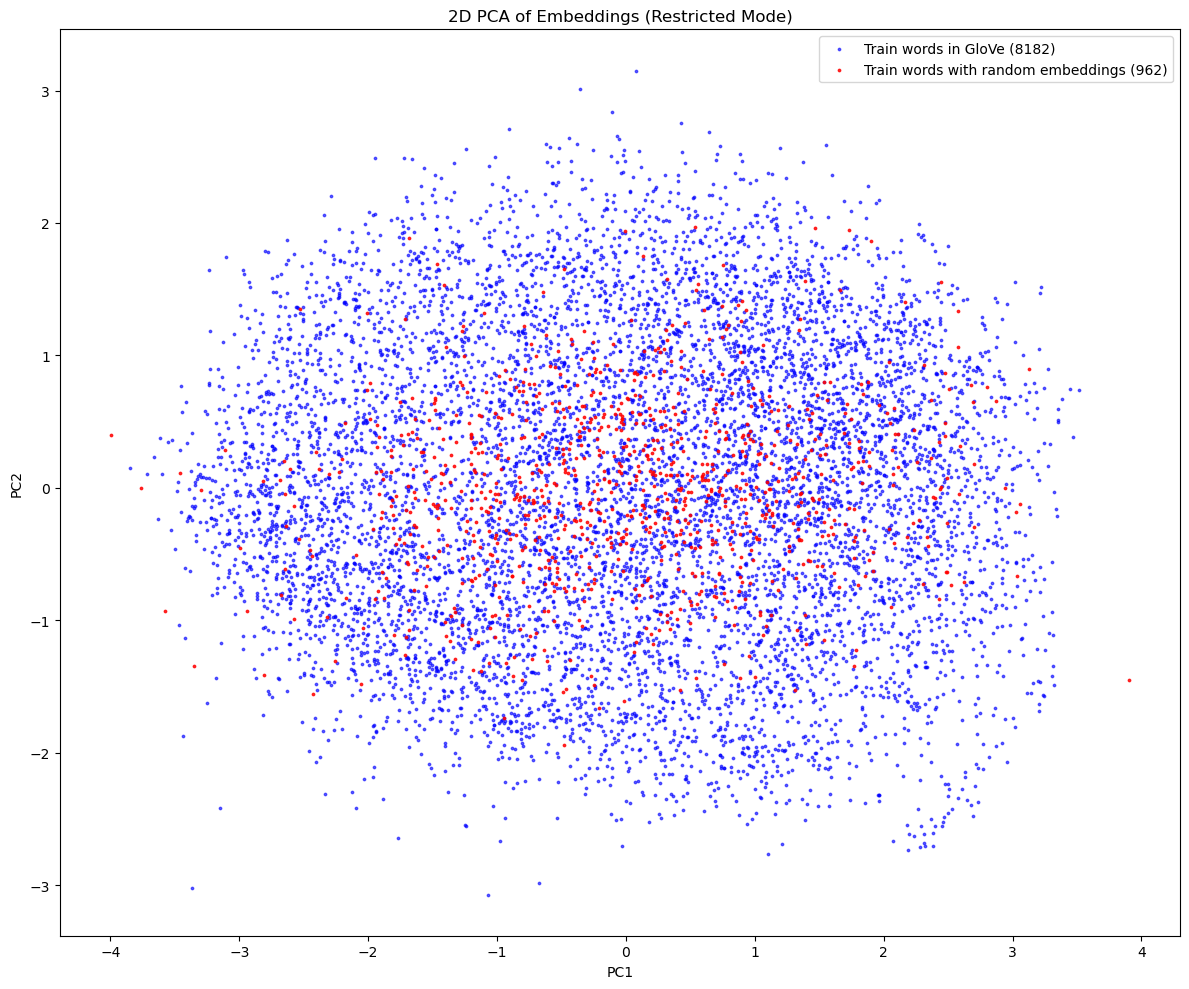

In [ ]:
embedding_vocab = set(embedding_model.index_to_key)
train_vocab = set(train_words)

if USE_FULL_PRELOAD_EMB_MODEL:
    # Full-preload mode: visualize all words in tokenizer with category distinctions
    
    # Get all words from tokenizer
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on origin
    cat_train_in_embed = list(train_vocab & embedding_vocab)        # Train words with GloVe embeddings
    cat_embed_only = list((tokenizer_words & embedding_vocab) - train_vocab)  # GloVe words not in train
    cat_train_random = list(train_vocab - embedding_vocab)          # Train words with random embeddings
    
    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_embed_only = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_embed_only])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])
    
    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_embed_only, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)
    
    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_embed_only = len(embed_embed_only)
    n_train_random = len(embed_train_random)
    
    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_embed_only = all_2d[n_train_in_embed:n_train_in_embed + n_embed_only]
    coords_train_random = all_2d[n_train_in_embed + n_embed_only:]
    
    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_embed_only[:, 0], coords_embed_only[:, 1], s=3, alpha=0.4, color="green",
                label=f"GloVe words not in train ({len(cat_embed_only)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")
    
    plt.title("2D PCA of Embeddings (Full Model Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    # Restricted mode: only train words are in tokenizer
    
    # Get all words from tokenizer (should be only train_vocab)
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on whether they have GloVe embeddings or random ones
    cat_train_in_embed = list(train_vocab & embedding_vocab)    # Train words with GloVe embeddings
    cat_train_random = list(train_vocab - embedding_vocab)      # Train words with random embeddings

    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])

    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)

    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_train_random = len(embed_train_random)

    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_train_random = all_2d[n_train_in_embed:]

    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")

    plt.title("2D PCA of Embeddings (Restricted Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

## Parameters

In [ ]:
NUM_CLASSES = len(label_mapping.keys())
MAX_SEQ_LEN = max([df['cleaned_lemm_tweet'].apply(lambda x: len(x.split())).max() for df in dfs])

## Define the models

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

## Define the parameters of the model

In [ ]:
# define the hyperparameters
hyperparams_models = {
    "baseline": {
        "model": {
            "lstm_units": 64,
        },
        "train": {}
    },
    "stacked": {
        "model": {
            "lstm_units_1": 64,
            "lstm_units_2": 32,
            "dropout_rate_1": 0.3
        },
        "train": {}
    }
}

## Define the model generators 
Here, first the models are generated and then the vocabulary used in the training phase is defined. An embedding matrix is created at each generation in order to have different random embeddings for each model.

In [ ]:
def create_baseline_model(seed, tokenizer=None, vocab_size=None, totally_random=False):
    tf.keras.utils.set_random_seed(seed)

    if vocab_size is None:
        vocab_size = len(tokenizer.word_index) + 1


    embedding_matrix, random_idxs = build_embedding_matrix(
        tokenizer=tokenizer,
        embedding_model=embedding_model,
        seed=seed,
        verbose=False,
        totally_random=totally_random
    )

    assert embedding_matrix.shape[1] == EMBEDDING_DIMENSION


    return Sequential(
        [
            Input(shape=(MAX_SEQ_LEN,)),
            Embedding(
                input_dim=vocab_size,
                output_dim=EMBEDDING_DIMENSION,
                weights=[embedding_matrix],
                mask_zero=False,
                name="encoder_embedding",
            ),
            Bidirectional(
                LSTM(
                    units=hyperparams_models["baseline"]["model"]["lstm_units"],
                    return_sequences=False,
                )
            ),
            Dense(units=NUM_CLASSES, activation="softmax"),
        ],
        name=f"baseline_bidirectional_lstm_{seed}",
    )


def create_stacked_model(seed, tokenizer=None, vocab_size=None, totally_random=False):
    tf.keras.utils.set_random_seed(seed)

    if vocab_size is None:
        vocab_size = len(tokenizer.word_index) + 1

    embedding_matrix, random_idxs = build_embedding_matrix(
        tokenizer=tokenizer,
        embedding_model=embedding_model,
        seed=seed,
        verbose=False,
        totally_random=totally_random
    )

    assert embedding_matrix.shape[1] == EMBEDDING_DIMENSION

    return Sequential(
        [
            Input(shape=(MAX_SEQ_LEN,)),
            Embedding(
                input_dim=vocab_size,
                output_dim=EMBEDDING_DIMENSION,
                weights=[embedding_matrix],
                mask_zero=True,
                name="encoder_embedding",
            ),
            Bidirectional(
                LSTM(
                    units=hyperparams_models["stacked"]["model"]["lstm_units_1"],
                    return_sequences=True,
                )
            ),
            Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_1"]),
            Bidirectional(
                LSTM(
                    units=hyperparams_models["stacked"]["model"]["lstm_units_2"],
                    return_sequences=False,
                )
            ),
            Dense(units=NUM_CLASSES, activation="softmax"),
        ],
        name=f"stacked_bidirectional_lstm_{seed}",
    )


In [ ]:
models = {
    "baseline": create_baseline_model,
    "stacked": create_stacked_model   
}

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

## Utilities

In [ ]:
# function for going from text to sequence
def texts_to_sequences(texts, word_to_idx):
    """Convert text strings to sequences of indices"""
    sequences = []
    for text in texts:
        tokens = text.split()
        indices = [word_to_idx.get(token, word_to_idx.get('<OOV>', 1)) for token in tokens]
        sequences.append(indices)
    return sequences

# Function for setting all the seeds
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# Define function for computing metrics
def compute_metrics(output_info):
    """
    Compute metrics from model outputs
    
    Args:
        output_info: tuple of (labels, logits) or (logits, labels)
    """
    # Handle both orderings
    if len(output_info[0].shape) == 1:  # First element is labels (1D)
        labels, logits = output_info
    else:  # First element is logits (2D)
        logits, labels = output_info
    
    # Convert one-hot to class indices if needed
    if len(labels.shape) > 1:
        labels = np.argmax(labels, axis=-1)
    
    # Get predictions
    preds = np.argmax(logits, axis=-1)
    
    # Calculate metrics
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy,
        "custom_metric": (f1 + accuracy) / 2
    }


class MetricsCallback(Callback):
    """
    Custom callback to compute sklearn metrics on validation data
    and store them in history
    """
    
    def __init__(self, validation_data):
        """
        Args:
            validation_data: tuple of (X_val, y_val)
        """
        super().__init__()
        self.validation_data = validation_data
        
    def on_epoch_end(self, epoch, logs=None):
        """
        Called at the end of each epoch
        Computes metrics and adds them to logs (which become history)
        """
        logs = logs or {}
        
        # Get validation data
        X_val, y_val = self.validation_data
        
        # Get predictions
        y_pred_probs = self.model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=-1)
        
        # Convert one-hot to class indices if needed
        if len(y_val.shape) > 1:
            y_true = np.argmax(y_val, axis=-1)
        else:
            y_true = y_val
        
        # Calculate metrics
        val_f1 = f1_score(y_true, y_pred, average='macro')
        val_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        val_accuracy = accuracy_score(y_true, y_pred)
        
        # Add to logs (these will be saved in history)
        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['val_accuracy_sklearn'] = val_accuracy  # Different from Keras accuracy
        
        # Print metrics
        print(f"\n  - val_f1: {val_f1:.4f} - val_precision: {val_precision:.4f} - val_recall: {val_recall:.4f}")
        

        return logs
    
def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "test_macro_f1", "val_macro_precision", "test_macro_precision",
        "val_macro_recall", "test_macro_recall",
           "val_accuracy","test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run
    
def evaluation(models, X_val_padded, y_val_cat, X_test_padded, y_test_cat, tok,
               seeds=[90,26,6], dir='./', load=False, tot=False):

    if load is True:
        with open(f"{dir}/logs_baseline.pkl", "rb") as f:
            logs_baseline = pickle.load(f)
        with open(f"{dir}/logs_stacked.pkl", "rb") as f:
            logs_stacked = pickle.load(f)
            print('logs loaded')
    else:
    
        logs = {'baseline':{'val_macro_f1':[], 'val_macro_precision':[], 'val_macro_recall':[], 'val_accuracy':[],
                            'test_macro_f1':[], 'test_macro_precision':[], 'test_macro_recall':[], 'test_accuracy':[]}, 
                'stacked':{'val_macro_f1':[], 'val_macro_precision':[], 'val_macro_recall':[], 'val_accuracy':[],
                            'test_macro_f1':[], 'test_macro_precision':[], 'test_macro_recall':[], 'test_accuracy':[]}}

        for val in [True, False]:
            if val is True:
                n='val'
                X_padded=X_val_padded
                y_cat=y_val_cat
            else:
                n='test'
                X_padded=X_test_padded
                y_cat=y_test_cat

            for seed in seeds:
                set_all_seeds(seed)
                for model in models:
                    current_model = models[model](seed=seed, tokenizer=tok, totally_random=tot)
                    current_model.load_weights(f'{dir}/weights_{model}_seed{seed}.weights.h5')

                    # Get predictions
                    y_pred_probs = current_model.predict(X_padded, verbose=0)
                    y_pred = np.argmax(y_pred_probs, axis=-1)

                    # Convert one-hot to class indices if needed
                    if len(y_cat.shape) > 1:
                        y_true = np.argmax(y_cat, axis=-1)
                    else:
                        y_true = y_cat

                    # Calculate metrics
                    f1 = f1_score(y_true, y_pred, average='macro')
                    precision=precision_score(y_true, y_pred, average='macro')
                    recall=recall_score(y_true, y_pred, average='macro')
                    accuracy=accuracy_score(y_true, y_pred)

                    # Add to logs (these will be saved in history)
                    logs[model][f'{n}_macro_f1'].append(f1)
                    logs[model][f'{n}_macro_precision'].append(precision)
                    logs[model][f'{n}_macro_recall'].append(recall)
                    logs[model][f'{n}_accuracy'].append(accuracy)

        logs['baseline']['seed']=logs['stacked']['seed']=seeds
        logs_baseline=logs['baseline']
        logs_stacked=logs['stacked']

        with open(f"{dir}/logs_baseline.pkl", "wb") as f:
            pickle.dump(logs_baseline, f)
        with open(f"{dir}/logs_stacked.pkl", "wb") as f:
            pickle.dump(logs_stacked, f)
            print('logs dumped')

        
    return pd.DataFrame(logs_baseline), pd.DataFrame(logs_stacked)

def train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded, y_val_cat, tok, class_weight_dict=None,
                         seeds=[90, 26, 6], lr=1e-4, wd=0.01, patience=7, 
                         epochs=40, batch_size=32, save_weights=True, dir='./', load_weights=False, tot=False):
    """Train and evaluate models with multiple random seeds"""

    if load_weights is True:
        print('='*80)
        with open(f"{dir}/histories.pkl", "rb") as f:
            histories = pickle.load(f)
        with open(f"{dir}/results.pkl", "rb") as f:
            results = pickle.load(f)
        with open(f"{dir}/f1.pkl", "rb") as f:
            f1_scores = pickle.load(f)


        print('history loaded')
        print('='*80)
    else:
        histories = {}
        results = {}
        f1_scores = {model_name: [] for model_name in models.keys()}

        for seed in seeds:
            print(f"\n{'='*80}")
            print(f"SEED: {seed}")
            print(f"{'='*80}")

            set_all_seeds(seed)

            histories[seed] = {}
            results[seed] = {}

            for model_name in models.keys():
                # Create new model
                current_model = models[model_name](seed=seed, tokenizer=tok,totally_random=tot)

            
            
                print(f"\n{'='*60}")
                print(f"Training: {model_name} (seed={seed})")
                print(f"{'='*60}")


                # Compile
                current_model.compile(
                optimizer=AdamW(learning_rate=lr, weight_decay=wd, clipnorm=1),
                loss='categorical_crossentropy',
                metrics=['accuracy']
                )
                

                # Print summary only once
                if seed == seeds[0]:
                    print("\nModel Architecture:")
                    current_model.summary()

                # Custom metrics callback
                metrics_callback = MetricsCallback(
                    validation_data=(X_val_padded, y_val_cat)
                )

                early_stopping = EarlyStopping(
                    monitor='val_f1',
                    patience=patience,
                    mode='max',
                    restore_best_weights=True,
                    verbose=1
                )

                # Combine callbacks
                callbacks = [metrics_callback, early_stopping]

                if class_weight_dict is not None:
                    history = current_model.fit(
                        x=X_train_padded,
                        y=y_train_cat,
                        validation_data=(X_val_padded, y_val_cat),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=1,
                        class_weight=class_weight_dict
                    )
                else:
                    history = current_model.fit(
                        x=X_train_padded,
                        y=y_train_cat,
                        validation_data=(X_val_padded, y_val_cat),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=1,
                        class_weight=class_weight_dict
                    )

                print(f"\n{'='*60}")
                print("Training History Metrics Available:")
                print(f"{'='*60}")
                print(f"Keys in history: {history.history.keys()}")
                # Will show: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 
                #                       'val_f1', 'val_precision', 'val_recall'])



                best_epoch_idx = np.argmax(history.history['val_f1'])

                # Get final metrics
                final_metrics = {
                    'val_accuracy': history.history['val_accuracy'][best_epoch_idx],
                    'val_loss': history.history['val_loss'][best_epoch_idx],
                    'val_f1': history.history['val_f1'][best_epoch_idx],
                    'val_precision': history.history['val_precision'][best_epoch_idx],
                    'val_recall': history.history['val_recall'][best_epoch_idx]
                }

                # Store results
                histories[seed][model_name] = history
                results[seed][model_name] = final_metrics
                f1_scores[model_name].append(final_metrics['val_f1'])

                print(f"\nFinal Results for {model_name} (seed={seed}):")
                print(f"  Val Accuracy: {final_metrics['val_accuracy']:.4f}")
                print(f"  Val F1: {final_metrics['val_f1']:.4f}")
                print(f"  Val Precision: {final_metrics['val_precision']:.4f}")
                print(f"  Val Recall: {final_metrics['val_recall']:.4f}")

                # Save weights
                if save_weights:
                    weight_path = f'{dir}/weights_{model_name}_seed{seed}.weights.h5'
                    current_model.save_weights(weight_path)

                # Clean up
                tf.keras.backend.clear_session()

        if save_weights is True:
            print('='*80)
            with open(f"{dir}/histories.pkl", "wb") as f:
                pickle.dump(histories, f)
            with open(f"{dir}/results.pkl", "wb") as f:
                pickle.dump(results, f)
            with open(f"{dir}/f1.pkl", "wb") as f:
                pickle.dump(f1_scores, f)
            print('history loaded')
            print('='*80)

            #logs_baseline, logs_stacked=evaluation(models, seeds, dir)
            #agg1, _ = mean_std(logs_baseline)
            #agg2, _ = mean_std(logs_stacked)
            #print('Baseline model')
            #display(agg1)
            #print('Stacked model')
            #display(agg2)
            #return

    # Summary
    print(f"\n{'='*80}")
    print("SUMMARY ON VALIDATION SET ACROSS SEEDS")
    print(f"{'='*80}")
    
    for model_name, scores in f1_scores.items():
        mean_f1 = np.mean(scores)
        std_f1 = np.std(scores, ddof=1)
        print(f"\n{model_name}:")
        print(f"  F1 scores: {[f'{s:.4f}' for s in scores]}")
        print(f"  Mean F1: {mean_f1:.4f} ± {std_f1:.4f}")
    
    return histories, results, f1_scores

# Add this RIGHT BEFORE training
def clear_all_memory():
    """Aggressive memory cleanup"""
    tf.keras.backend.clear_session()
    gc.collect()
    
    # If on GPU
    try:
        from numba import cuda
        cuda.select_device(0)
        cuda.close()
    except:
        pass


def plot_summary_metrics(df_out: pd.DataFrame, agg: pd.DataFrame, best_run: pd.Series = None,
                         figsize=(12, 10), save_path: str = None):
    """
    3-row figure:
      row1: grouped bars for validation metrics (one bar per seed per metric)
      row2: grouped bars for test metrics
      row3: mean ± std for each metric across seeds (no boxplots)
    """
    val_metrics = ["val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy"]
    test_metrics = ["test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"]
    all_metrics = val_metrics + test_metrics

    # Input checks
    missing = [c for c in all_metrics if c not in df_out.columns]
    if missing:
        raise ValueError(f"df_out missing columns: {missing}")

    seeds = df_out["seed"].tolist()
    n_seeds = len(seeds)
    cmap = plt.get_cmap("tab10")

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize)
    plt.subplots_adjust(hspace=0.5)

    # Row 1: Validation grouped bars
    ax = axes[0]
    x = np.arange(len(val_metrics))
    total_width = 0.8
    bar_width = total_width / max(1, n_seeds)
    offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_seeds)

    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in val_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("val_", "") for m in val_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Validation metrics by seed")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(ncol=min(4, n_seeds), fontsize="small", loc="upper center", bbox_to_anchor=(0.5, -0.15))

    # if best_run is not None:
    #     for j, m in enumerate(val_metrics):
    #         best_val = float(best_run[m])
    #         ax.scatter(j, best_val + 0.03, marker="*", s=120, c="black", zorder=6)

    # Row 2: Test grouped bars
    ax = axes[1]
    x = np.arange(len(test_metrics))
    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in test_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("test_", "") for m in test_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Test metrics by seed")
    ax.grid(axis="y", alpha=0.3)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    # if best_run is not None:
    #     for j, m in enumerate(test_metrics):
    #         best_val = float(best_run[m])
    #         ax.scatter(j, best_val + 0.03, marker="*", s=120, c="black", zorder=6)
    #         print("j" , j, "m", m, "best_val", best_val)

    # Row 3: Mean ± Std only (no boxplots)
    ax = axes[2]
    all_metrics = ["val_macro_f1","test_macro_f1", "val_macro_precision","test_macro_precision", 
                   "val_macro_recall","test_macro_recall", "val_accuracy","test_accuracy"]
    
    # get means and stds from agg if available; otherwise compute from df_out
    if ("mean" in agg.index) and ("std" in agg.index):
        means = agg.loc["mean", all_metrics].values
        stds = agg.loc["std", all_metrics].values
    else:
        means = np.array([df_out[m].mean() for m in all_metrics])
        stds = np.array([df_out[m].std(ddof=1) for m in all_metrics])

    x = np.arange(len(all_metrics))
    colors = [cmap(i % 10) for i in range(len(all_metrics))]
    bars = ax.bar(x, means, yerr=stds, capsize=6, tick_label=[m for m in all_metrics],
                  color=colors, alpha=0.85, edgecolor='k')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean ± std")
    ax.set_title("Mean ± Std across seeds (validation + test metrics)")
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # optional: annotate mean values above bars
    for xi, (mu, sigma) in enumerate(zip(means, stds)):
        ax.text(xi, mu + sigma + 0.02, f"{mu:.3f}±{sigma:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_training_history(histories):
    """Plot training and validation metrics for all seeds and models"""
    
    seeds = list(histories.keys())
    n_seeds = len(seeds)
    

    
    fig, axes = plt.subplots(n_seeds, 4, figsize=(25, 5 * n_seeds))
    
    # Handle single seed case
    if n_seeds == 1:
        axes = axes.reshape(1, -1)
    
    for i, seed in enumerate(seeds):
        print(f"\nPlotting seed: {seed}")
        
        for model_name in histories[seed].keys():
            print(f"  Model: {model_name}")
            best_epoch = np.argmax(histories[seed][model_name].history["val_f1"])+1
            
            # Get history as DataFrame
            history_df = pd.DataFrame(histories[seed][model_name].history)
            epochs = range(1, len(history_df) + 1)
            
            # Plot 1: Loss
            if model_name=='stacked':
                    line='--'
                    q=1
                    s=3
            else:
                    line=None
                    q=0
                    s=2
            axes[i, q].plot(epochs, history_df['loss'], 
                          label=f'{model_name} - Train Loss', 
                          linewidth=2, marker='o', markersize=4, linestyle=line, color='orange')
            axes[i, q].plot(epochs, history_df['val_loss'], 
                          label=f'{model_name} - Val Loss', 
                          linewidth=2, marker='s', markersize=4, linestyle=line, color='k')
            axes[i,q].axvline(best_epoch, color="red", label=f"best epoch {model_name}")
            axes[i, q].set_xlabel('Epoch', fontsize=11)
            axes[i, q].set_ylabel('Loss', fontsize=11)
            axes[i, q].set_title(f'Seed {seed} - Loss', fontsize=12, fontweight='bold')
            axes[i, q].legend(loc='best')
            axes[i, q].grid(True, alpha=0.3)
            
            
            # Plot 2: Metrics (Accuracy, F1, Precision, Recall)
            #axes[i, 1].plot(epochs, history_df['val_accuracy'], 
            #              label=f'{model_name} - Val Accuracy', 
            #              linewidth=2, marker='o', markersize=4)
            #
            # Check if custom metrics exist
            if 'val_f1' in history_df.columns:
                axes[i, s].plot(epochs, history_df['val_f1'], 
                              label=f'{model_name} - Val F1', 
                              linewidth=2, marker='^', markersize=4, color='green', linestyle=line)
            
            if 'val_precision' in history_df.columns:

                axes[i, s].plot(epochs, history_df['val_precision'], 
                              label=f'{model_name} - Val Precision', 
                              linewidth=2, marker='s', markersize=4, color='blue', linestyle=line)
            
            if 'val_recall' in history_df.columns:
                axes[i, s].plot(epochs, history_df['val_recall'], 
                              label=f'{model_name} - Val Recall', 
                              linewidth=2, marker='d', markersize=4, color='gray', linestyle=line)
                
            axes[i, s].axvline(best_epoch, color='red', label=f"best epoch {model_name}")
            axes[i, s].set_xlabel('Epoch', fontsize=11)
            axes[i, s].set_ylabel('Score', fontsize=11)
            axes[i, s].set_title(f'Seed {seed} - Metrics', fontsize=12, fontweight='bold')
            axes[i, s].legend(loc='best', fontsize=9)
            axes[i, s].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Convert the corpus for the model
Convert text to sequences and pad the text. One-hot encode the categorical variables.

In [ ]:
# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer.word_index)

In [ ]:
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


In [ ]:
y_train_cat = to_categorical(train_df['label'].values, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(val_df['label'].values, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(test_df['label'].values, num_classes=NUM_CLASSES)

print(f"y_train shape: {y_train_cat.shape}")
print(f"Number of classes: {NUM_CLASSES}")

y_train shape: (2873, 4)
Number of classes: 4


## Training and evaluation

The dataset is heavily unbalanced as we can see here:

In [ ]:
print('Train proportions')
display(train_df['label'].value_counts(normalize=True))

Train proportions


label
0    0.701009
1    0.186913
3    0.064045
2    0.048033
Name: proportion, dtype: float64

For this reason the we use the `class_weight_dict` whilw fitting the model which allows to give different weights to different classes in the loss, in order to give more importance to classes which are less present in the dataset.

In [ ]:
# Calculate class weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict={}

# Use this routine if we want to use different weights from the one computed by the function
for i in range(len(dict(enumerate(class_weights)))):
    class_weight_dict[i]=dict(enumerate(class_weights))[i]*1

print(class_weight_dict)

{0: 0.3566285998013903, 1: 1.3375232774674115, 2: 5.204710144927536, 3: 3.9035326086956523}


In [ ]:
# Use this to load weights
load_weights=load_LSTM

# Run this to clean memory
if not load_weights: # Only clear memory if we are actually going to train
    clear_all_memory()

# Use the function to either make a new fitting or load weights
histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, 
                        y_train_cat, X_val_padded,
                        y_val_cat, tok=tokenizer, class_weight_dict=class_weight_dict, 
                        dir='./weights/base', load_weights=load_weights)


SEED: 90

Training: baseline (seed=90)

Model Architecture:


2026-01-09 11:43:18.548840: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-01-09 11:43:18.548871: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-01-09 11:43:18.548880: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-01-09 11:43:18.548894: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-09 11:43:18.548903: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "baseline_bidirectional_lstm_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,696 (1.97 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,656 (2.13 MB)

 Trainable params: 557,656 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0585 - loss: 1.4156
  - val_f1: 0.1779 - val_precision: 0.2213 - val_recall: 0.2768
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.0592 - loss: 1.3818 - val_accuracy: 0.2867 - val_loss: 1.4026 - val_f1: 0.1779 - val_precision: 0.2213 - val_recall: 0.2768 - val_accuracy_sklearn: 0.2867
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4307 - loss: 1.4028
  - val_f1: 0.2261 - val_precision: 0.2185 - val_recall: 0.2679
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.4414 - loss: 1.3724 - val_accuracy: 0.4800 - val_loss: 1.3981 - val_f1: 0.2261 - val_precision: 0.2185 - val_recall: 0.2679 - val_accuracy_sklearn: 0.4800
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4743 - loss: 1.3899
  - val_f1: 0.1984 - val_precision: 0.2640 - val_recall: 0.3001
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.3971 - loss: 1.3619 - val_accuracy: 0.2333 - val_loss: 1.3876 - val_f1: 

Now plot the histories


Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 26
  Model: baseline
  Model: stacked

Plotting seed: 6
  Model: baseline
  Model: stacked


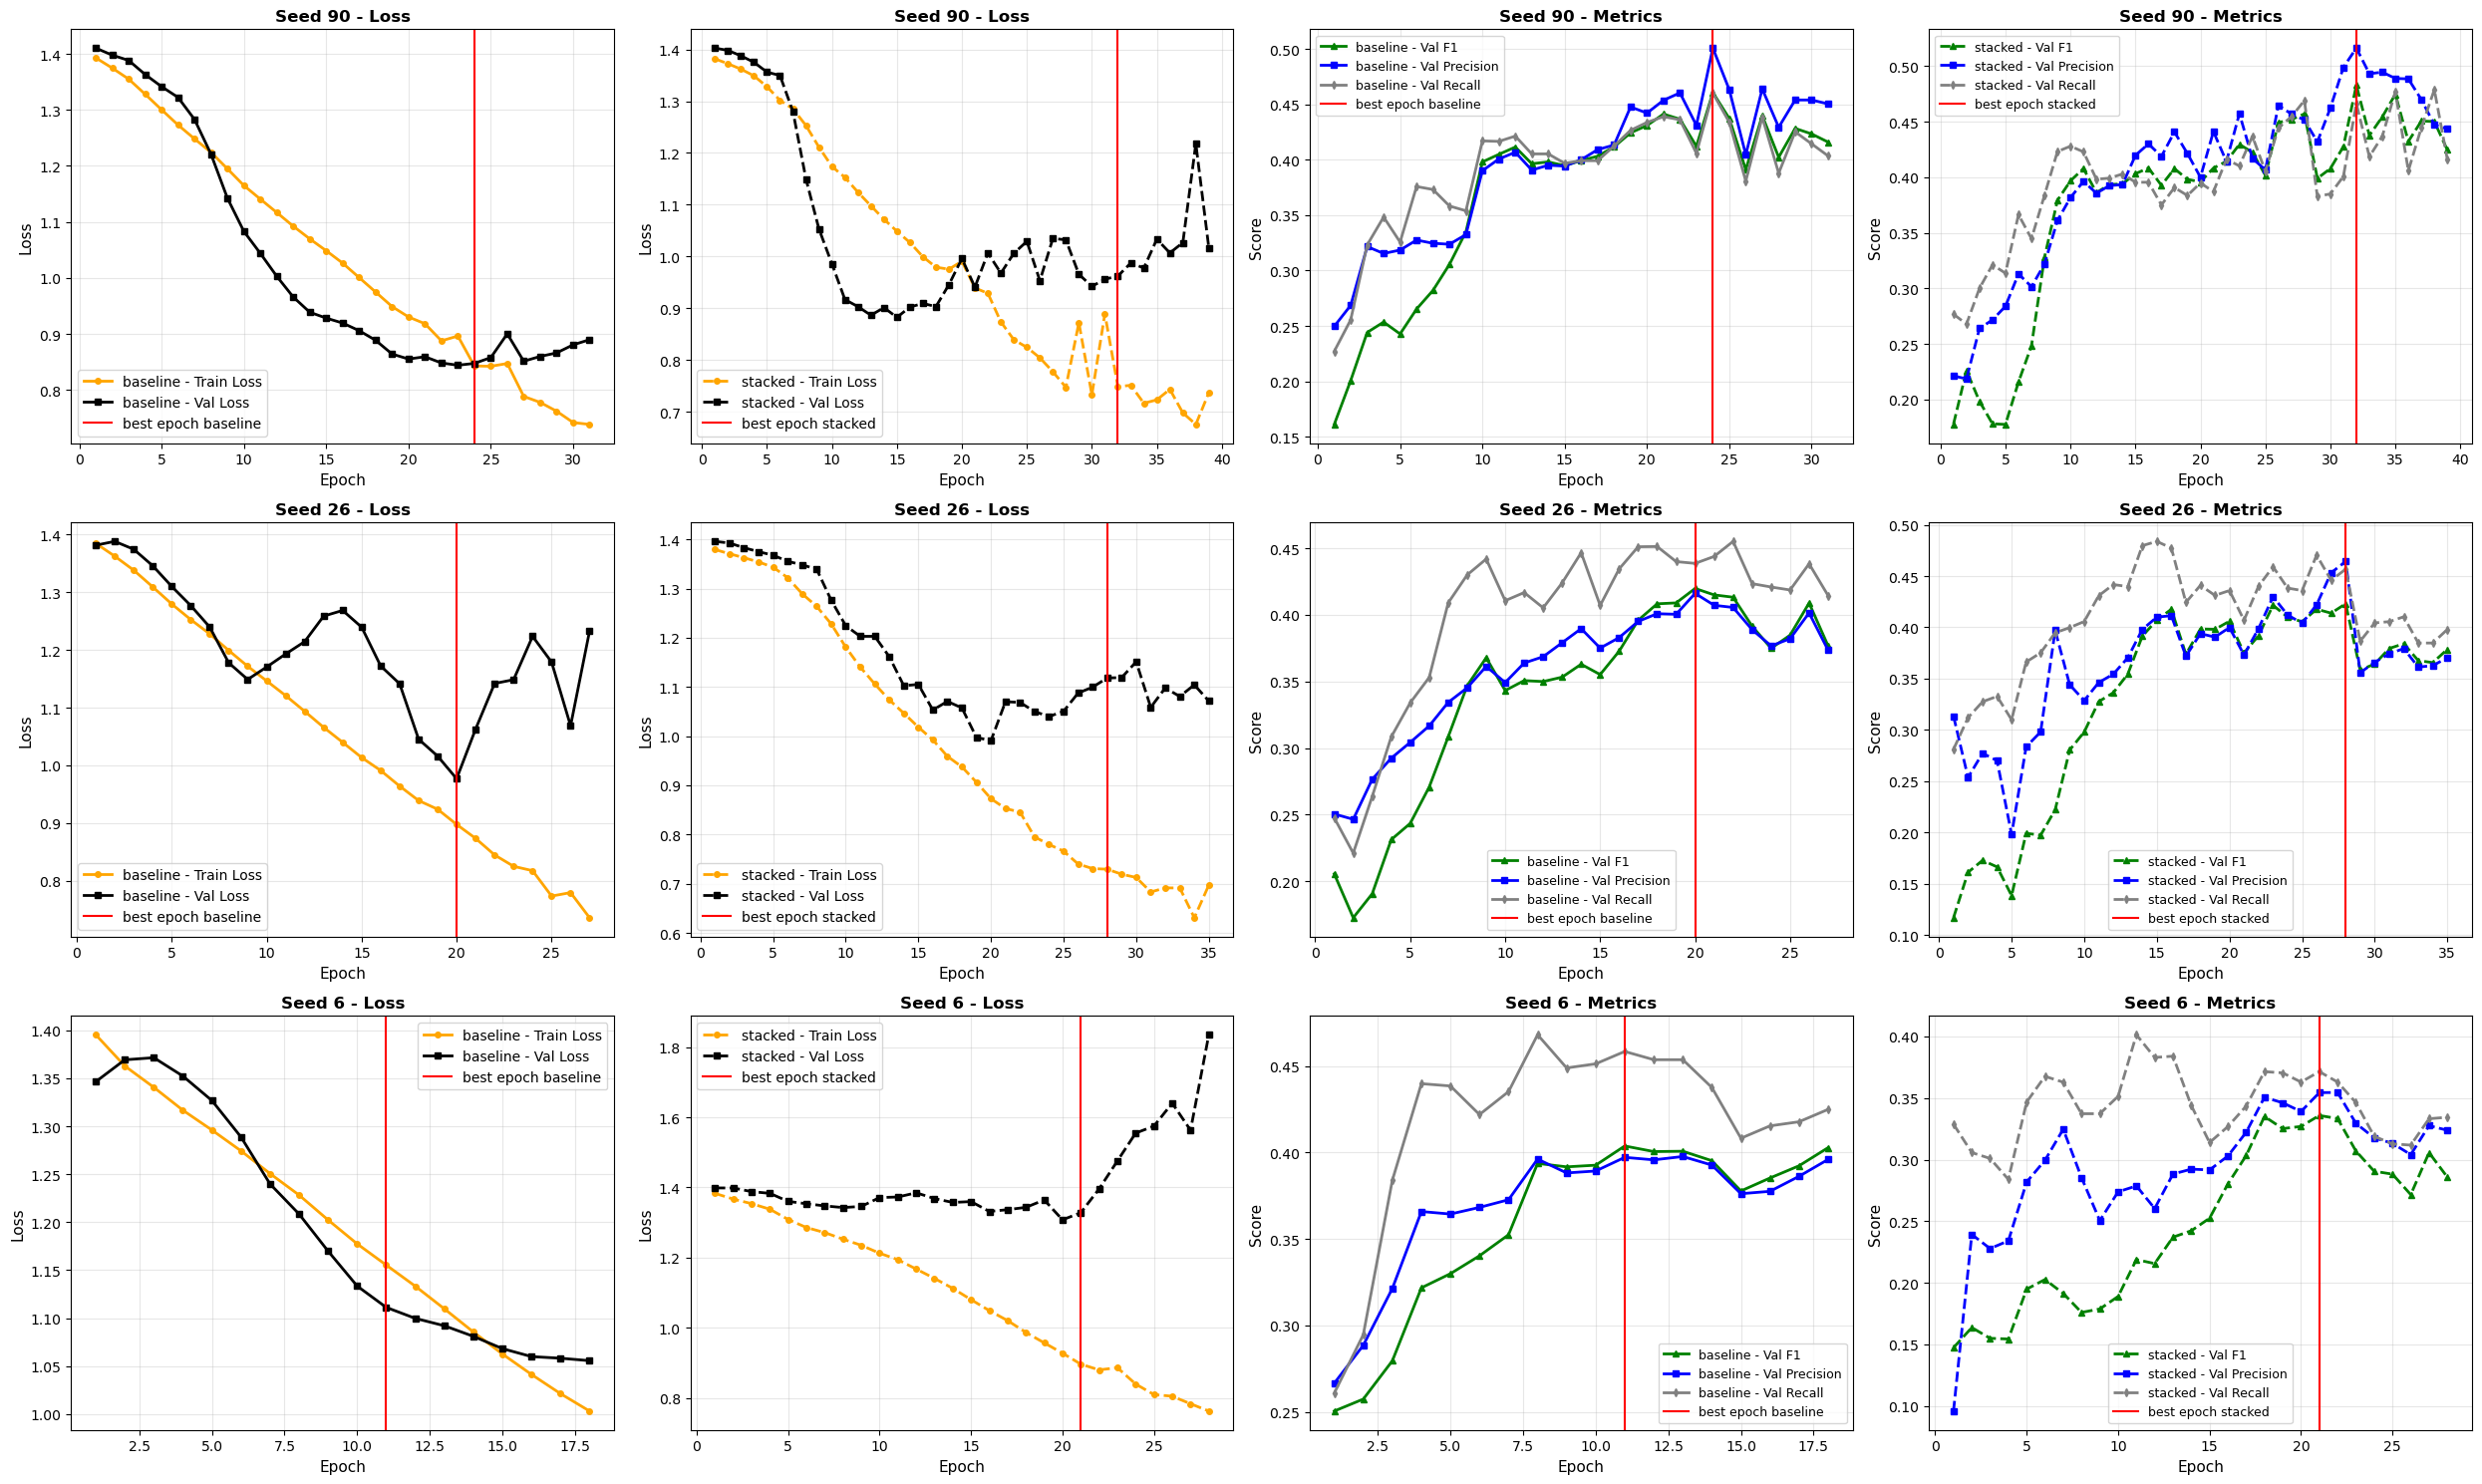

In [ ]:
# Call once for all histories
plot_training_history(histories)

Now chose the best model based on the results of the macro f1 on the validation set.

logs dumped


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.460694,0.500822,0.460223,0.753333,0.393955,0.405199,0.392087,0.635714,90
1,0.419799,0.416123,0.438613,0.633333,0.439314,0.433879,0.465537,0.600000,26
2,0.403780,0.397215,0.458411,0.573333,0.381154,0.385125,0.418478,0.525000,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.428091,0.404808,0.438053,0.408067,0.452415,0.425367,0.653333,0.586905
std,0.029349,0.030561,0.055175,0.024503,0.011988,0.037206,0.091652,0.056507


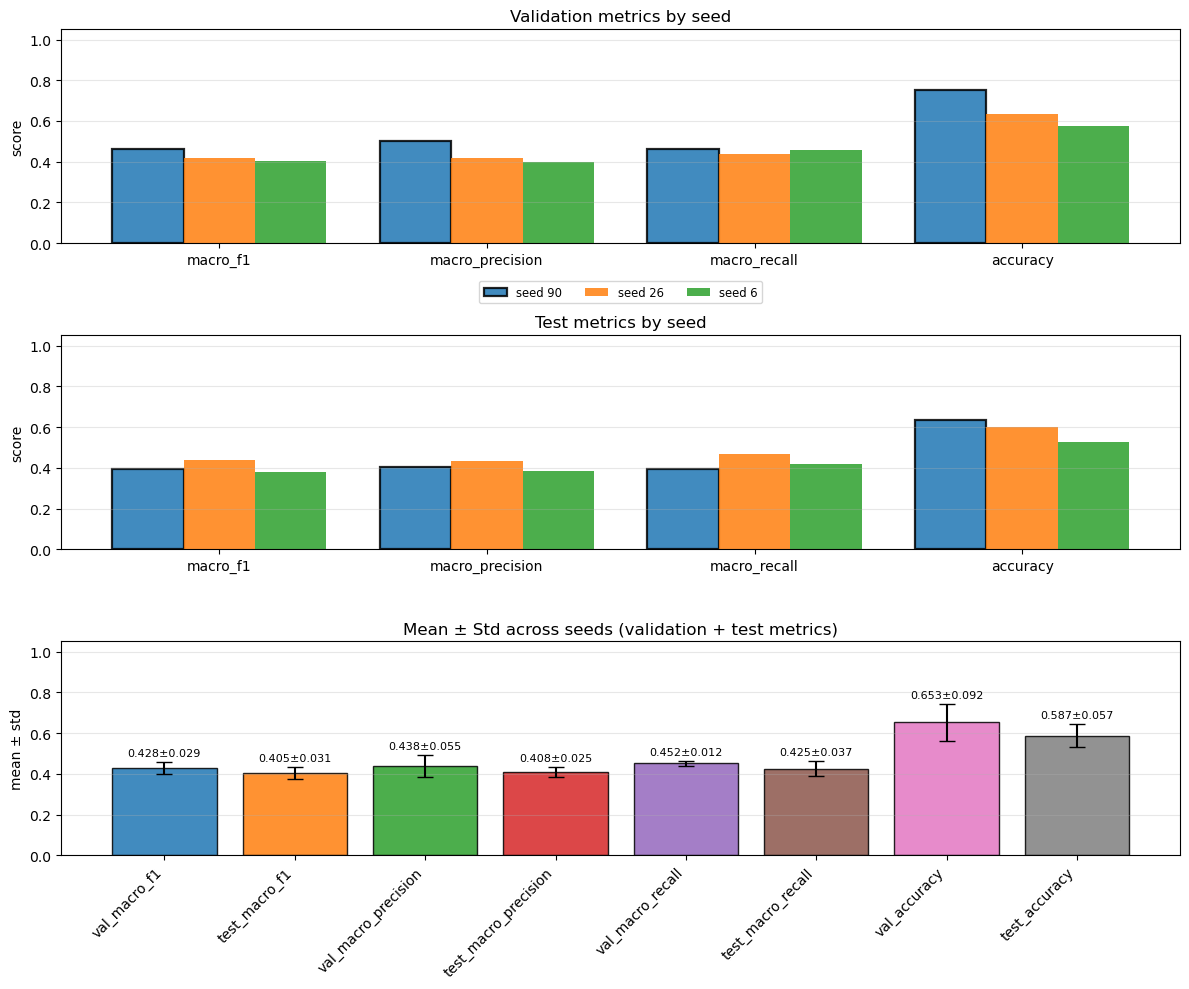

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.482869,0.516201,0.466278,0.706667,0.399474,0.403070,0.405638,0.600000,90
1,0.423030,0.464286,0.456755,0.640000,0.373047,0.388667,0.396771,0.528571,26
2,0.335871,0.354423,0.371480,0.453333,0.390045,0.403329,0.455383,0.500000,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.413923,0.387522,0.444970,0.398356,0.431504,0.419264,0.600000,0.542857
std,0.073921,0.013393,0.082601,0.008391,0.052200,0.031593,0.131318,0.051508


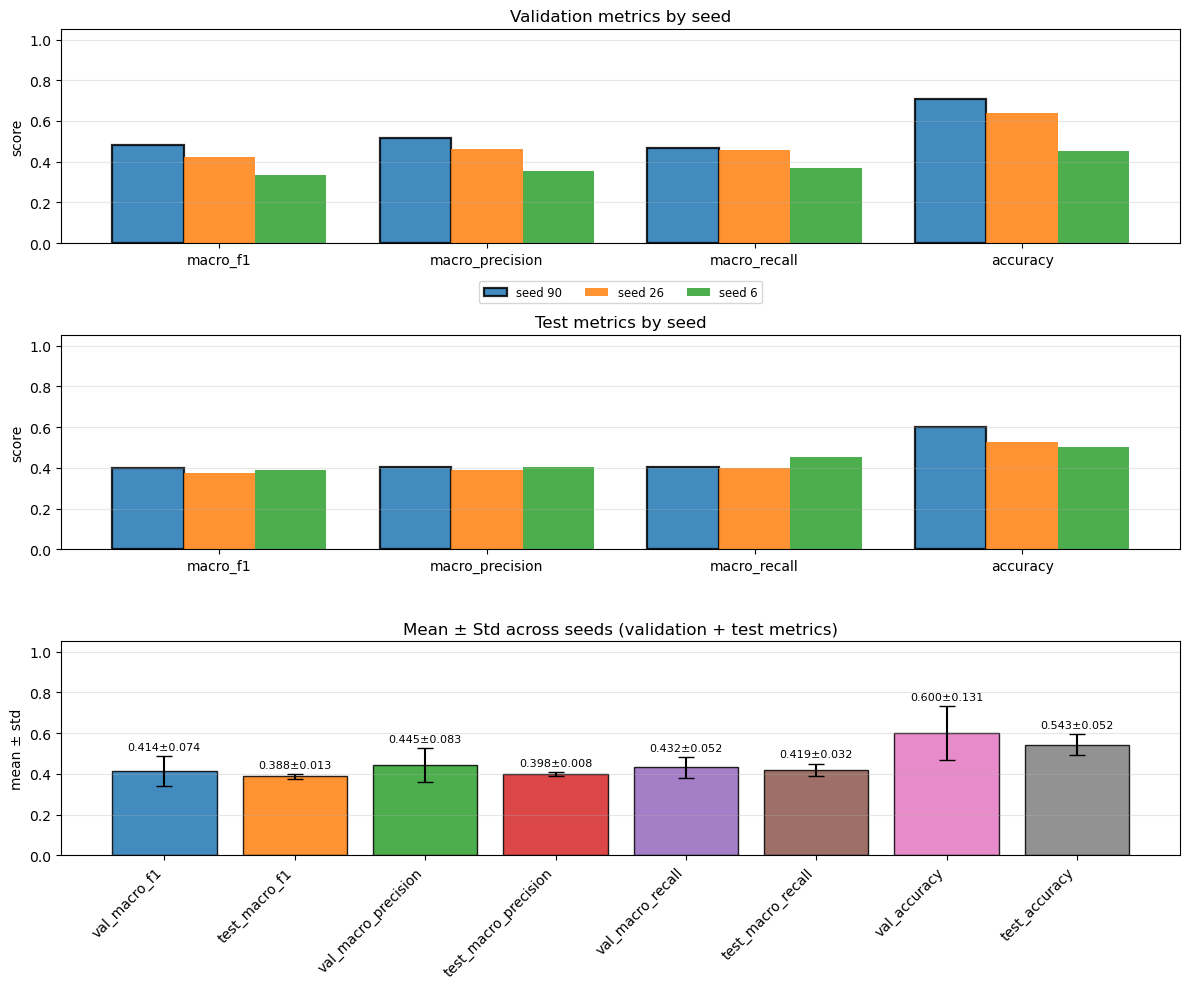

In [ ]:
# Change it for loading
load=load_LSTM

# Calculate the evaluation
logs_base, logs_stacked = evaluation(models, X_val_padded, y_val_cat, X_test_padded,
                                    y_test_cat, tok=tokenizer, dir='./weights/base', load=load)

# Show on the baseline model
agg_base, best_run_base = mean_std(logs_base)
display(logs_base)
display(agg_base)
plot_summary_metrics(logs_base, agg_base, best_run_base)

# Show the results on the stacked model
agg_stacked, best_run_stacked=mean_std(logs_stacked)
display(logs_stacked)
display(agg_stacked)
plot_summary_metrics(logs_stacked, agg_stacked, best_run_stacked)

It is interesting to see that the best seed is different for the two models (42 for the stacked model while 77 for baseline). Even though the stacked model is better on the validation set, they perform similarly on the test set. For this reason task 7 will be done on both models.

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

--- 

### Utilites

In [ ]:
# Function to explore datasets
def print_datasets_info(train_data, test_data, val_data, tokenizer):
    print(60*"-")
    print("Datasets info:")
    print(60*"-")
    print(f"Train data dimension: {train_data.num_rows}")
    print(f"Test data dimension: {test_data.num_rows}")
    print(f"Validation data dimension: {val_data.num_rows}")
    print(60*"-")
    print(f"columns of datasets objects: {train_data.features}")
    print(60*"-")
    print("Encoding of labels:")
    print(" \"-\":0, \"DIRECT\":1, \"JUDGEMENTAL\":2, \"REPORTED\":3")
    print(set(train_data['label']))

    original_text = train_data['tweet'][26:30]
    decoded_text = tokenizer.batch_decode(train_data['input_ids'][26:30])
    id_text = train_data['input_ids'][26:30]
    print(60*"-")
    for i in range(len(original_text)):
        print(f"Original tweet: {original_text[i][:150]}")
        print(f"Token IDs: {id_text[i][:150]}")
        print(f"Decoded tweet: {decoded_text[i][:150]}")
        print(30*"-")

# Metrics computation
def compute_metrics(output_info):
    logits, labels = output_info
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy
    }

# Function to count trainable parameters when fine-tuning partially
def count_trainable_parameters(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total

# Training and evaluation function
def train_evaluate_model(
    seeds: list[int],
    hyperparameters: dict,
    dataset:list, # expects [TRAIN_DATA, VAL_DATA, TEST_DATA]
    output_dir: str = "./pt_checkpoints",
    fine_tune_partially: bool = False,
    early_patience: int = 0,
    VERBOSE: bool = True,
    best_subdir_name: str = "best_model"  # folder name inside each run folder where best model is saved
) -> tuple[list[dict], dict, dict]:
    """
    Returns:
      - results: list[dict] with per-seed metrics (same as before)
      - logs: dict of raw trainer.log_history if DEBUG True per seed
      - best_model_dirs: dict mapping seed -> path where the seed's best model is saved
    """
    results = []
    logs = {}
    best_model_dirs = {}

    for seed in seeds:
        # deterministic seeds 
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        # HF helper (sets python/numpy/torch seeds)
        set_seed(seed)

        # HF helper (sets python/numpy/torch seeds)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # unique output folder per seed so things don't overwrite
        run_output_dir = os.path.join(output_dir, f"seed_{seed}")
        os.makedirs(run_output_dir, exist_ok=True)
        
        hf_logging.set_verbosity_error()
        # Model loading
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_CARD,
            num_labels=NUM_LABLES,
            from_tf=False,
            ignore_mismatched_sizes=True,
            id2label=reverse_mapping,
            label2id=label_mapping
        )
        hf_logging.set_verbosity_warning() 

        if VERBOSE:
            if seed == seeds[0]:
                print("=== Model Summary ===")
                print(model)
                trainable, total = count_trainable_parameters(model)
                print("=== Trainable Parameters ===")
                print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        if fine_tune_partially:
            for param in model.roberta.parameters():
                param.requires_grad = False
            for name, param in model.named_parameters():
                if "classifier" in name or "pooler" in name or "dense" in name:
                    param.requires_grad = True
            trainable, total = count_trainable_parameters(model)
            if seed == seeds[0]:
                print("Freezing encoder parameters, fine-tuning classification head only.")
                print(f"Trainable params after freezing encoder: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        print(f"\n=== RUN seed={seed} ===")
        # Training
        training_args = TrainingArguments(
            output_dir=run_output_dir,             
            learning_rate=hyperparameters["learning_rate"],                   
            per_device_train_batch_size=hyperparameters["batch_size"],     # defines distributed training
            per_device_eval_batch_size=hyperparameters["batch_size"],
            num_train_epochs=hyperparameters["epochs"],
            weight_decay=hyperparameters["weight_decay"],
            eval_strategy="epoch",             # when to report evaluation metrics/losses
            save_strategy="epoch",             # when to save checkpoint
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",   # ensure best model by macro F1
            greater_is_better=True,
            report_to='none',                   # disabling wandb 
            seed=seed
        )
        if early_patience > 0:
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=dataset[0],
                eval_dataset=dataset[1],
                processing_class=tokenizer,
                data_collator=data_collator,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=early_patience)]
            )
        else:
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=dataset[0],
                eval_dataset=dataset[1],
                processing_class=tokenizer,
                data_collator=data_collator,
                compute_metrics=compute_metrics
            )

        trainer.train()

        # gather logs 
        logs_hist = trainer.state.log_history
        df_logs = pd.DataFrame(logs_hist)
        logs[seed] = df_logs

        # best info
        best_metric = trainer.state.best_metric
        # epoch number from folder name
        best_epoch = int(trainer.state.best_model_checkpoint.split("-")[-1]) / 360

        # Evaluate on validation and test
        val_res = trainer.evaluate(eval_dataset=dataset[1])
        test_res = trainer.evaluate(eval_dataset=dataset[2])

        record = {
            "seed": seed,
            "val_macro_f1": val_res.get("eval_macro_f1"),
            "val_macro_precision": val_res.get("eval_macro_precision"),
            "val_macro_recall": val_res.get("eval_macro_recall"),
            "val_accuracy": val_res.get("eval_accuracy"),
            "test_macro_f1": test_res.get("eval_macro_f1"),
            "test_macro_precision": test_res.get("eval_macro_precision"),
            "test_macro_recall": test_res.get("eval_macro_recall"),
            "test_accuracy": test_res.get("eval_accuracy"),
            "best_epoch": best_epoch,
            "best_metric": best_metric,
        }
        results.append(record)
        
        if best_subdir_name is not None:
            # Save best model into a dedicated subfolder so it's easy to reload later
            best_dir = os.path.join(run_output_dir, best_subdir_name)
            os.makedirs(best_dir, exist_ok=True)

            # Trainer.save_model will save the model and config into best_dir
            trainer.save_model(best_dir)

            best_model_dirs[seed] = best_dir

        # clean up GPU memory
        del trainer
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return results, logs, best_model_dirs

# Compute mean and std (for validation and test metrics)
def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy",
        "test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run


# Helper function to extract per-epoch metrics from log history DataFrame
def _epoch_aggregates(df: pd.DataFrame):
    """Return dicts of per-epoch Series for eval and train metrics (robust to missing columns)."""
    logs = df.copy()
    # eval rows: rows that contain eval_loss (evaluation events)
    if "eval_loss" in logs.columns:
        df_eval = logs[logs["eval_loss"].notna()].sort_values("step")
        if not df_eval.empty and "epoch" in df_eval.columns:
            df_eval = df_eval.groupby("epoch", as_index=False).last().sort_values("epoch")
        else:
            df_eval = pd.DataFrame()
    else:
        df_eval = pd.DataFrame()

    # train-step losses: rows where 'loss' (per-step) is logged
    if "loss" in logs.columns:
        df_train_steps = logs[logs["loss"].notna()].sort_values("step")
        if "epoch" in df_train_steps.columns:
            df_train_steps = df_train_steps.groupby("epoch", as_index=False).last().sort_values("epoch")
        # if epoch missing we still keep the sequence by step
    else:
        df_train_steps = pd.DataFrame()

    # Build per-epoch arrays (index = epoch)
    def series_from_eval(col):
        return df_eval.set_index("epoch")[col] if (not df_eval.empty and col in df_eval.columns) else pd.Series(dtype=float)

    eval_f1 = series_from_eval("eval_macro_f1")
    eval_prec = series_from_eval("eval_macro_precision")
    eval_rec = series_from_eval("eval_macro_recall")
    eval_loss = series_from_eval("eval_loss")
    eval_acc = series_from_eval("eval_accuracy")

    # Derive train_loss_per_epoch: prefer df_train_steps grouped by epoch if available,
    # otherwise attempt to map last step before each eval step.
    train_loss = pd.Series(dtype=float)
    if (not df_train_steps.empty) and ("epoch" in df_train_steps.columns):
        train_loss = df_train_steps.set_index("epoch")["loss"]
    elif (not df_train_steps.empty) and ("step" in df_train_steps.columns) and (not df_eval.empty):
        # fallback: find last train step <= eval step for each eval epoch
        tsteps = df_train_steps.set_index("step")["loss"]
        vals = {}
        for _, r in df_eval.iterrows():
            eval_step = int(r["step"]) if not pd.isna(r["step"]) else None
            epoch = r["epoch"] if "epoch" in r.index else None
            if eval_step is not None:
                keys = [s for s in tsteps.index if s <= eval_step]
                if keys:
                    vals[epoch] = float(tsteps.loc[keys[-1]])
                else:
                    vals[epoch] = np.nan
        if vals:
            train_loss = pd.Series(vals).sort_index()

    # optional train metrics if present
    train_f1 = df_train_steps.set_index("epoch")["train_macro_f1"] if ("train_macro_f1" in df_train_steps.columns and not df_train_steps.empty) else pd.Series(dtype=float)
    train_acc = df_train_steps.set_index("epoch")["train_accuracy"] if ("train_accuracy" in df_train_steps.columns and not df_train_steps.empty) else pd.Series(dtype=float)

    return {
        "epoch_index": eval_loss.index.tolist() if not eval_loss.empty else (train_loss.index.tolist() if not train_loss.empty else []),
        "eval_f1": eval_f1,
        "eval_prec": eval_prec,
        "eval_rec": eval_rec,
        "eval_loss": eval_loss,
        "eval_acc": eval_acc,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "train_acc": train_acc
    }

# Plotting function for per-seed metrics
def plot_metrics_by_seed(logs_by_seed: Dict[int, pd.DataFrame], figsize_per_row=(10, 2.6)):
    """
    logs_by_seed: dict mapping seed -> trainer.state.log_history DataFrame
    Produces one figure: rows = seeds (sorted), columns = 2 plots per row:
      [ Precision/Recall/F1 ] [ Loss (train/val) vs Accuracy (val/train optional) ]
    """
    if not logs_by_seed:
        raise ValueError("Empty logs_by_seed")

    seeds = sorted(logs_by_seed.keys())
    n = len(seeds)
    fig_height = figsize_per_row[1] * n
    fig_width = figsize_per_row[0]
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(fig_width, fig_height), squeeze=False)

    for i, seed in enumerate(seeds):
        df_logs = logs_by_seed[seed]
        agg = _epoch_aggregates(df_logs)

        epochs = agg["epoch_index"]

        # Left: Precision / Recall / F1 (eval) and optional train dashed lines
        ax = axes[i, 0]
        plotted = False
        if len(agg["eval_prec"]) > 0:
            ax.plot(agg["eval_prec"].index, agg["eval_prec"].values, marker="o", label="val Precision")
            plotted = True
        if len(agg["eval_rec"]) > 0:
            ax.plot(agg["eval_rec"].index, agg["eval_rec"].values, marker="o", label="val Recall")
            plotted = True
        if len(agg["eval_f1"]) > 0:
            ax.plot(agg["eval_f1"].index, agg["eval_f1"].values, marker="o", label="val F1")
            plotted = True
        # overlay train metrics (dashed)
        if len(agg["train_f1"]) > 0:
            ax.plot(agg["train_f1"].index, agg["train_f1"].values, linestyle="--", marker="x", label="train F1")
        # Labels and formatting
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(min(epochs) - 0.2 if epochs else 0, max(epochs) + 0.2 if epochs else 1)
        ax.set_title(f"seed={seed}  —  Precision / Recall / F1")
        ax.set_xlabel("epoch")
        ax.set_ylabel("score")
        ax.grid(alpha=0.3)
        if plotted:
            ax.legend(loc="lower right", fontsize="small")
        else:
            ax.text(0.5, 0.5, "no eval prec/rec/f1", ha="center", va="center")

        # Right: Loss vs Accuracy (train & val)
        ax2 = axes[i, 1]
        any_plot = False
        # train loss
        if len(agg["train_loss"]) > 0:
            ax2.plot(agg["train_loss"].index, agg["train_loss"].values, linestyle="--", marker=".", label="train loss", color="C1")
            any_plot = True
        # eval loss
        if len(agg["eval_loss"]) > 0:
            ax2.plot(agg["eval_loss"].index, agg["eval_loss"].values, linestyle="--", marker=".", label="val loss", color="C3")
            any_plot = True

        # accuracy on twin axis
        if len(agg["eval_acc"]) > 0 or len(agg["train_acc"]) > 0:
            ax2_t = ax2.twinx()
            if len(agg["eval_acc"]) > 0:
                ax2_t.plot(agg["eval_acc"].index, agg["eval_acc"].values, linestyle="-.", marker="v", label="val acc", color="C2")
                any_plot = True
            if len(agg["train_acc"]) > 0:
                ax2_t.plot(agg["train_acc"].index, agg["train_acc"].values, linestyle="-.", marker="v", label="train acc", color="C4")
                any_plot = True
            ax2_t.set_ylim(-0.02, 1.02)
            ax2_t.set_ylabel("accuracy", color="C2")
        # formatting
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("loss")
        ax2.grid(alpha=0.3)
        ax2.set_title(f"seed={seed}  —  Loss vs Accuracy")
        if any_plot:
            # combine legends from ax2 and twin axis if present
            handles, labels = ax2.get_legend_handles_labels()
            if 'ax2_t' in locals():
                h2, l2 = ax2_t.get_legend_handles_labels()
                handles += h2; labels += l2
            ax2.legend(handles, labels, loc="lower left", fontsize="small")
        else:
            ax2.text(0.5, 0.5, "no loss/accuracy logs", ha="center", va="center")

    plt.tight_layout()
    plt.show()

# Summary metrics plotting function
def plot_summary_metrics(df_out: pd.DataFrame, agg: pd.DataFrame, best_run: pd.Series = None,
                         figsize=(12, 10), save_path: str = None):
    """
    3-row figure:
      row1: grouped bars for validation metrics (one bar per seed per metric)
      row2: grouped bars for test metrics
      row3: mean ± std for each metric across seeds (no boxplots)
    """
    val_metrics = ["val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy"]
    test_metrics = ["test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"]
    all_metrics = val_metrics + test_metrics

    # Input checks
    missing = [c for c in all_metrics if c not in df_out.columns]
    if missing:
        raise ValueError(f"df_out missing columns: {missing}")

    seeds = df_out["seed"].tolist()
    n_seeds = len(seeds)
    cmap = plt.get_cmap("tab10")

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize)
    plt.subplots_adjust(hspace=0.5)

    # Row 1: Validation grouped bars
    ax = axes[0]
    x = np.arange(len(val_metrics))
    total_width = 0.8
    bar_width = total_width / max(1, n_seeds)
    offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_seeds)

    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in val_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("val_", "") for m in val_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Validation metrics by seed")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(ncol=min(4, n_seeds), fontsize="small", loc="upper center", bbox_to_anchor=(0.5, -0.15))

    # Row 2: Test grouped bars
    ax = axes[1]
    x = np.arange(len(test_metrics))
    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in test_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("test_", "") for m in test_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Test metrics by seed")
    ax.grid(axis="y", alpha=0.3)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    # Row 3: Mean ± Std only (no boxplots)
    ax = axes[2]
    # get means and stds from agg if available; otherwise compute from df_out
    if ("mean" in agg.index) and ("std" in agg.index):
        means = agg.loc["mean", all_metrics].values
        stds = agg.loc["std", all_metrics].values
    else:
        means = np.array([df_out[m].mean() for m in all_metrics])
        stds = np.array([df_out[m].std(ddof=1) for m in all_metrics])

    x = np.arange(len(all_metrics))
    colors = [cmap(i % 10) for i in range(len(all_metrics))]
    bars = ax.bar(x, means, yerr=stds, capsize=6, tick_label=[m for m in all_metrics],
                  color=colors, alpha=0.85, edgecolor='k')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean ± std")
    ax.set_title("Mean ± Std across seeds (validation + test metrics)")
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # optional: annotate mean values above bars
    for xi, (mu, sigma) in enumerate(zip(means, stds)):
        ax.text(xi, mu + sigma + 0.02, f"{mu:.3f}±{sigma:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# Confusion matrix computation
def get_confusion_matrix_with_trainer(model_path, dataset, label_names):
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    
    training_args = TrainingArguments(report_to='none')
    trainer = Trainer(
        model=model,
        args=training_args,
        processing_class=tokenizer,
        data_collator=data_collator
    )
    
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids
    
    return confusion_matrix(y_true, y_pred), y_true, y_pred

# Plot confusion matrices
def plot_confusion_matrices(
    best_model_dirs, 
    best_seed, 
    label_names, 
    dataset : list  # Expected [VAL_DATA, TEST_DATA]
    ):
    val_cm, val_true, val_pred = get_confusion_matrix_with_trainer(
        best_model_dirs[best_seed], dataset[0], label_names
    )
    test_cm, test_true, test_pred = get_confusion_matrix_with_trainer(
        best_model_dirs[best_seed], dataset[1], label_names
    )

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_title('Validation Confusion Matrix')
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_title('Test Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Main function to print outputs and plot histograms
def print_outputs_and_hystograms(df_out, name_model):
    agg, best_run = mean_std(df_out)
    best_seed = int(best_run.to_dict()["seed"])
    print(f"---   Results for {name_model} Fine-Tuning of the 3 seeds   ---")
    print("Best model, according to F1, is the one with the seed =", best_seed)
    print(58*"-")
    print("---  validation  ---")
    display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
    print("---     test     ---")
    display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
    print("Mean and Std for Partial Fine-Tuning:")
    display(agg)
    plot_summary_metrics(df_out, agg, best_run)
    return agg, best_run, best_seed


--- 

As first step, we load the tokenizer and the collator, used for adding padding during batching. We also prepare the datasets, taking the tweets resulting from task 1 (so not lemmatized/cleaned)

In [ ]:
TASK='hate'
MODEL_CARD = "cardiffnlp/twitter-roberta-base-hate"
NUM_LABLES = 4
output_dir = "./weights_temp"
seeds = [90, 26, 6]

# Dataset preparation

tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_text_vanilla(tweets):
    return tokenizer(tweets['tweet'])

TRAIN_DATA = Dataset.from_pandas(train_df[["tweet","label"]])
TEST_DATA = Dataset.from_pandas(test_df[["tweet","label"]])
VAL_DATA = Dataset.from_pandas(val_df[["tweet","label"]])
TRAIN_DATA = TRAIN_DATA.map(preprocess_text_vanilla, batched=True)
TEST_DATA = TEST_DATA.map(preprocess_text_vanilla, batched=True)
VAL_DATA = VAL_DATA.map(preprocess_text_vanilla, batched=True)

dataset = [TRAIN_DATA, VAL_DATA, TEST_DATA]

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
# We check brefly the structure and sanity of datasets and the decoding of the labels.
print_datasets_info(TRAIN_DATA, TEST_DATA, VAL_DATA, tokenizer)

------------------------------------------------------------
Datasets info:
------------------------------------------------------------
Train data dimension: 2873
Test data dimension: 280
Validation data dimension: 150
------------------------------------------------------------
columns of datasets objects: {'tweet': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
------------------------------------------------------------
Encoding of labels:
 "-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3
{0, 1, 2, 3}
------------------------------------------------------------
Original tweet: Anita as an asset? Damn I should've considered that. Her vs gamergate was one big spectacle https://t.co/x2k5KDnUt2
Token IDs: [0, 4688, 3119, 25, 41, 3440, 116, 41163, 38, 197, 348, 1687, 14, 4, 1405, 1954, 36761, 7357, 21, 65, 380, 20286, 1205, 640, 90, 4, 876, 73, 1178, 176, 330, 245, 530, 495, 282, 41967, 176, 2]
Decoded tweet: <s>Anita 

As said before, we can see that the dataset is pretty small and the most data are used for $training\approx 87\%$ ($test\approx 8.5\%$ $validation\approx 87\%$).  
We can also notice that the they always start with 0 (\<s\> start of sentence) and end with 2 (\<s\> end of sentence).  

---
 

As second step we experimented with partial fine-tuning. In this setup, the encoder is frozen and only the pooler and classification (dense) layers are trained, limiting the number of trainable parameters.   
After conducting several experiments, we decided on these hyperparameters. Notably, a batch size of 8 yielded the best validation performance. This is plausibly due to higher gradient variance at smaller batch sizes, which can act as a regularizer and improve generalization given the limited dataset size.  
We also carried out several experiments to identify a learning rate that would avoid both early overfitting or underfitting. 



In [ ]:
# Hyperparameters
hyper = {
    "batch_size": 8,
    "epochs": 7,
    "learning_rate": 5e-6,
    "weight_decay": 0.01
}

### Partial Fine-tuning

In [ ]:
results_partial, logs_partial, best_model_dirs_partial = train_evaluate_model(
    seeds=seeds,
    dataset=dataset,
    hyperparameters=hyper,
    output_dir=output_dir,
    fine_tune_partially=True,
    early_patience=2,
    VERBOSE=False,
    best_subdir_name="best_model_partial"
)
df_out_partial = pd.DataFrame(results_partial)
df_out_partial = df_out_partial.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)


=== RUN seed=90 ===
Freezing encoder parameters, fine-tuning classification head only.
Trainable params after freezing encoder: 64,349,956 / 124,648,708 (51.63%)


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.754500,0.658455,0.365399,0.342000,0.392650,0.766667
2,0.601600,0.617955,0.385940,0.350039,0.433747,0.786667
3,0.535100,0.599657,0.463320,0.608837,0.475414,0.800000
4,0.478600,0.630952,0.478936,0.509652,0.493866,0.800000
5,0.434900,0.607702,0.492819,0.492791,0.506211,0.806667
6,0.397000,0.637248,0.495833,0.493134,0.514700,0.806667
7,0.373700,0.647786,0.495751,0.504203,0.512319,0.800000



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.749500,0.678791,0.369846,0.350993,0.392650,0.766667
2,0.595700,0.608338,0.440710,0.592262,0.442805,0.780000
3,0.515100,0.653313,0.468930,0.510417,0.466020,0.793333
4,0.459500,0.666054,0.470811,0.488960,0.476889,0.800000
5,0.421600,0.631259,0.504021,0.502728,0.513794,0.800000
6,0.384400,0.661149,0.503584,0.530578,0.512319,0.800000
7,0.372200,0.671461,0.495789,0.508435,0.503830,0.800000



=== RUN seed=6 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.761700,0.662207,0.365185,0.332627,0.407246,0.760000
2,0.603000,0.640398,0.417842,0.596843,0.441330,0.780000
3,0.528100,0.630937,0.416095,0.473635,0.441330,0.780000
4,0.474700,0.656062,0.481389,0.600459,0.482997,0.793333
5,0.422500,0.639755,0.554849,0.811607,0.539700,0.813333
6,0.406400,0.663443,0.522922,0.527232,0.535533,0.813333
7,0.376300,0.665512,0.526356,0.544715,0.535533,0.813333


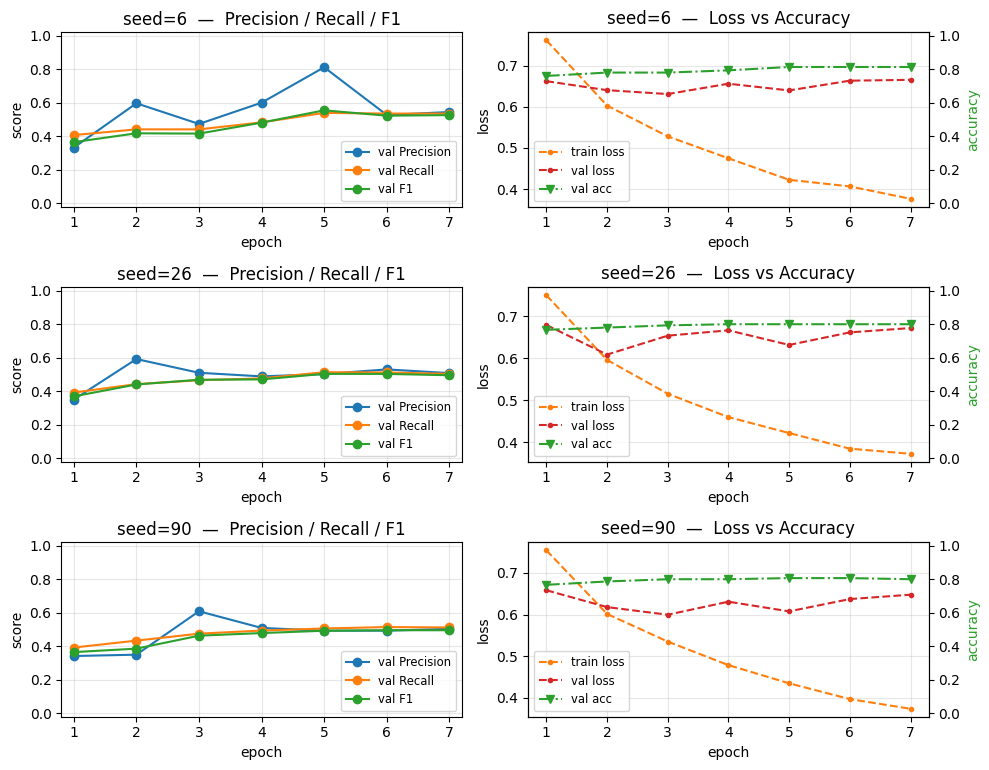

In [ ]:
plot_metrics_by_seed(logs_partial)

---   Results for Partial Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 6
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
0,6,0.554849,0.811607,0.539700,0.813333,5.0
1,26,0.504021,0.502728,0.513794,0.800000,5.0
2,90,0.495833,0.493134,0.514700,0.806667,6.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
0,6,0.496730,0.581493,0.502138,0.760714,5.0
1,26,0.472387,0.452638,0.497168,0.746429,5.0
2,90,0.466985,0.450533,0.485263,0.742857,6.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.518234,0.602490,0.522731,0.806667,0.478701,0.494888,0.494856,0.750000
std,0.031972,0.181164,0.014702,0.006667,0.015846,0.075009,0.008671,0.009449


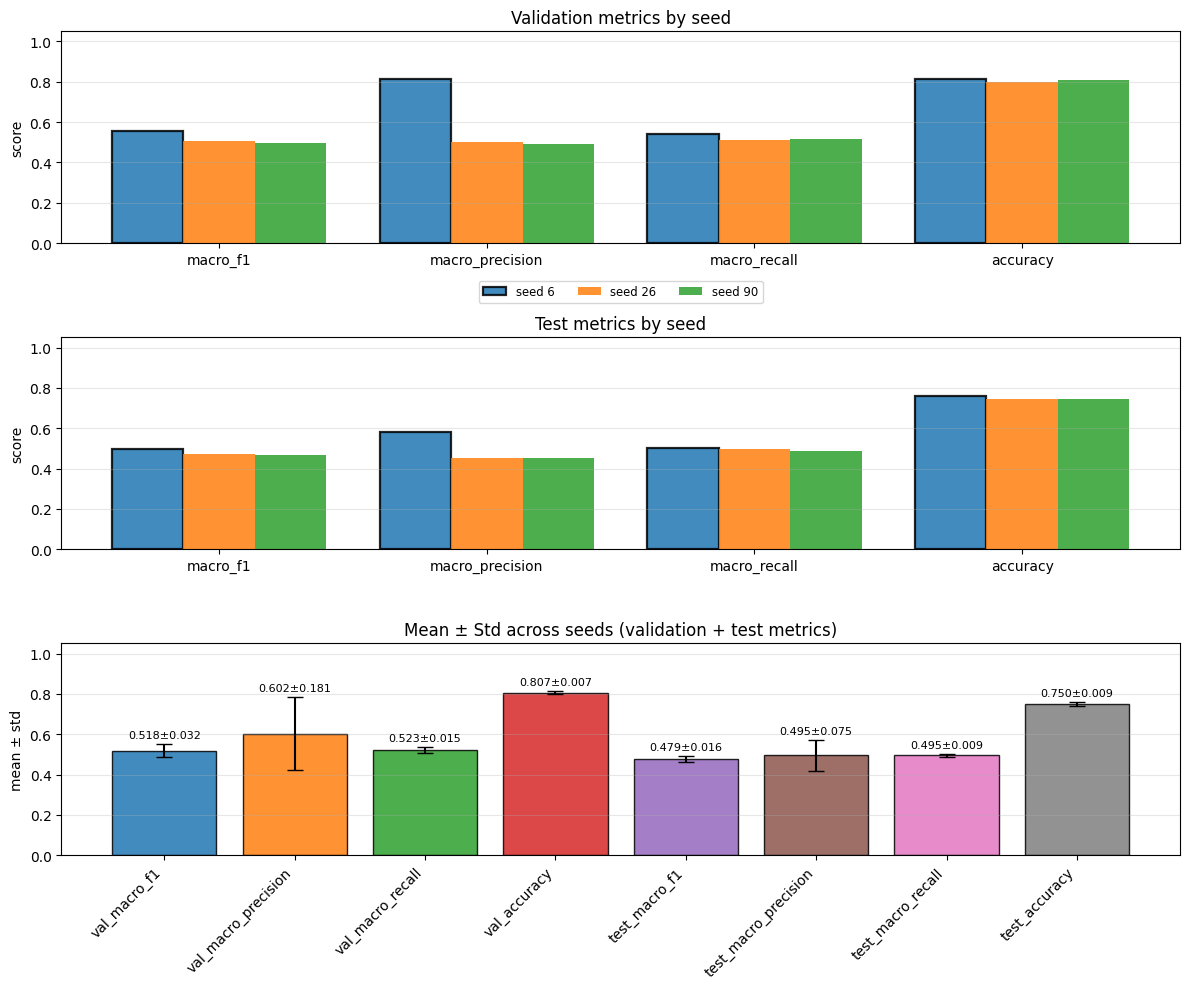

In [ ]:
agg_partial, best_run_partial, best_seed_partial = print_outputs_and_hystograms(df_out_partial, name_model="Partial")

We can notice two aspects:
- The partial fine-tuning shows performance drop from validation (0.518 F1) to test (0.479 F1), combined with extreme instability in validation precision (std = 0.181).  
- Training loss continuously decreases across all seeds, but validation loss oscillates and overall stagnates. 
This could suggests the frozen encoder provides insufficient representational capacity, forcing the classifier head to memorize specific patterns rather than learning robust decision boundaries.  

So we tried full fine-tuning, that should allow the entire model to adapt its representations to this specific task, potentially learning more generalizable features that transfer better to unseen data.

### Complete Fine-tuning

In [ ]:
results, logs, best_model_dirs = train_evaluate_model(
    seeds=seeds,
    dataset=dataset,
    hyperparameters=hyper,
    output_dir=output_dir,
    fine_tune_partially=False,
    early_patience=2,
    VERBOSE=True,
    best_subdir_name="best_model"
)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

=== Model Summary ===
RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.745700,0.649624,0.369715,0.348214,0.395031,0.773333
2,0.587600,0.598009,0.464579,0.606953,0.486284,0.806667
3,0.507500,0.592146,0.483212,0.514460,0.496247,0.806667
4,0.442200,0.654254,0.474068,0.488943,0.485378,0.800000
5,0.391900,0.623028,0.539939,0.541667,0.547878,0.820000
6,0.349800,0.684789,0.516572,0.523784,0.524664,0.806667
7,0.323000,0.698245,0.496629,0.524746,0.503830,0.800000



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.742900,0.664702,0.361183,0.344993,0.381781,0.760000
2,0.584300,0.586287,0.479595,0.494177,0.484472,0.793333
3,0.491500,0.680081,0.427014,0.429447,0.434317,0.780000
4,0.427000,0.677045,0.475572,0.472733,0.484472,0.793333



=== RUN seed=6 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.753800,0.648385,0.383687,0.347902,0.431366,0.780000
2,0.591400,0.627966,0.450784,0.595072,0.468271,0.780000
3,0.502800,0.651552,0.442197,0.510367,0.459783,0.780000
4,0.440500,0.695132,0.469845,0.501839,0.482997,0.793333
5,0.382400,0.687513,0.500040,0.509001,0.514700,0.806667
6,0.358800,0.719705,0.510620,0.506423,0.524664,0.806667
7,0.325600,0.724775,0.509361,0.506161,0.522283,0.800000


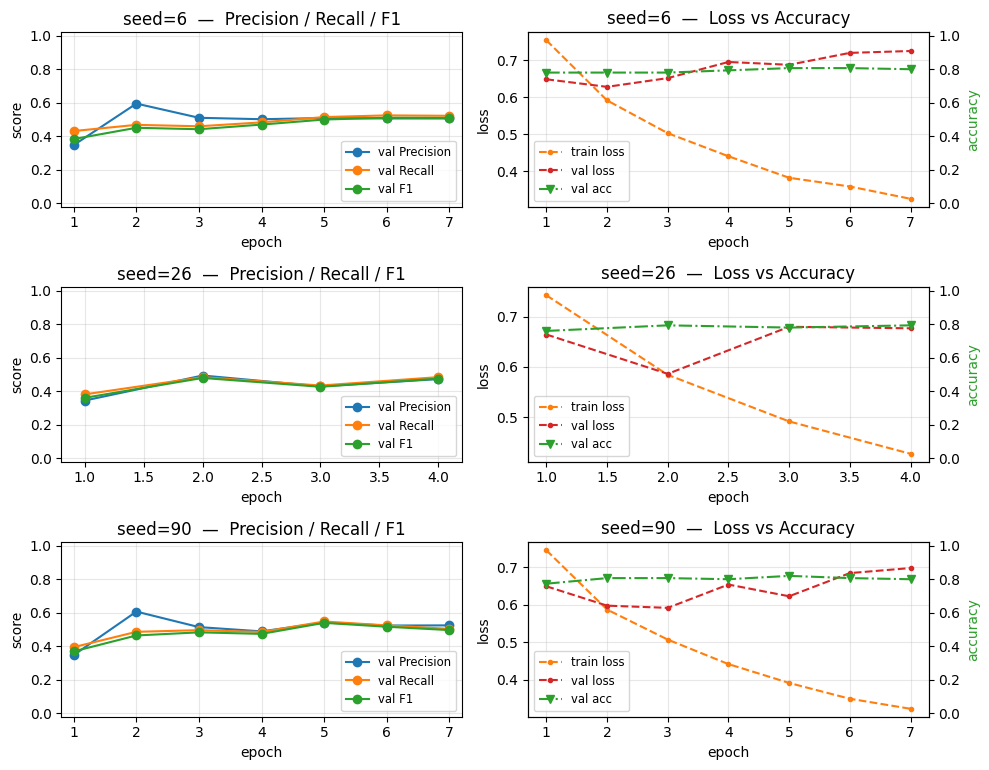

In [ ]:
plot_metrics_by_seed(logs)

---   Results for Full Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 90
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
0,90,0.539939,0.541667,0.547878,0.820000,5.0
1,6,0.510620,0.506423,0.524664,0.806667,6.0
2,26,0.479595,0.494177,0.484472,0.793333,2.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
0,90,0.527533,0.610056,0.539056,0.767857,5.0
1,6,0.490990,0.535304,0.499152,0.746429,6.0
2,26,0.486522,0.497435,0.494027,0.778571,2.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.510051,0.514089,0.519004,0.806667,0.501682,0.547599,0.510745,0.764286
std,0.030176,0.024655,0.032079,0.013333,0.022499,0.057308,0.024652,0.016366


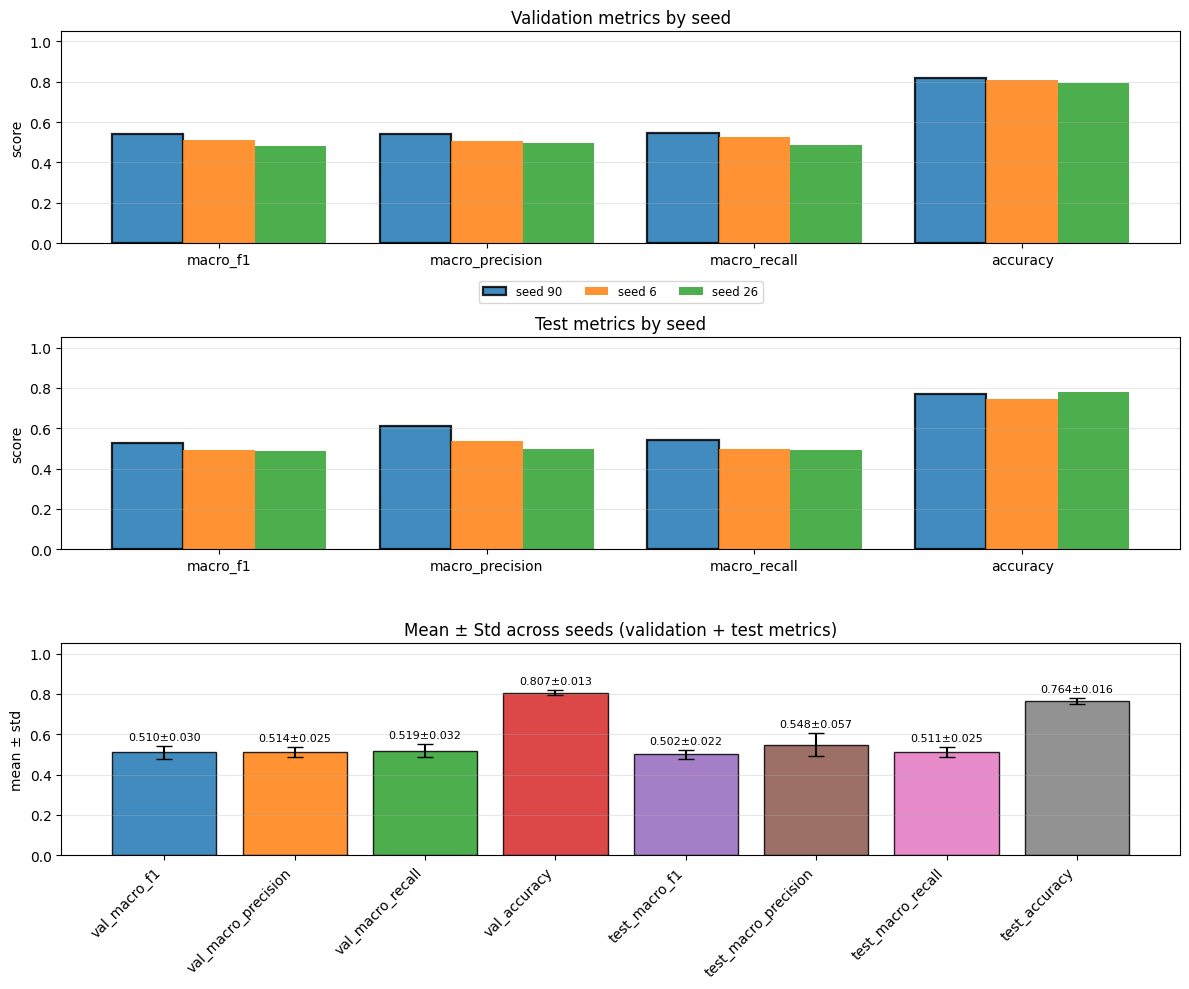

In [ ]:
agg, best_run, best_seed = print_outputs_and_hystograms(df_out, name_model="Full")

---

### Reloading weights of the best model

The best model is the partially fine tuned with seed = 90, with test_macro_f1 = 0.53

In [ ]:
# Reload and saved best model for seed best_seed and evaluate on test set:
best_dir_for_seed = best_model_dirs[best_seed]
# Load best model
model_seed = AutoModelForSequenceClassification.from_pretrained(best_dir_for_seed)
tokenizer = AutoTokenizer.from_pretrained(best_dir_for_seed)
# Move model to device
model_seed.to('cuda' if torch.cuda.is_available() else 'cpu')
# Evaluate on test set
training_args = TrainingArguments(report_to='none')
trainer = Trainer(
    model=model_seed,
    args=training_args,
    eval_dataset=TEST_DATA,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
metrics = trainer.evaluate()
print(58*"-")
print("Best model, according to F1, is the one with the seed =", best_seed)
print(58*"-")
df_temp = pd.DataFrame([metrics]).rename(columns=lambda x: x.replace('eval_', 'test_'))
display(df_temp)

----------------------------------------------------------
Best model, according to F1, is the one with the seed = 90
----------------------------------------------------------


,test_loss,test_model_preparation_time,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,test_runtime,test_samples_per_second,test_steps_per_second
0,0.830444,0.0014,0.527533,0.610056,0.539056,0.767857,0.528,530.328,66.291


# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

## Bidirectional LSTM

### OOV analysis
Let's see the distribution of the OOV tokens and how they influence the classification.

#### Utils

In [ ]:
class OOVAnalyzer:
    """
    Analyze out-of-vocabulary tokens using Keras Tokenizer
    """
    
    def __init__(self, tokenizer):
        """
        Args:
            tokenizer: Keras Tokenizer object with word_index
        """
        self.tokenizer = tokenizer
        self.vocab = set(tokenizer.word_index.keys())
        self.oov_token = tokenizer.oov_token if hasattr(tokenizer, 'oov_token') else None
        
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"OOV token: {self.oov_token}")
    
    def get_tokens(self, text: str) -> List[str]:
        """Get tokens from text (same way tokenizer does it)"""
        # Use tokenizer's text preprocessing
        if hasattr(self.tokenizer, 'filters'):
            import re
            text = text.lower()
            # Apply same filters as tokenizer
            filters = self.tokenizer.filters
            translate_dict = {c: ' ' for c in filters}
            translate_table = str.maketrans(translate_dict)
            text = text.translate(translate_table)
        
        return text.split()
    
    def get_oov_tokens(self, text: str) -> List[str]:
        """Get list of OOV tokens in a text"""
        tokens = self.get_tokens(text)
        return [token for token in tokens if token and token not in self.vocab]
    
    def count_oov(self, text: str) -> int:
        """Count OOV tokens in text"""
        return len(self.get_oov_tokens(text))
    
    def get_oov_rate(self, text: str) -> float:
        """Calculate OOV rate (proportion)"""
        tokens = self.get_tokens(text)
        tokens = [t for t in tokens if t]  # Remove empty strings
        if len(tokens) == 0:
            return 0.0
        return self.count_oov(text) / len(tokens)
    
    def analyze_dataset(self, texts: List[str], labels: np.ndarray, 
                       predictions: np.ndarray = None,
                       class_names: List[str] = None) -> pd.DataFrame:
        """
        Analyze OOV tokens in a dataset
        
        Args:
            texts: List of text strings (or pandas Series - will be converted)
            labels: True labels (can be one-hot or indices)
            predictions: Model predictions (optional, can be one-hot or indices)
            class_names: List of class names for pretty printing
            
        Returns:
            DataFrame with detailed OOV analysis
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
        
        # Convert one-hot to indices if needed
        if len(labels.shape) > 1:
            labels = np.argmax(labels, axis=-1)
        
        if predictions is not None and len(predictions.shape) > 1:
            predictions = np.argmax(predictions, axis=-1)
        
        results = []
        
        for i, text in enumerate(texts):
            tokens = self.get_tokens(text)
            tokens = [t for t in tokens if t]  # Remove empty
            oov_tokens = self.get_oov_tokens(text)
            
            result = {
                'text': text,
                'true_label': labels[i],
                'total_tokens': len(tokens),
                'oov_count': len(oov_tokens),
                'oov_rate': len(oov_tokens) / len(tokens) if len(tokens) > 0 else 0,
                'oov_tokens': oov_tokens
            }
            
            if predictions is not None:
                result['prediction'] = predictions[i]
                result['correct'] = labels[i] == predictions[i]
            
            if class_names is not None:
                result['true_label_name'] = class_names[labels[i]]
                if predictions is not None:
                    result['prediction_name'] = class_names[predictions[i]]
            
            results.append(result)
        
        return pd.DataFrame(results)
    
    def get_summary_by_prediction(self, texts: List[str], labels: np.ndarray,
                                  predictions: np.ndarray,
                                  class_names: List[str] = None) -> pd.DataFrame:
        """
        Get OOV summary statistics grouped by prediction class
        
        Args:
            texts: List of text strings (or pandas Series - will be converted)
            labels: True labels
            predictions: Model predictions
            class_names: Optional class names
            
        Returns:
            DataFrame with summary statistics per prediction class
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
        
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        
        group_col = 'prediction_name' if 'prediction_name' in df.columns else 'prediction'
        
        summary = df.groupby(group_col).agg({
            'oov_count': ['mean', 'median', 'sum', 'std'],
            'oov_rate': ['mean', 'median', 'std'],
            'total_tokens': ['mean', 'sum'],
            'text': 'count'
        }).round(4)
        
        summary.columns = ['avg_oov_count', 'median_oov_count', 'total_oov', 'std_oov_count',
                          'avg_oov_rate', 'median_oov_rate', 'std_oov_rate',
                          'avg_tokens', 'total_tokens', 'num_samples']
        
        return summary.reset_index()
    
    def get_summary_by_correctness(self, texts: List[str], labels: np.ndarray,
                                   predictions: np.ndarray) -> pd.DataFrame:
        """
        Compare OOV rates between correct and incorrect predictions
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        df = self.analyze_dataset(texts, labels, predictions)
        
        summary = df.groupby('correct').agg({
            'oov_count': ['mean', 'median', 'std'],
            'oov_rate': ['mean', 'median', 'std'],
            'text': 'count'
        }).round(4)
        
        summary.columns = ['avg_oov_count', 'median_oov_count', 'std_oov_count',
                          'avg_oov_rate', 'median_oov_rate', 'std_oov_rate',
                          'num_samples']
        
        summary.index = ['Incorrect', 'Correct']
        return summary.reset_index()
    
    def get_most_common_oov(self, texts: List[str], labels: np.ndarray,
                           predictions: np.ndarray,
                           class_names: List[str] = None,
                           top_n: int = 20) -> Dict:
        """
        Get most common OOV tokens per prediction class
        
        Returns:
            Dictionary with OOV token frequencies per class
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        
        group_col = 'prediction_name' if 'prediction_name' in df.columns else 'prediction'
        
        oov_by_class = {}
        
        for class_val in df[group_col].unique():
            class_df = df[df[group_col] == class_val]
            all_oov = []
            for oov_list in class_df['oov_tokens']:
                all_oov.extend(oov_list)
            
            oov_by_class[class_val] = Counter(all_oov).most_common(top_n)
        
        return oov_by_class
    
    def print_oov_report(self, texts: List[str], labels: np.ndarray,
                        predictions: np.ndarray, class_names: List[str] = None):
        """
        Print a comprehensive OOV analysis report
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        print("\n" + "="*80)
        print("OOV ANALYSIS REPORT")
        print("="*80)
        
        # Overall statistics
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        print(f"\nOverall Statistics:")
        print(f"  Total samples: {len(df)}")
        print(f"  Avg OOV tokens per sample: {df['oov_count'].mean():.2f}")
        print(f"  Median OOV tokens: {df['oov_count'].median():.2f}")
        print(f"  Avg OOV rate: {df['oov_rate'].mean():.2%}")
        print(f"  Samples with 0 OOV: {(df['oov_count'] == 0).sum()} ({(df['oov_count'] == 0).mean():.1%})")
        
        # By prediction class
        #print("\n" + "-"*80)
        #print("OOV Statistics by Prediction Class:")
        #print("-"*80)
        #summary = self.get_summary_by_prediction(texts, labels, predictions, class_names)
        #print(summary.to_string(index=False))
        
        # Correct vs Incorrect
        print("\n" + "-"*80)
        print("OOV Statistics: Correct vs Incorrect Predictions:")
        print("-"*80)
        correctness = self.get_summary_by_correctness(texts, labels, predictions)
        print(correctness.to_string(index=False))
        
        print("\n" + "="*80)

def pred_with_best(models, model, best_run, tok, dir='./'):

    best_seed=int(best_run['seed'])
    current_model = models[model](seed=best_seed, tokenizer=tokenizer)
    current_model.load_weights(f'{dir}/weights_{model}_seed{best_seed}.weights.h5')
    y_pred_probs=current_model.predict(X_test_padded)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    return y_pred

def plot_conf_matrix(models, model, best_run, tok, dir='./', tot=False):
    best_seed=int(best_run['seed'])
    current_model = models[model](seed=best_seed, tokenizer=tok)
    current_model.load_weights(f'{dir}/weights_{model}_seed{best_seed}.weights.h5') 

    y_pred_probs = current_model.predict(X_test_padded, verbose=0)
    y_test_pred = np.argmax(y_pred_probs, axis=-1)   
    # Convert one-hot to class indices if needed
    if len(y_test_cat.shape) > 1:
        y_test_true = np.argmax(y_test_cat, axis=-1)
    else:
        y_test_true = y_test_cat
    
    label_names=['-', 'DIRECT', 'JUDGEMENTAL','REPORTED']
    test_cm= confusion_matrix(y_test_true, y_test_pred)
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Test Confusion Matrix for {model} model')
    plt.tight_layout()
    plt.show() 

In [ ]:
# Create analyzer
analyzer = OOVAnalyzer(tokenizer)

y_pred=pred_with_best(models, 'baseline', best_run_base, tokenizer, dir='./weights/base')

# Get detailed analysis
print("\nDetailed Analysis:")
# Print full report
analyzer.print_oov_report(test_df['cleaned_lemm_tweet'], test_df['label'], y_pred, ['-', 'DIRECT', 'JUDGEMENTAL','REPORTED'])

Vocabulary size: 9145
OOV token: <OOV>
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Detailed Analysis:

OOV ANALYSIS REPORT

Overall Statistics:
  Total samples: 280
  Avg OOV tokens per sample: 2.00
  Median OOV tokens: 1.00
  Avg OOV rate: 7.73%
  Samples with 0 OOV: 71 (25.4%)

--------------------------------------------------------------------------------
OOV Statistics: Correct vs Incorrect Predictions:
--------------------------------------------------------------------------------
    index  avg_oov_count  median_oov_count  std_oov_count  avg_oov_rate  median_oov_rate  std_oov_rate  num_samples
Incorrect         1.7255               1.0         1.8940        0.0569           0.0445        0.0592          102
  Correct         2.1573               2.0         2.0933        0.0890           0.0706        0.1090          178



In [ ]:
# Create analyzer
analyzer = OOVAnalyzer(tokenizer)

y_pred=pred_with_best(models, 'stacked', best_run_base, tokenizer, dir='./weights/base')

# Get detailed analysis
print("\nDetailed Analysis:")
# Print full report
analyzer.print_oov_report(test_df['cleaned_lemm_tweet'], test_df['label'], y_pred, ['-', 'DIRECT', 'JUDGEMENTAL','REPORTED'])

Vocabulary size: 9145
OOV token: <OOV>
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step

Detailed Analysis:

OOV ANALYSIS REPORT

Overall Statistics:
  Total samples: 280
  Avg OOV tokens per sample: 2.00
  Median OOV tokens: 1.00
  Avg OOV rate: 7.73%
  Samples with 0 OOV: 71 (25.4%)

--------------------------------------------------------------------------------
OOV Statistics: Correct vs Incorrect Predictions:
--------------------------------------------------------------------------------
    index  avg_oov_count  median_oov_count  std_oov_count  avg_oov_rate  median_oov_rate  std_oov_rate  num_samples
Incorrect         1.5536               1.0         1.6917        0.0531           0.0471        0.0524          112
  Correct         2.2976               2.0         2.1820        0.0935           0.0714        0.1124          168



### Imbalance analysis

As we have seen the dataset is strongly unbalanced towards the catefory of non-sexism ('-'), let's see what happens when a weight dictionary is not used.

In [ ]:
load_weights=load_LSTM

# Run this
if not load_weights: # Only clear memory if we are actually going to train
    clear_all_memory()

histories_no, results_no, f1_voc_no = train_and_eval_seeds(models, X_train_padded, y_train_cat, 
                                                  X_val_padded,y_val_cat, class_weight_dict=None, tok=tokenizer,
                                                  dir='./weights/no_class_dict', load_weights=load_weights, patience=5)


SEED: 90

Training: baseline (seed=90)

Model Architecture:


Model: "baseline_bidirectional_lstm_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,696 (1.97 MB)

 Trainable params: 516,696 (1.97 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,656 (2.13 MB)

 Trainable params: 557,656 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6546 - loss: 1.1985
  - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.6920 - loss: 1.0422 - val_accuracy: 0.7000 - val_loss: 0.9242 - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500 - val_accuracy_sklearn: 0.7000
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6982 - loss: 0.8989
  - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.7010 - loss: 0.8855 - val_accuracy: 0.7000 - val_loss: 0.9297 - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500 - val_accuracy_sklearn: 0.7000
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6982 - loss: 0.8952
  - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.7010 - loss: 0.8824 - val_accuracy: 0.7000 - val_loss: 0.9285 - val_f1: 


Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 26
  Model: baseline
  Model: stacked

Plotting seed: 6
  Model: baseline
  Model: stacked


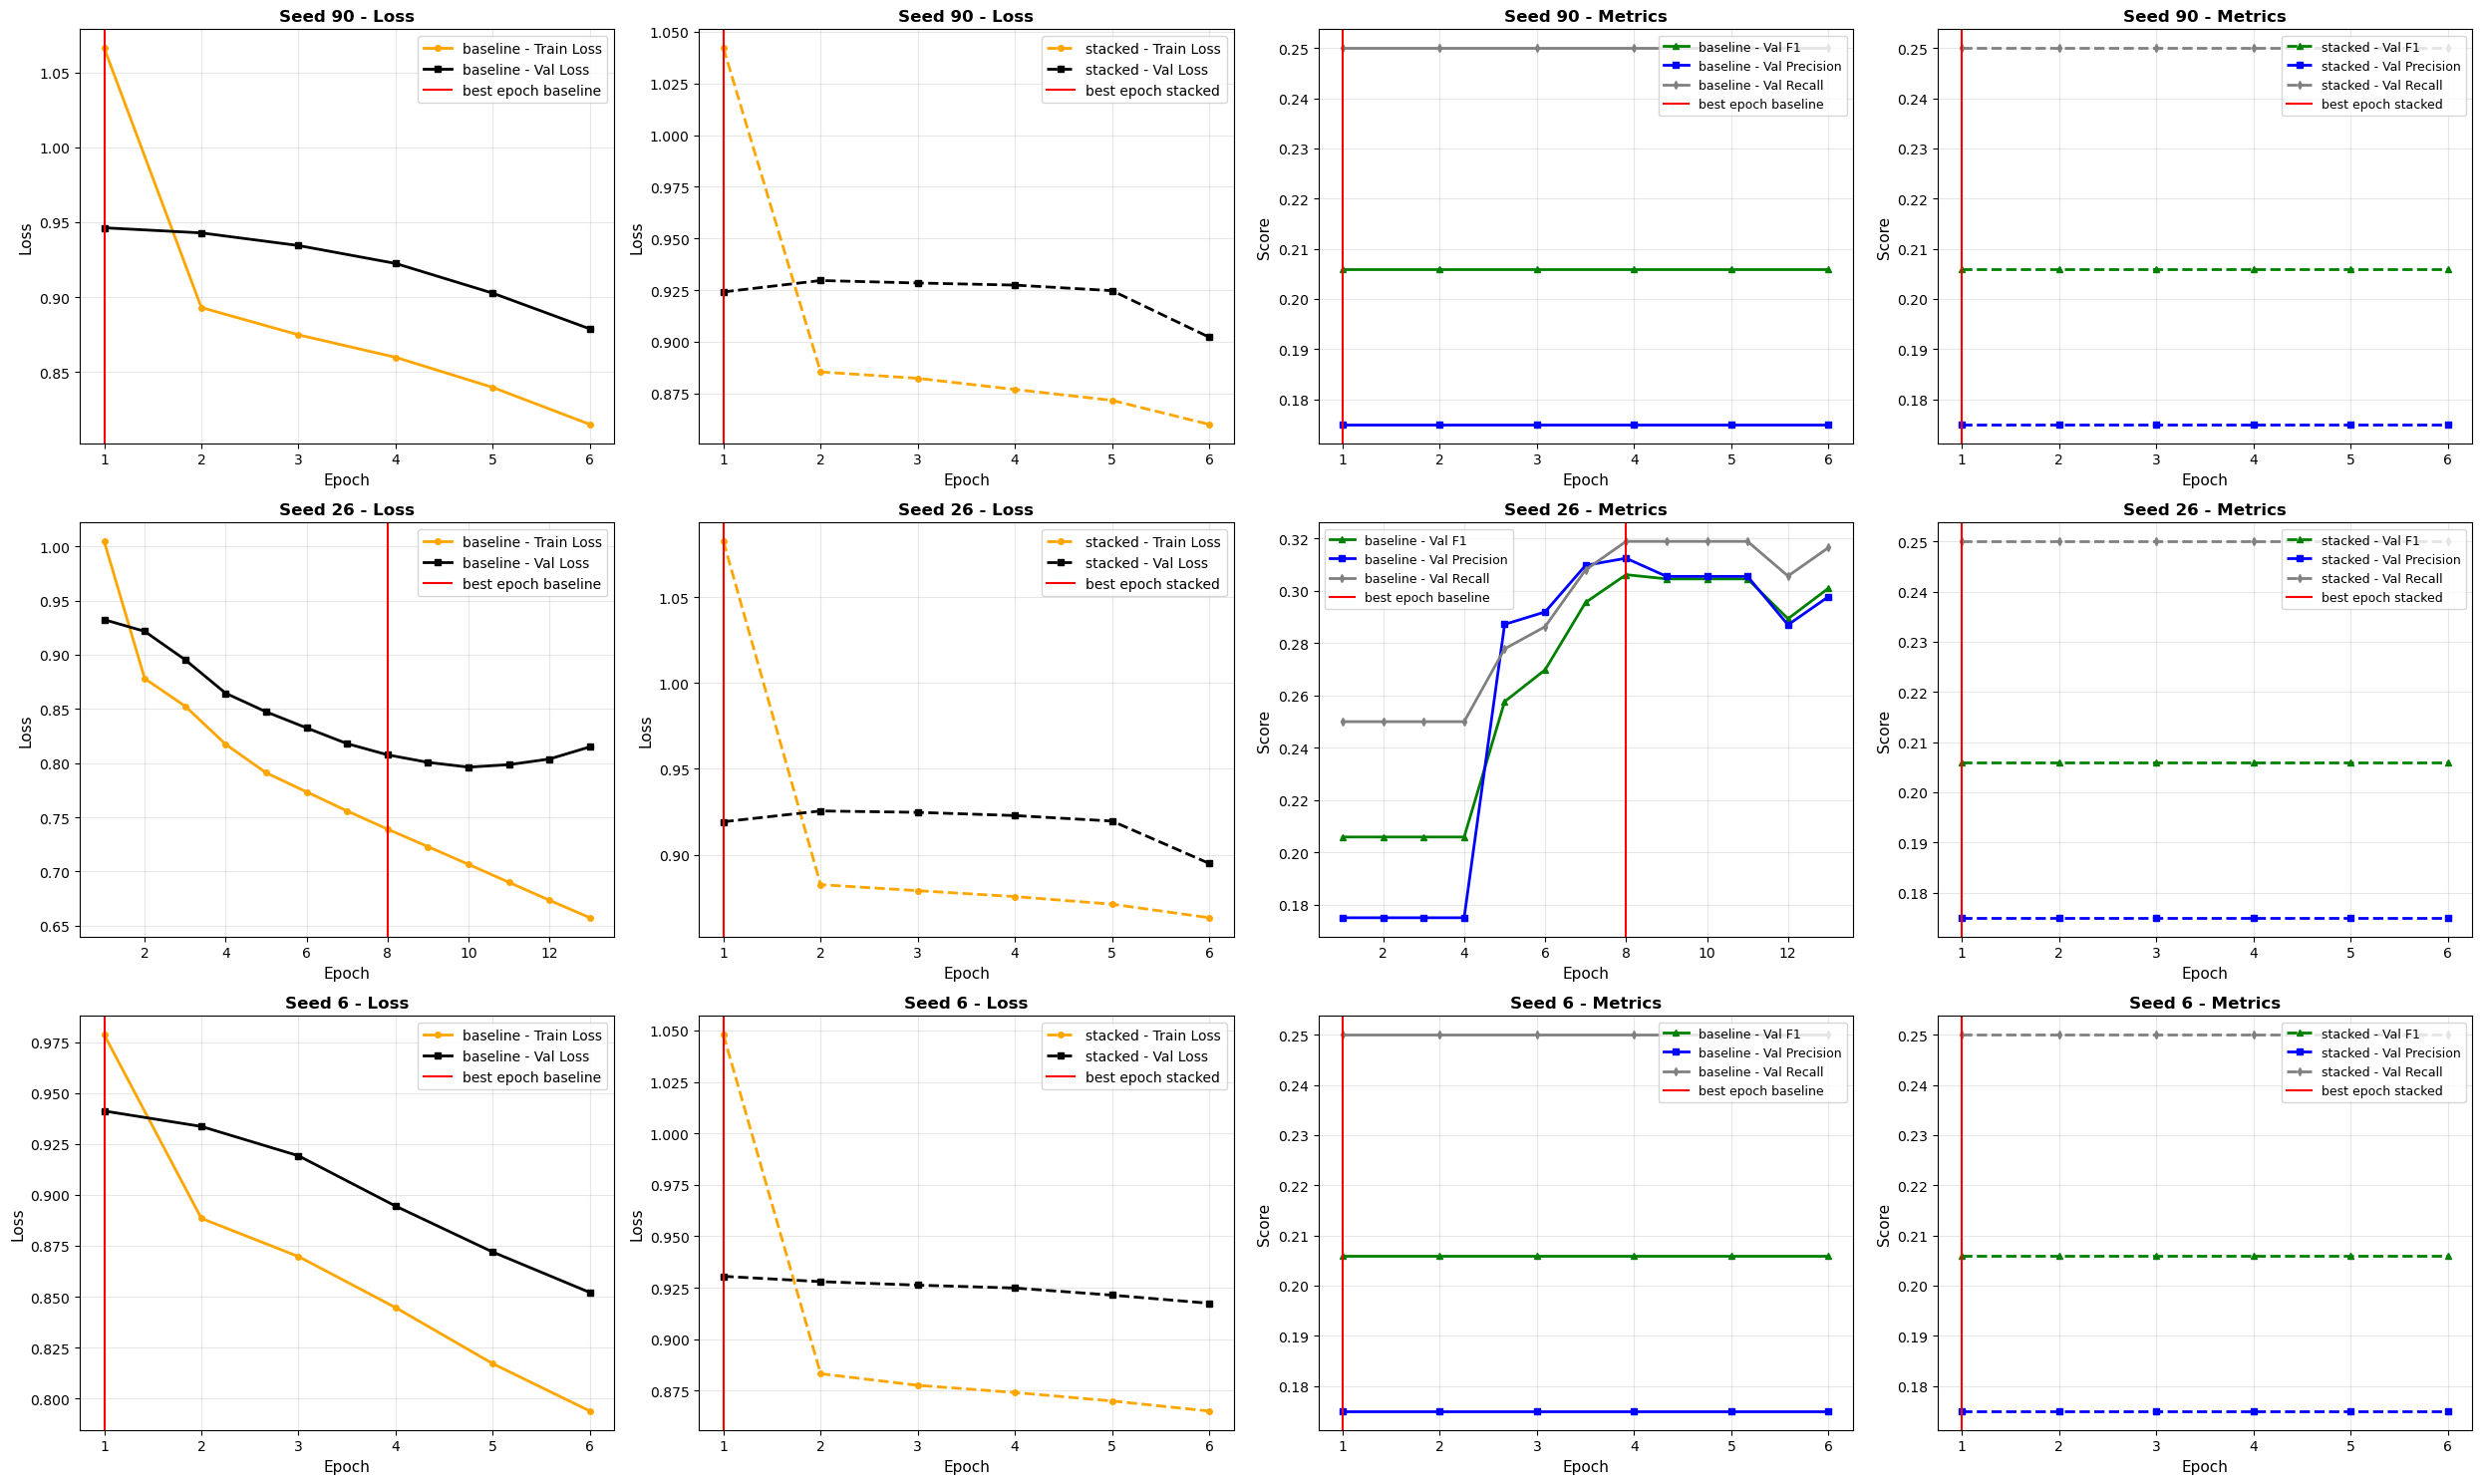

In [ ]:
plot_training_history(histories_no)

/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

logs dumped


/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.205882,0.1750,0.250000,0.700000,0.194989,0.159821,0.250000,0.639286,90
1,0.306213,0.3125,0.318944,0.726667,0.282578,0.285291,0.301946,0.664286,26
2,0.205882,0.1750,0.250000,0.700000,0.194989,0.159821,0.250000,0.639286,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.239326,0.224185,0.220833,0.201645,0.272981,0.267315,0.708889,0.647619
std,0.057926,0.050570,0.079386,0.072440,0.039805,0.029991,0.015396,0.014434


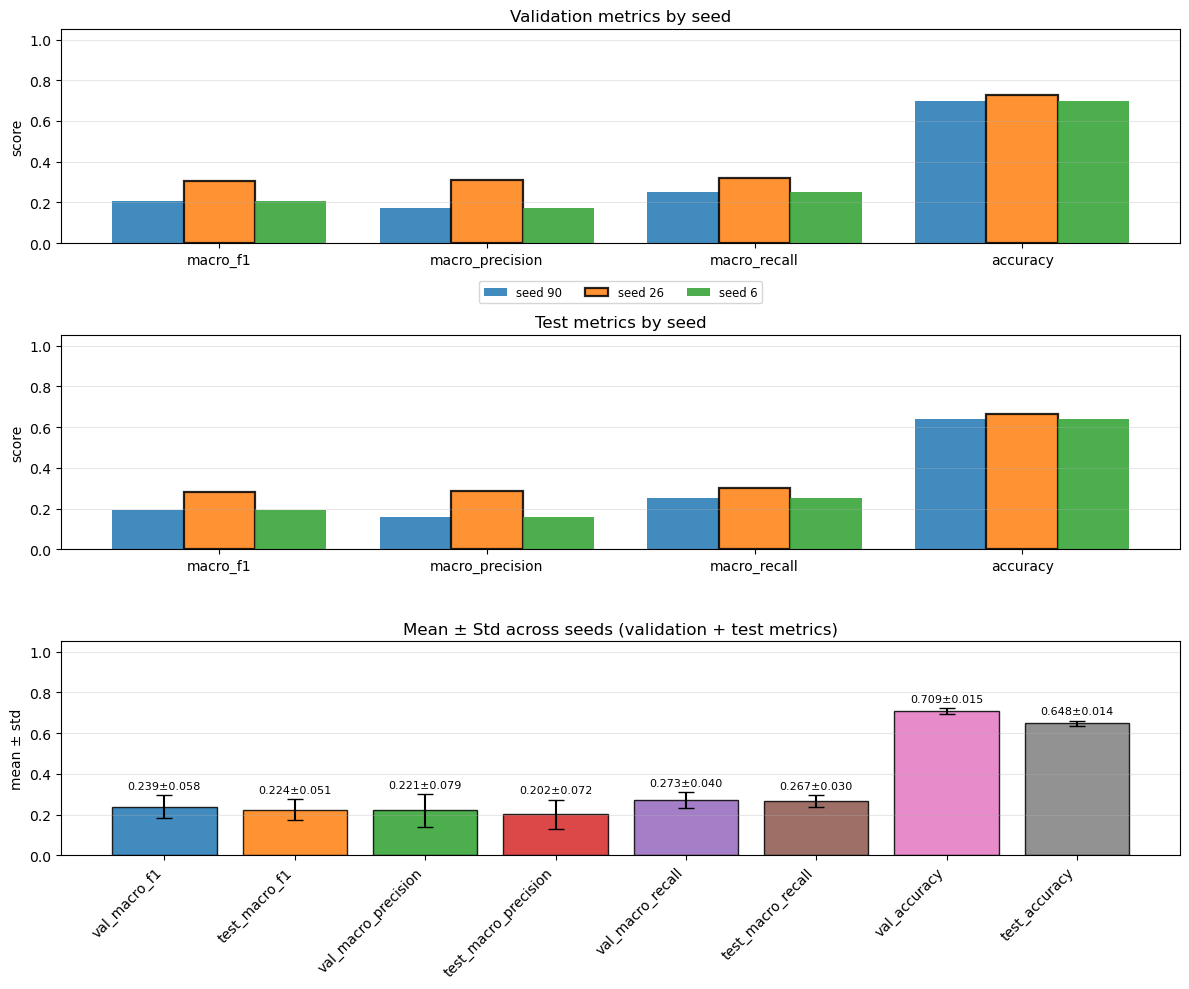

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.205882,0.175,0.25,0.7,0.194989,0.159821,0.25,0.639286,90
1,0.205882,0.175,0.25,0.7,0.194989,0.159821,0.25,0.639286,26
2,0.205882,0.175,0.25,0.7,0.194989,0.159821,0.25,0.639286,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,2.058824e-01,0.194989,1.750000e-01,0.159821,0.25,0.25,7.000000e-01,0.639286
std,3.399350e-17,0.000000,3.399350e-17,0.000000,0.00,0.00,1.359740e-16,0.000000


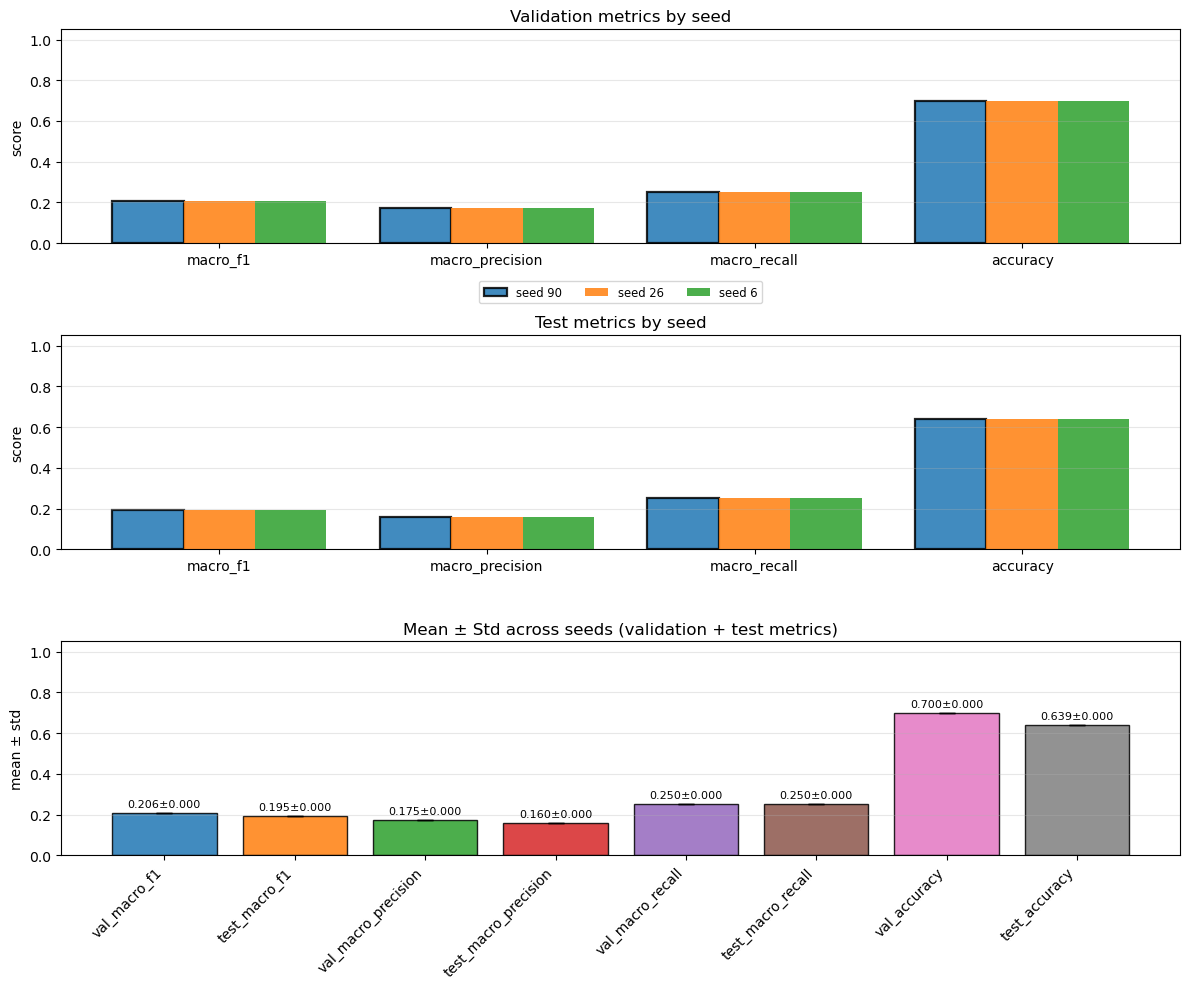

In [ ]:
load=load_LSTM

# load the logs for both the models trained previously
logs_base_no,logs_stacked_no=evaluation(models, X_val_padded, y_val_cat, X_test_padded, 
                                        y_test_cat,tok=tokenizer,dir='./weights/no_class_dict', load=load)

# show the aggregated results for the baseline model
agg_base_no, best_run_base_no=mean_std(logs_base_no)
display(logs_base_no)
display(agg_base_no)
plot_summary_metrics(logs_base_no, agg_base_no, best_run_base_no)

# show the aggregated results for the stacked model
agg_stacked_no, best_run_stacked_no=mean_std(logs_stacked_no)
display(logs_stacked_no)
display(agg_stacked_no)
plot_summary_metrics(logs_stacked_no, agg_stacked_no, best_run_stacked_no)

The model is worse when trained without `weight_class_dict` as it has lower performances and remains stuck withouth predicting at all some classes as we can see from the following confusion matrix. The stacked model predicts `-` only, which is the most present class. This is an example of why accuracy is not useful here, as the stacked model ha s0.7 accuracy by just predicting one class.

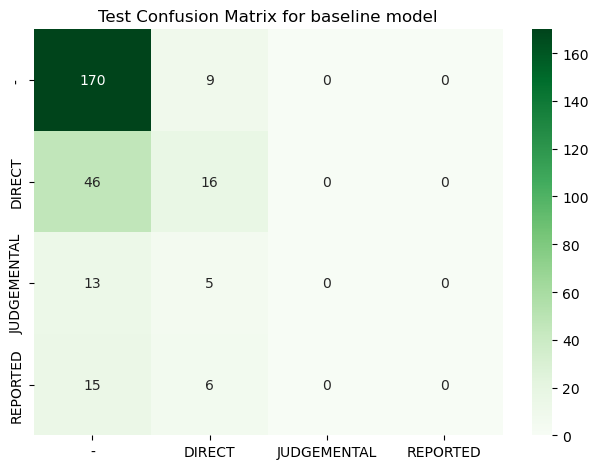

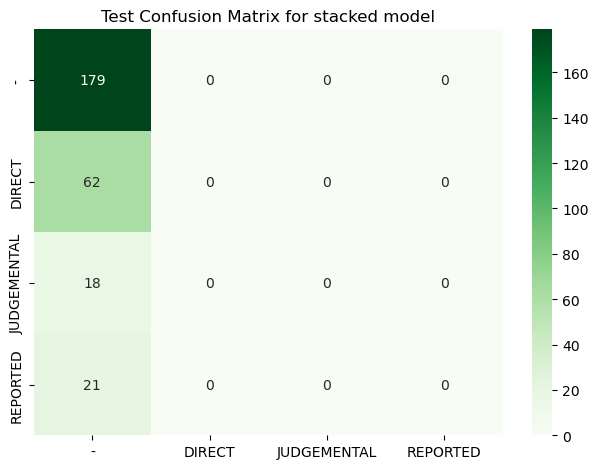

In [ ]:
# plot the matrices
plot_conf_matrix(models,'baseline', best_run_base_no,tok=tokenizer, dir='./weights/no_class_dict')
plot_conf_matrix(models, 'stacked', best_run_stacked_no, tok=tokenizer,dir='./weights/no_class_dict')

## Embedding 

The embedding is done by using just the terms which are present in the tweets. However it was noticed that there are some terms in the test set which are not present in the training set but are present in the GLoVE vocabulary. For this reason, it could be useful to see whether using all the tokenz available in GLoVE in the vocabulary could be useful to improve the quality in the prediction. Let's check first the number of tokens in the test set which are in GLoVe but not in the training corpus

### Utils

In [ ]:
def check_glove_coverage(test_tokens, train_vocab, embedding_model):
    """
    Check how many tokens in the test set are in GLoVe but not in training corpus.
    Also check how many test tokens would be OOV if using GLoVe as vocabulary.
    
    Parameters:
    -----------
    test_tokens : set or list
        Unique tokens from the test set
    train_vocab : set or list
        Vocabulary from the training corpus
    embedding_model : gensim.models.keyedvectors.KeyedVectors
        Loaded embedding model (GLoVe, Word2Vec, or FastText)
    
    Returns:
    --------
    dict
        Dictionary containing:
        - 'in_glove_not_train': set of tokens in GLoVe but not in training
        - 'count': number of such tokens
        - 'oov_tokens': set of test tokens not in GLoVe (would be OOV)
        - 'oov_count': number of OOV tokens
        - 'total_test_tokens': total unique tokens in test set
        - 'coverage_percentage': percentage of test tokens in GLoVe but not in training
        - 'oov_percentage': percentage of test tokens that would be OOV with GLoVe
        - 'glove_coverage_percentage': percentage of test tokens covered by GLoVe
    """
    # Convert to sets for efficient operations
    test_set = set(test_tokens)
    train_set = set(train_vocab)
    # Extract vocabulary from the embedding model
    glove_set = set(embedding_model.key_to_index.keys())
    
    # Find tokens in test set that are in GLoVe but not in training
    in_glove_not_train = test_set.intersection(glove_set).difference(train_set)
    
    # Find tokens in test set that are NOT in GLoVe (OOV if using GLoVe)
    oov_tokens = test_set.difference(glove_set)
    
    # Calculate statistics
    count = len(in_glove_not_train)
    oov_count = len(oov_tokens)
    total_test = len(test_set)
    coverage_pct = (count / total_test * 100) if total_test > 0 else 0
    oov_pct = (oov_count / total_test * 100) if total_test > 0 else 0
    glove_coverage_pct = ((total_test - oov_count) / total_test * 100) if total_test > 0 else 0
    
    return {
        'in_glove_not_train': in_glove_not_train,
        'count': count,
        'oov_tokens': oov_tokens,
        'oov_count': oov_count,
        'total_test_tokens': total_test,
        'coverage_percentage': coverage_pct,
        'oov_percentage': oov_pct,
        'glove_coverage_percentage': glove_coverage_pct
    }

### Check coveragen of the vocabulary

In [ ]:
result = check_glove_coverage(test_words, train_vocab, embedding_model)

print(f"Tokens in GLoVe but not in training: {result['count']}")
print(f"Total test tokens: {result['total_test_tokens']}")
print(f"Coverage: {result['coverage_percentage']:.2f}%")
print(f"\nOOV tokens (not in GLoVe): {result['oov_count']}")
print(f"OOV percentage: {result['oov_percentage']:.2f}%")
print(f"GLoVe coverage: {result['glove_coverage_percentage']:.2f}%")
print(f"\nSample tokens in GLoVe but not in training: {list(result['in_glove_not_train'])[:10]}")
print(f"Sample OOV tokens: {list(result['oov_tokens'])[:10]}")

Tokens in GLoVe but not in training: 433
Total test tokens: 2124
Coverage: 20.39%

OOV tokens (not in GLoVe): 114
OOV percentage: 5.37%
GLoVe coverage: 94.63%

Sample tokens in GLoVe but not in training: ['monya', 'condoms', 'armchair', 'providence', 'bougie', 'ungovernable', 'handmaiden', 'mainstreaming', 'khloe', 'ligation']
Sample OOV tokens: ['eput', 'scouser', 'pomlázka', 'ahri', 'ferosh', 'chavvy', 'talique', 'kneehighs', 'freedomchapter', 'fujo']


Let's rebuild the tokenizer using all the GLoVe embedding, the embedding matrix is not created now as it is present in the model generator.

In [ ]:
load=load_LSTM
tokenizer_tot = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=True,
    oov_token=OOV_TOKEN,
    verbose=True,
    path='./weights/total_voc',
    load=load
)

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

tokenizer dumped
Final vocabulary size: 9146



Retrain the model with the new vocabulary.

In [ ]:
# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer_tot.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer_tot.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer_tot.word_index)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


In [ ]:
load_weights=load_LSTM

# Run this
if not load_weights: # Only clear memory if we are actually going to train
    clear_all_memory()

# Use the function
histories_tot, results_tot, f1_voc_tot = train_and_eval_seeds(models, X_train_padded,
                    y_train_cat, X_val_padded, 
                    y_val_cat, tok=tokenizer_tot, class_weight_dict=class_weight_dict, 
                    dir='./weights/total_voc', load_weights=load_weights)



SEED: 90

Training: baseline (seed=90)

Model Architecture:


Model: "baseline_bidirectional_lstm_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │    20,048,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,107,596 (76.70 MB)

 Trainable params: 20,107,596 (76.70 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │    20,048,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,148,556 (76.86 MB)

 Trainable params: 20,148,556 (76.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.0574 - loss: 1.4157
  - val_f1: 0.1590 - val_precision: 0.2095 - val_recall: 0.2470
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.0595 - loss: 1.3818 - val_accuracy: 0.2667 - val_loss: 1.4035 - val_f1: 0.1590 - val_precision: 0.2095 - val_recall: 0.2470 - val_accuracy_sklearn: 0.2667
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4336 - loss: 1.4028
  - val_f1: 0.2356 - val_precision: 0.2262 - val_recall: 0.2887
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step - accuracy: 0.4434 - loss: 1.3723 - val_accuracy: 0.4867 - val_loss: 1.3992 - val_f1: 0.2356 - val_precision: 0.2262 - val_recall: 0.2887 - val_accuracy_sklearn: 0.4867
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4731 - loss: 1.3896
  - val_f1: 0.1901 - val_precision: 0.2558 - val_recall: 0.2953
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - accuracy: 0.3961 - loss: 1.3616 - val_accuracy: 0.2200 - val_loss: 1.3887 - val_f1: 


Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 26
  Model: baseline
  Model: stacked

Plotting seed: 6
  Model: baseline
  Model: stacked


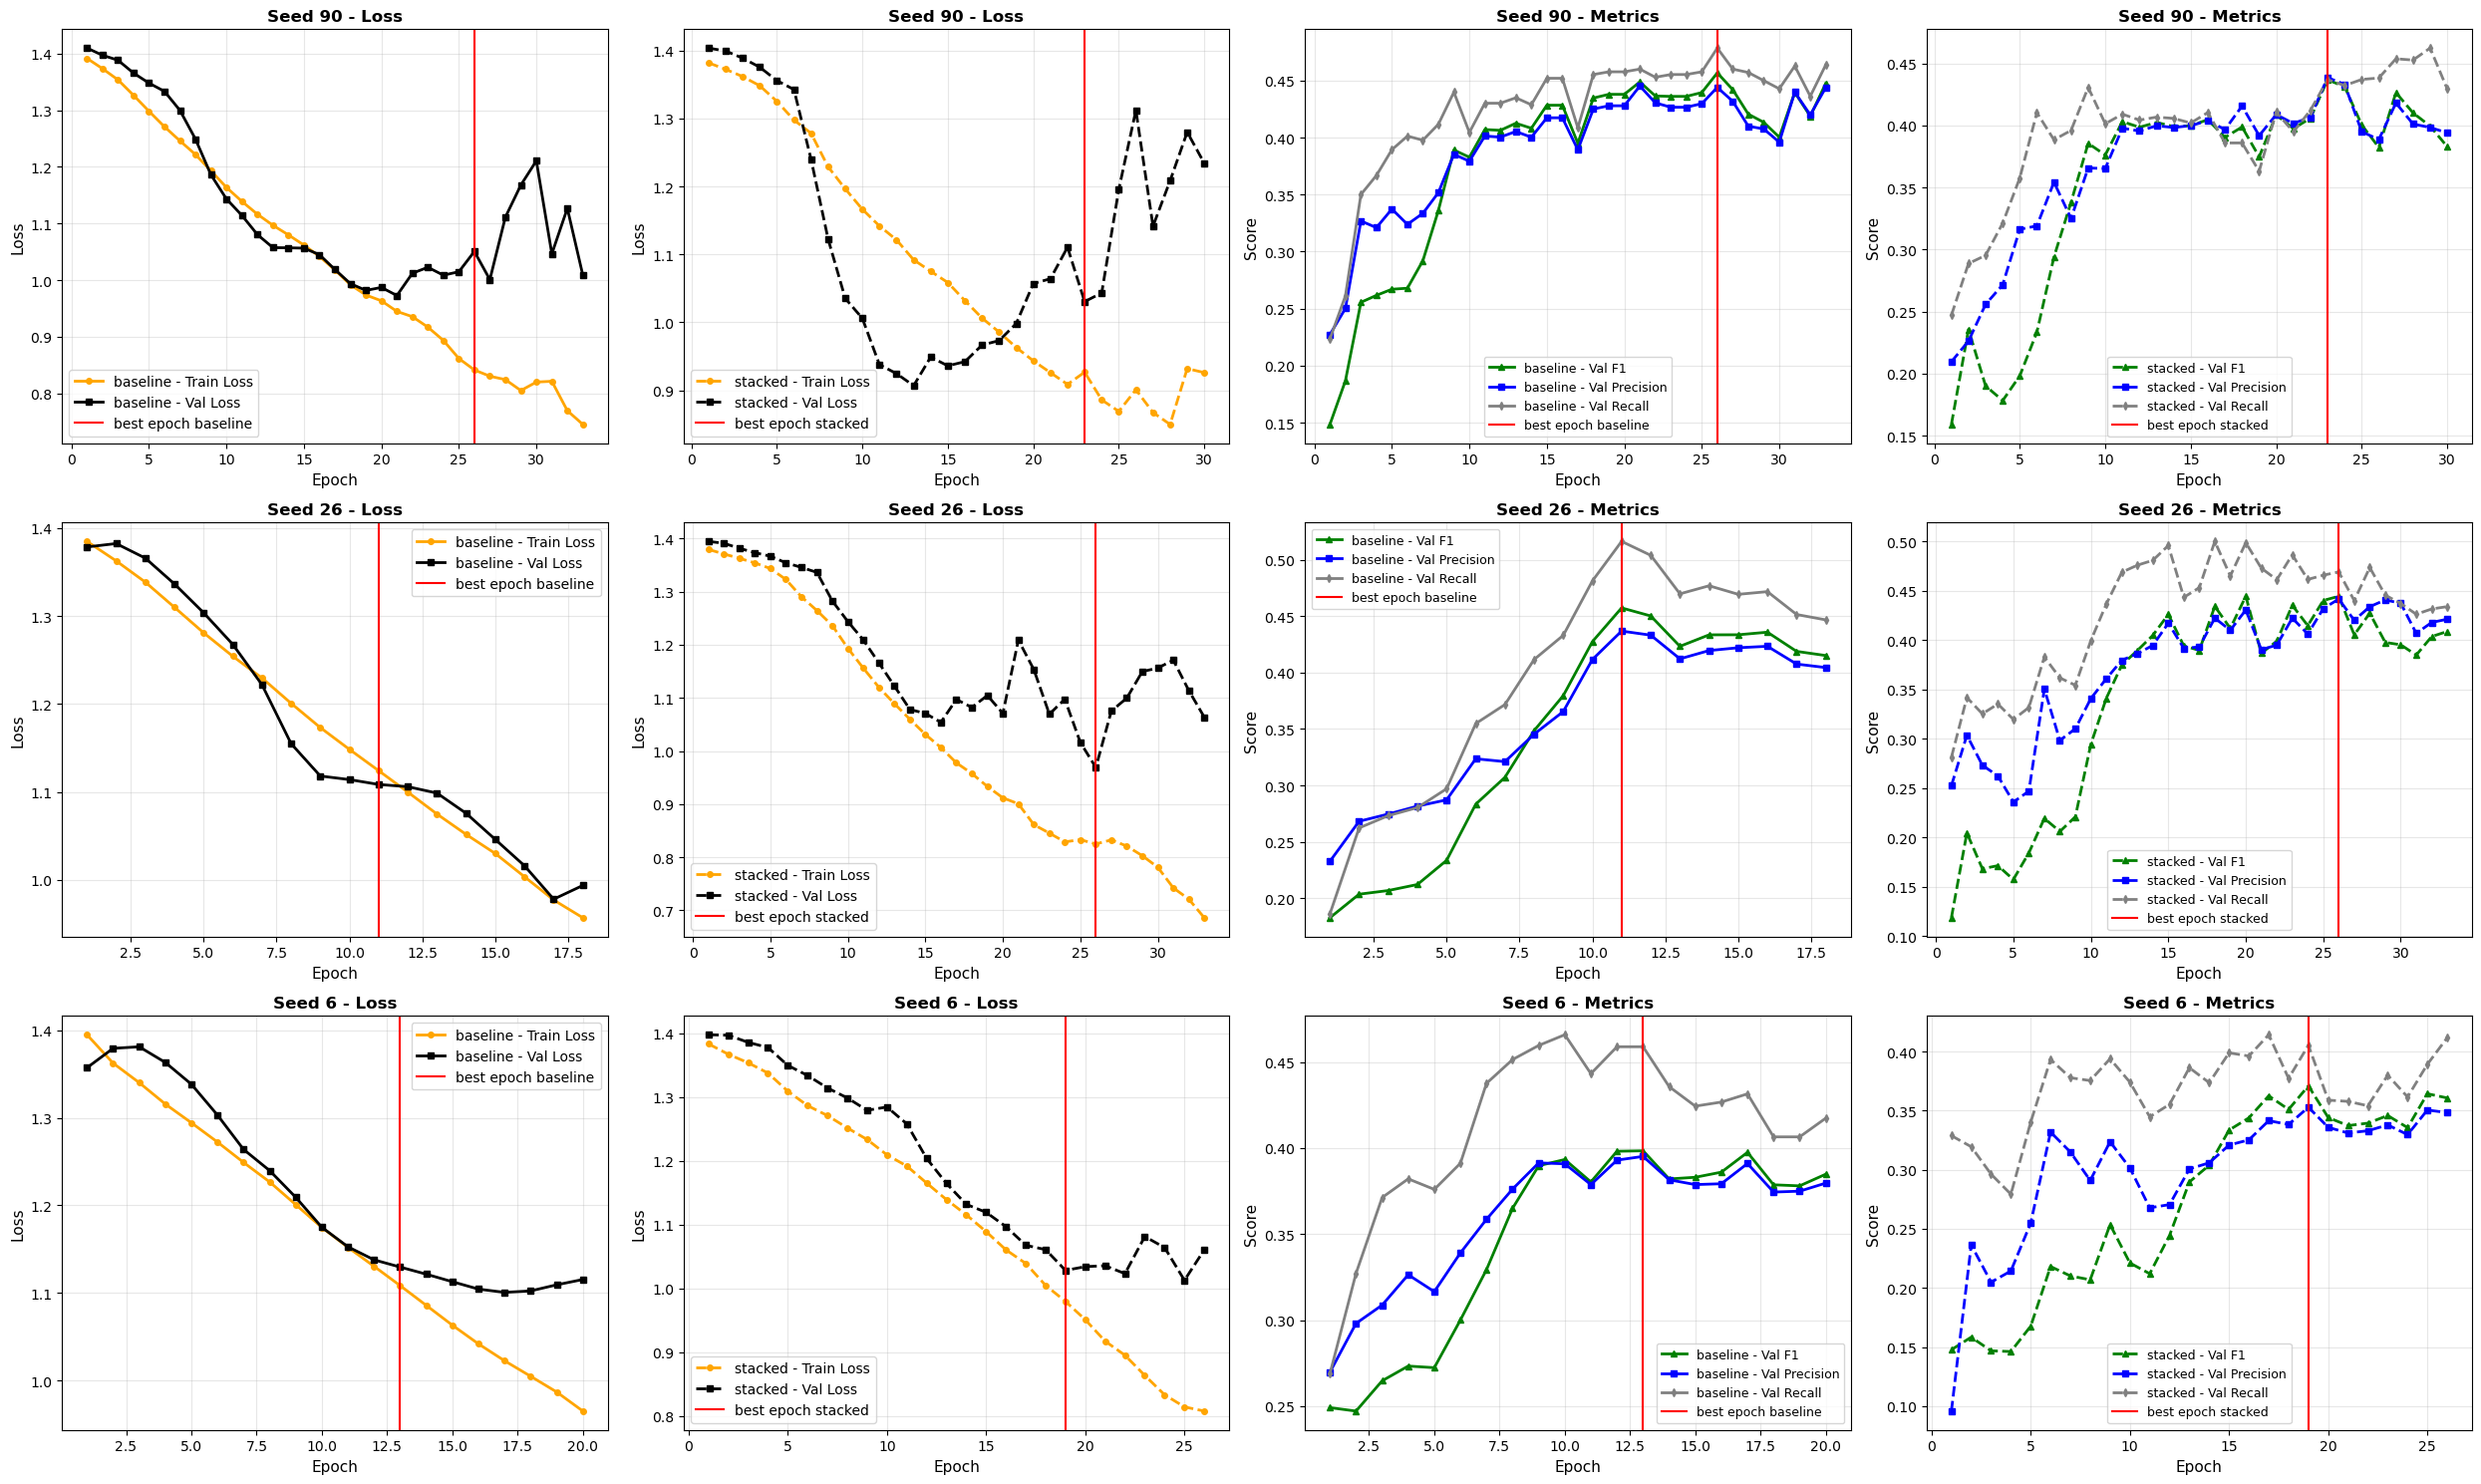

In [ ]:
plot_training_history(histories_tot)

logs dumped


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.456740,0.444025,0.478494,0.653333,0.392360,0.393957,0.426014,0.539286,90
1,0.457249,0.436742,0.516149,0.620000,0.352281,0.368265,0.384497,0.503571,26
2,0.398372,0.395125,0.458851,0.546667,0.361290,0.375246,0.405751,0.485714,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.437454,0.368644,0.425297,0.379156,0.484498,0.405421,0.606667,0.509524
std,0.033846,0.021027,0.026382,0.013285,0.029117,0.020761,0.054569,0.027277


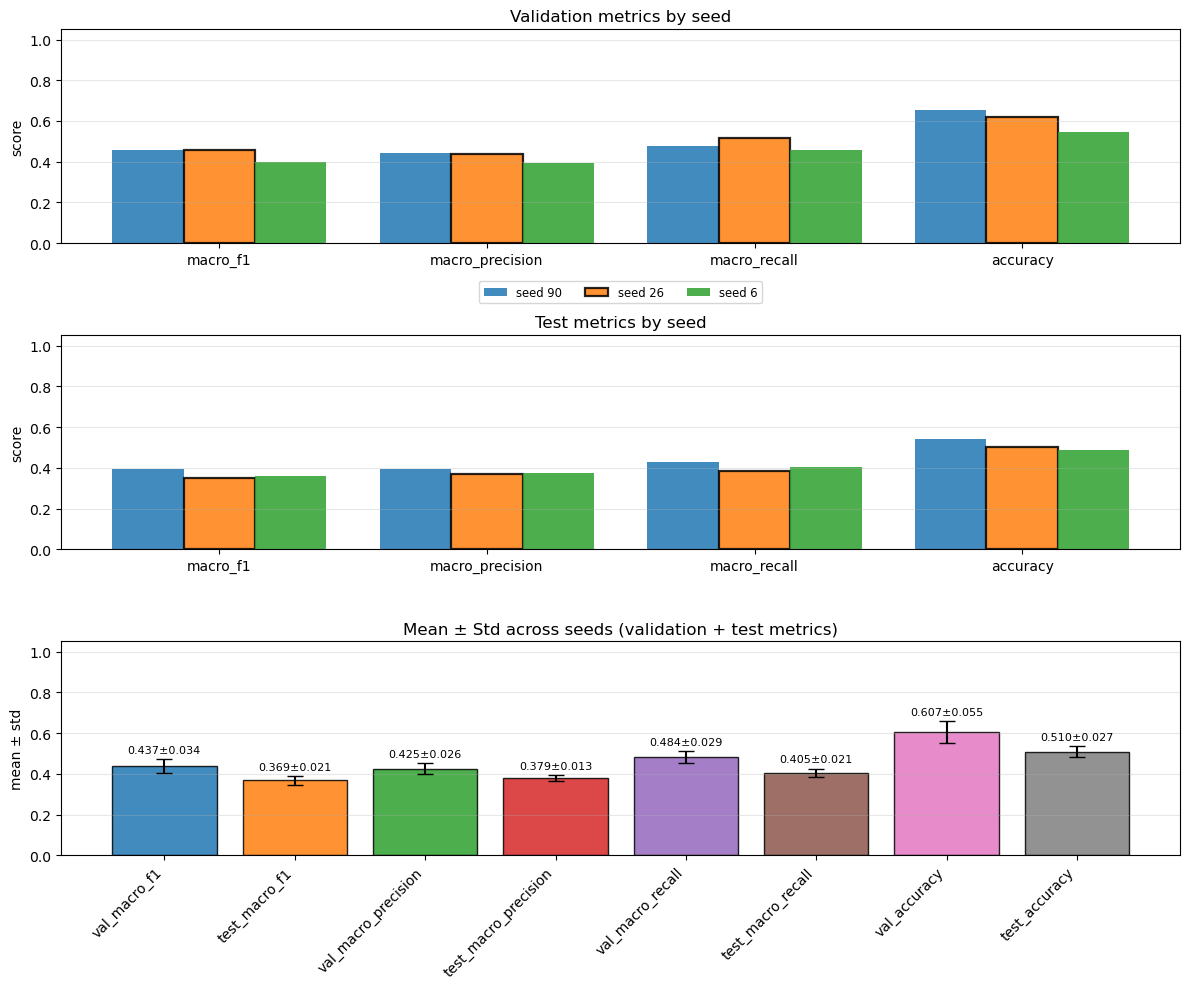

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.436835,0.438623,0.436957,0.660000,0.368347,0.373337,0.382990,0.557143,90
1,0.444208,0.441380,0.468841,0.646667,0.385359,0.381761,0.408601,0.553571,26
2,0.370917,0.352836,0.405254,0.606667,0.428297,0.425600,0.454697,0.614286,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.417320,0.394001,0.410946,0.393566,0.437017,0.415429,0.637778,0.575000
std,0.040355,0.030895,0.050344,0.028060,0.031794,0.036338,0.027756,0.034069


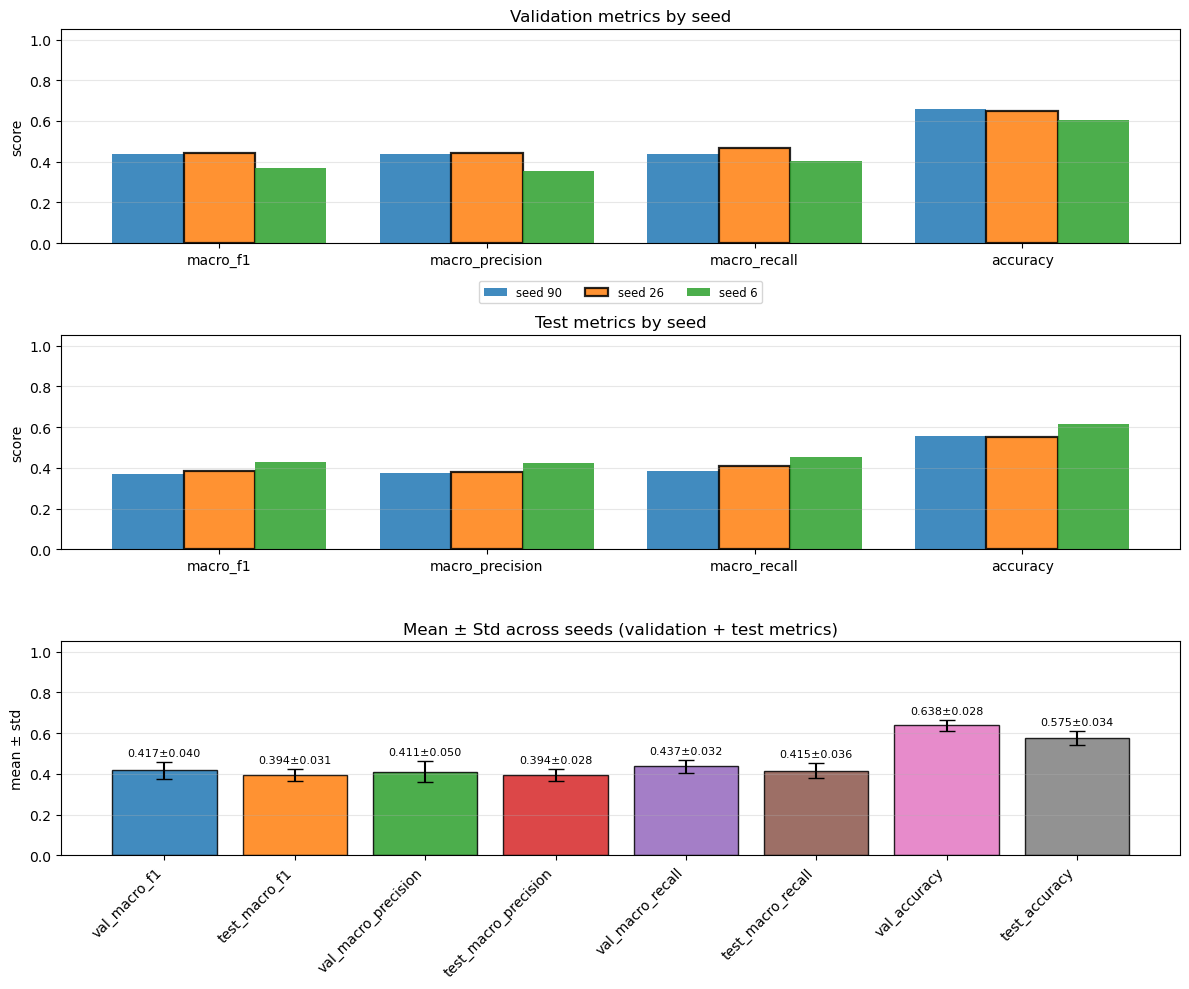

In [ ]:
load=load_LSTM

# load the logs for both the models trained previously
logs_base_tot,logs_stacked_tot=evaluation(models, X_val_padded, y_val_cat, X_test_padded,
                                        y_test_cat, tok=tokenizer_tot,dir='./weights/total_voc', load=load)

# show the aggregated results for the baseline model
agg_base_tot, best_run_base_tot=mean_std(logs_base_tot)
display(logs_base_tot)
display(agg_base_tot)
plot_summary_metrics(logs_base_tot, agg_base_tot, best_run_base_tot)

# show the aggregated results for the stacked model
agg_stacked_tot, best_run_stacked_tot=mean_std(logs_stacked_tot)
display(logs_stacked_tot)
display(agg_stacked_tot)
plot_summary_metrics(logs_stacked_tot, agg_stacked_tot, best_run_stacked_tot)

The model is actually a bit better here however the huge increase in number of parameters (and training time) kleads to discard this option. It also interesting to investigate whether increasing the embedding dimension would improve the predictions' quality, as the increase in the number of parameters would be more moderate here.

### Change embedding dimension

In [ ]:
EMBEDDING_DIMENSION=200

load=load_LSTM

embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

tokenizer_200 = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=False,
    oov_token=OOV_TOKEN,
    verbose=True,
    path='./weights/emb_200',
    load=load
)

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

tokenizer dumped
Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



In [ ]:
# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer_200.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer_200.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer_200.word_index)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


In [ ]:
load_weights=load_LSTM

# Run this
if not load_weights: # Only clear memory if we are actually going to train
    clear_all_memory()

# Use the function
histories_200, results_200, f1_voc_200 = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=class_weight_dict, tok=tokenizer_200,
                                                   dir='./weights/emb_200', load_weights=load_weights)


SEED: 90

Training: baseline (seed=90)

Model Architecture:


Model: "baseline_bidirectional_lstm_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 200)        │     1,829,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,965,396 (7.50 MB)

 Trainable params: 1,965,396 (7.50 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 200)        │     1,829,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,006,356 (7.65 MB)

 Trainable params: 2,006,356 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.0694 - loss: 1.4173
  - val_f1: 0.2320 - val_precision: 0.2240 - val_recall: 0.2726
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.1006 - loss: 1.3821 - val_accuracy: 0.4933 - val_loss: 1.3901 - val_f1: 0.2320 - val_precision: 0.2240 - val_recall: 0.2726 - val_accuracy_sklearn: 0.4933
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5139 - loss: 1.4036
  - val_f1: 0.2297 - val_precision: 0.2180 - val_recall: 0.2613
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.5110 - loss: 1.3708 - val_accuracy: 0.5133 - val_loss: 1.3742 - val_f1: 0.2297 - val_precision: 0.2180 - val_recall: 0.2613 - val_accuracy_sklearn: 0.5133
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4895 - loss: 1.3871
  - val_f1: 0.1680 - val_precision: 0.2946 - val_recall: 0.2852
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.3843 - loss: 1.3561 - val_accuracy: 0.2000 - val_loss: 1.3639 - val_f1: 


Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 26
  Model: baseline
  Model: stacked

Plotting seed: 6
  Model: baseline
  Model: stacked


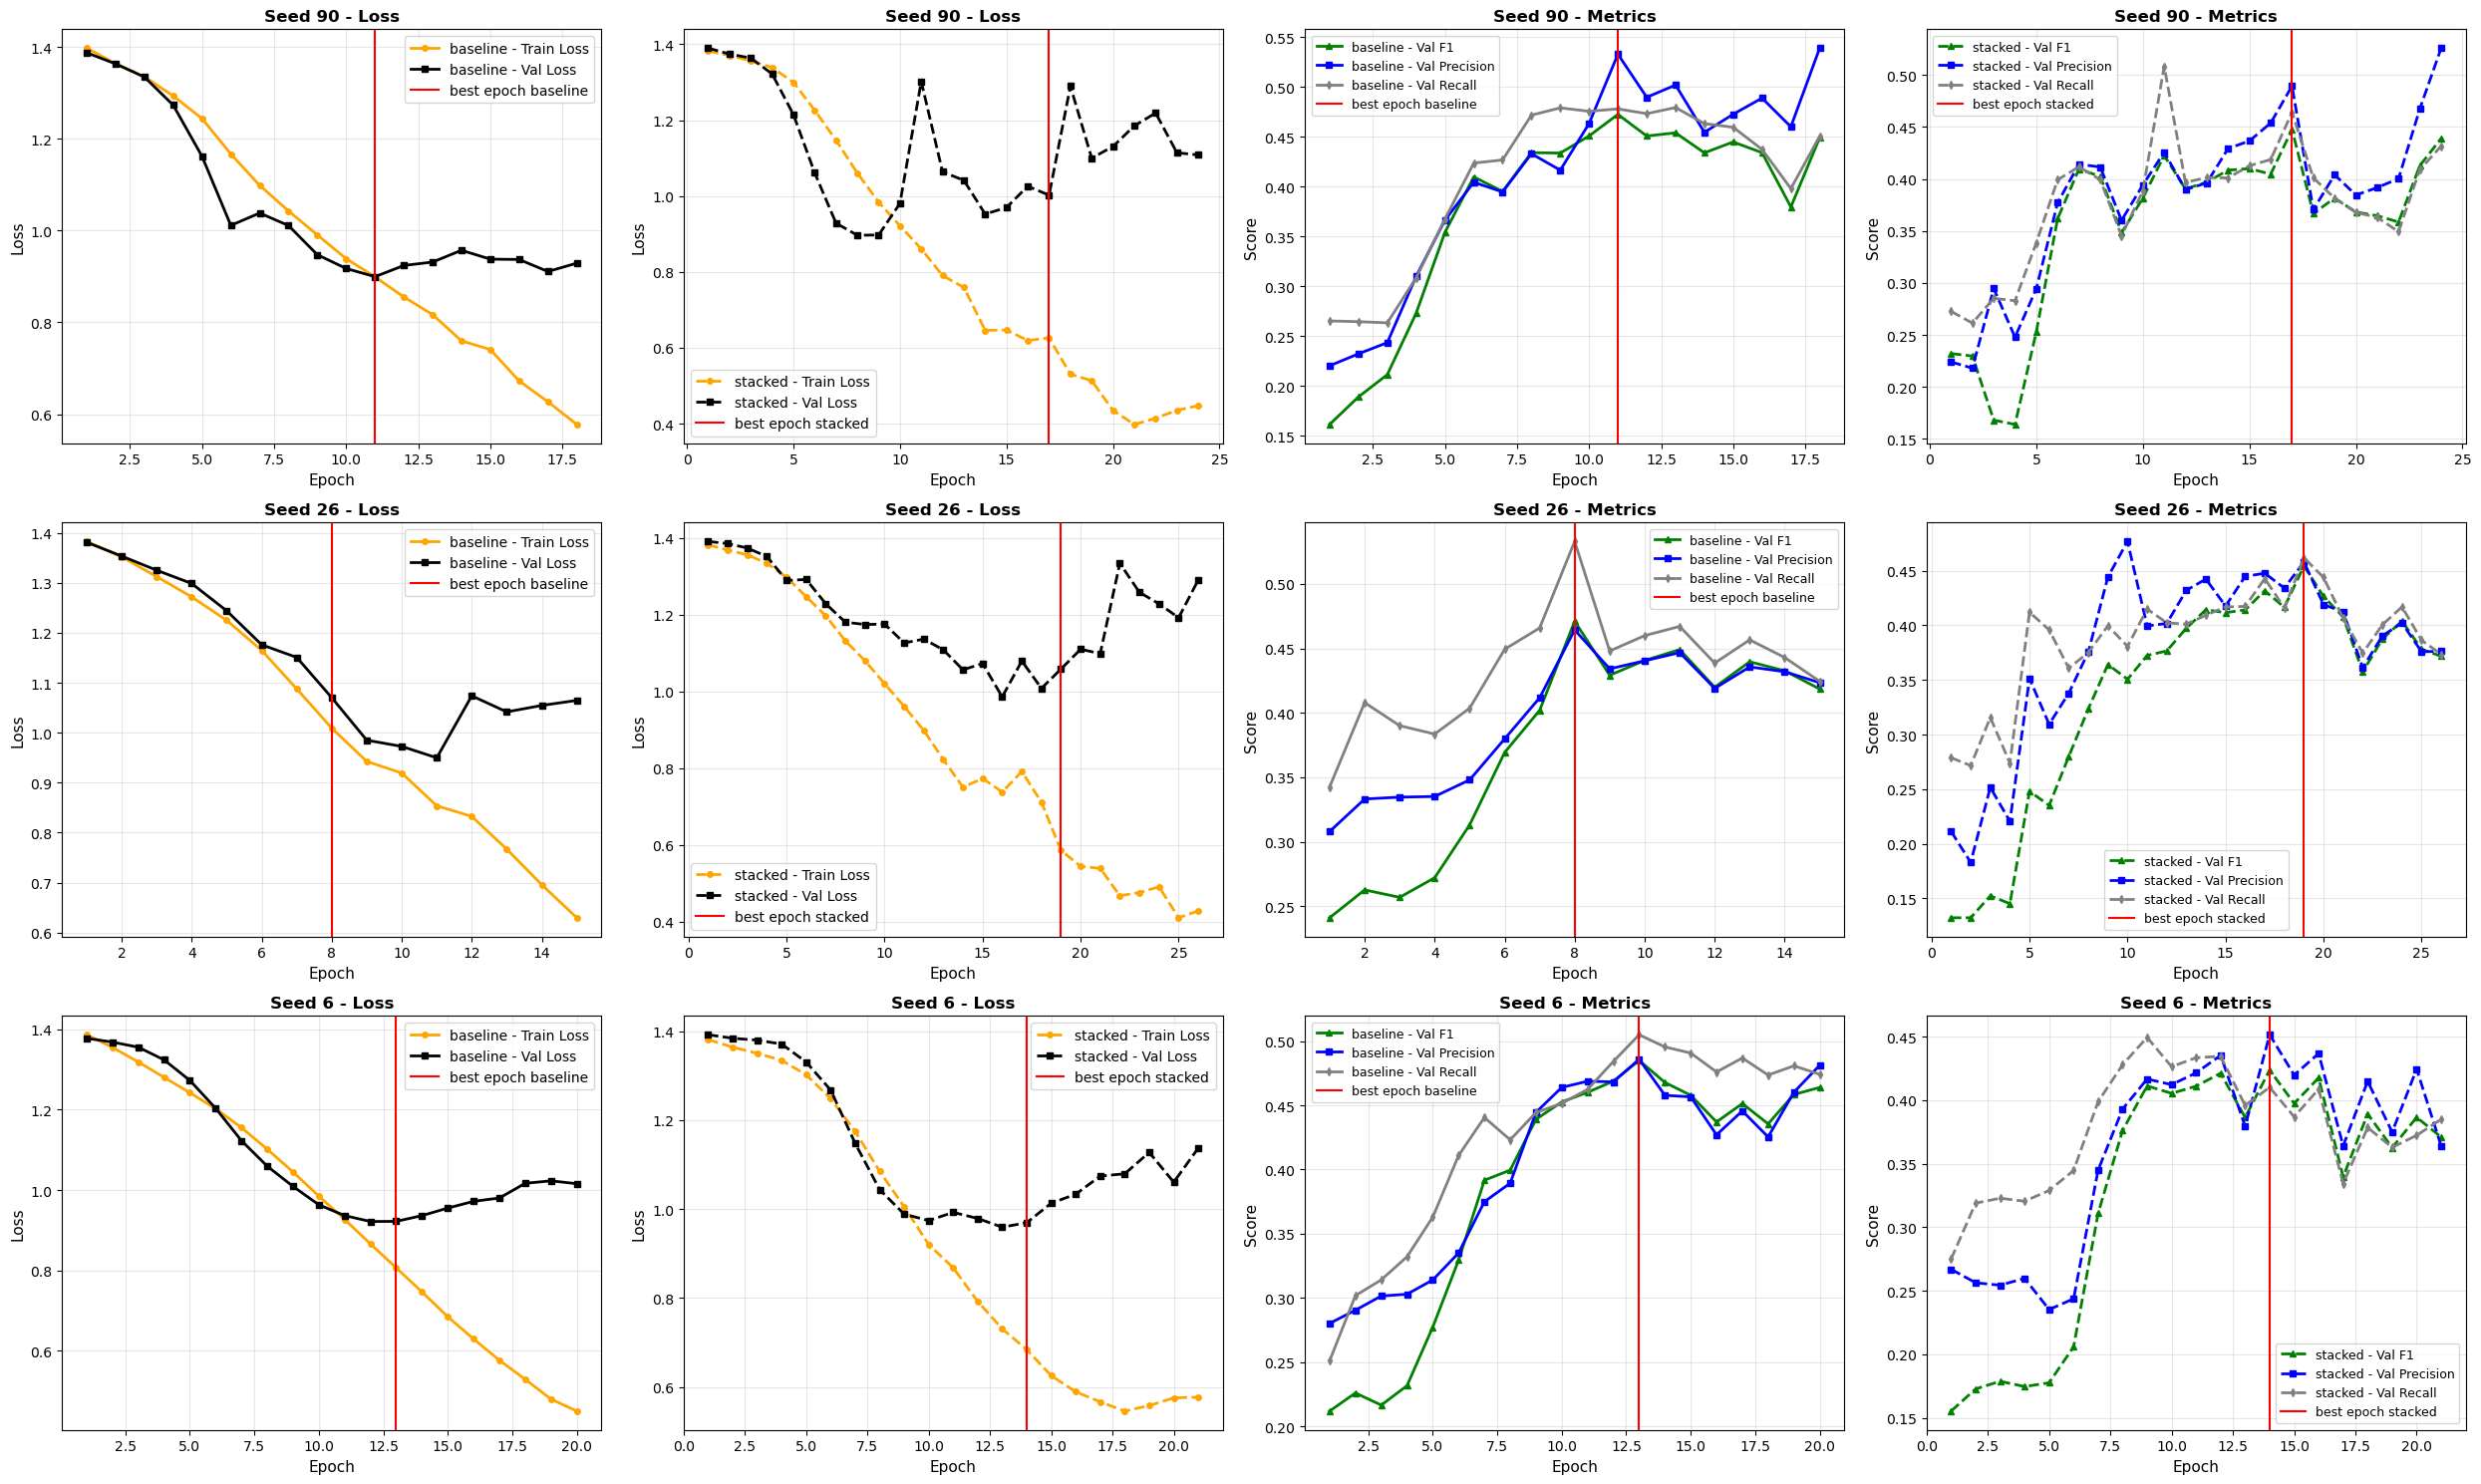

In [ ]:
plot_training_history(histories_200)

Look at the evaluation.

logs dumped


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.472406,0.532815,0.477924,0.66,0.460438,0.499103,0.467000,0.660714,90
1,0.471081,0.464372,0.532971,0.58,0.394755,0.398372,0.443463,0.525000,26
2,0.484995,0.485831,0.504995,0.68,0.403316,0.425294,0.417506,0.625000,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.476161,0.419503,0.494339,0.440923,0.505297,0.442656,0.640000,0.603571
std,0.007680,0.035708,0.035006,0.052152,0.027525,0.024757,0.052915,0.070349


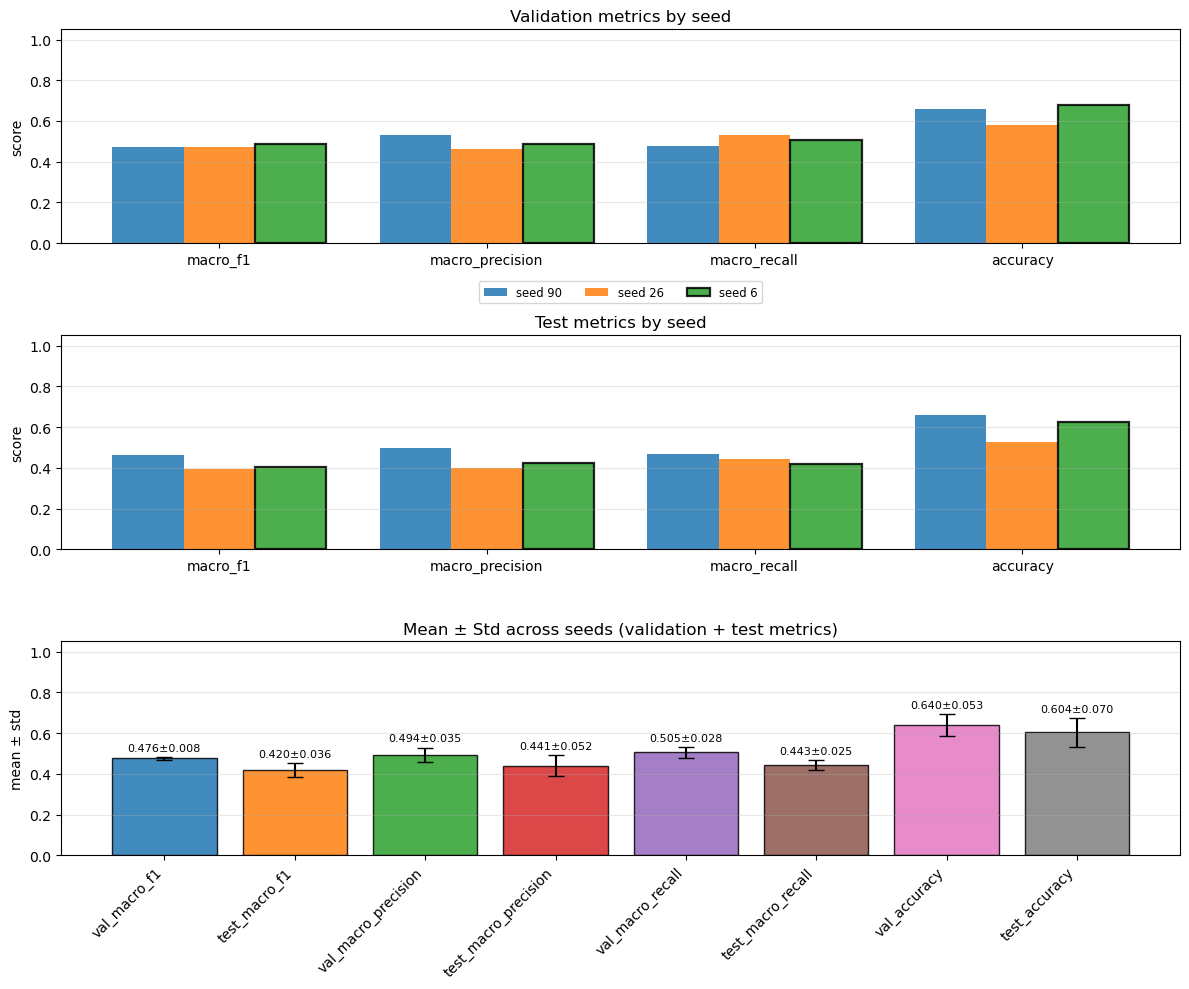

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.447624,0.489335,0.464079,0.673333,0.391846,0.402018,0.404187,0.589286,90
1,0.454364,0.458023,0.461827,0.646667,0.398313,0.392981,0.415440,0.592857,26
2,0.423778,0.451596,0.410171,0.700000,0.327542,0.343304,0.329157,0.646429,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.441922,0.372567,0.466318,0.379434,0.445359,0.382928,0.673333,0.609524
std,0.016071,0.039126,0.020191,0.031614,0.030495,0.046905,0.026667,0.032010


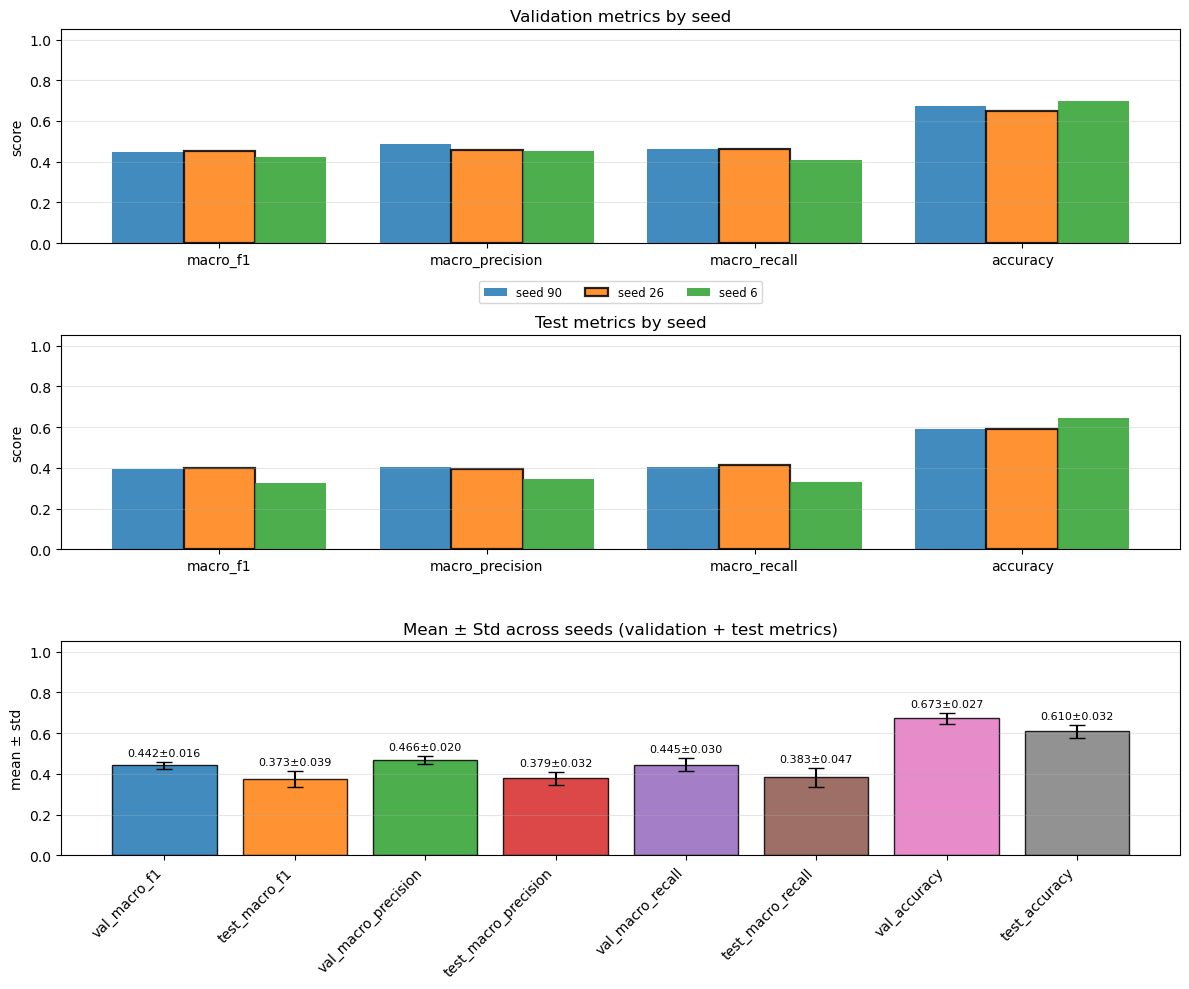

In [ ]:
load=load_LSTM

# load the logs for both the models trained previously
logs_base_200,logs_stacked_200=evaluation(models, X_val_padded, y_val_cat, X_test_padded,
                                        y_test_cat, tok=tokenizer_200,
                                        dir='./weights/emb_200', load=load)

# show the aggregated results for the baseline model
agg_base_200, best_run_base_200=mean_std(logs_base_200)
display(logs_base_200)
display(agg_base_200)
plot_summary_metrics(logs_base_200, agg_base_200, best_run_base_200)

# show the aggregated results for the stacked model
agg_stacked_200, best_run_stacked_200=mean_std(logs_stacked_200)
display(logs_stacked_200)
display(agg_stacked_200)
plot_summary_metrics(logs_stacked_200, agg_stacked_200, best_run_stacked_200)

It seems it is a bit higher so it could be useful trying also with higher embedding dimensions in the future. It is however necessary to say that for a small change in the f1 macro score, we have had for times the number of parameters while before we had nearly 40 times the number of parameters, so even though the performances are slightly better it is necessary to say that it is better to have a lighter model. <br/>
A last check which could be done on the embedding is checking that if the embedding is totally random the model performs better as the model learns alone the similarities in the vocabulary.

In [ ]:
EMBEDDING_DIMENSION=50

load=load_LSTM

embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

tokenizer_rand = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=False,
    oov_token=OOV_TOKEN,
    verbose=True,
    path='./weights/rand_emb',
    load=load
)

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

tokenizer dumped
Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



In [ ]:
load_weights=load_LSTM

# Run this
if not load_weights: # Only clear memory if we are actually going to train
    clear_all_memory()

# fit the model
histories_rand, results_rand, f1_voc_rand = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, tok=tokenizer_rand, class_weight_dict=class_weight_dict, dir='./weights/rand_emb',
                                                    load_weights=load_weights, tot=True)


history loaded

SUMMARY ON VALIDATION SET ACROSS SEEDS

baseline:
  F1 scores: ['0.3238', '0.2078', '0.2963']
  Mean F1: 0.2760 ± 0.0606

stacked:
  F1 scores: ['0.3434', '0.1732', '0.2195']
  Mean F1: 0.2453 ± 0.0880



Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 26
  Model: baseline
  Model: stacked

Plotting seed: 6
  Model: baseline
  Model: stacked


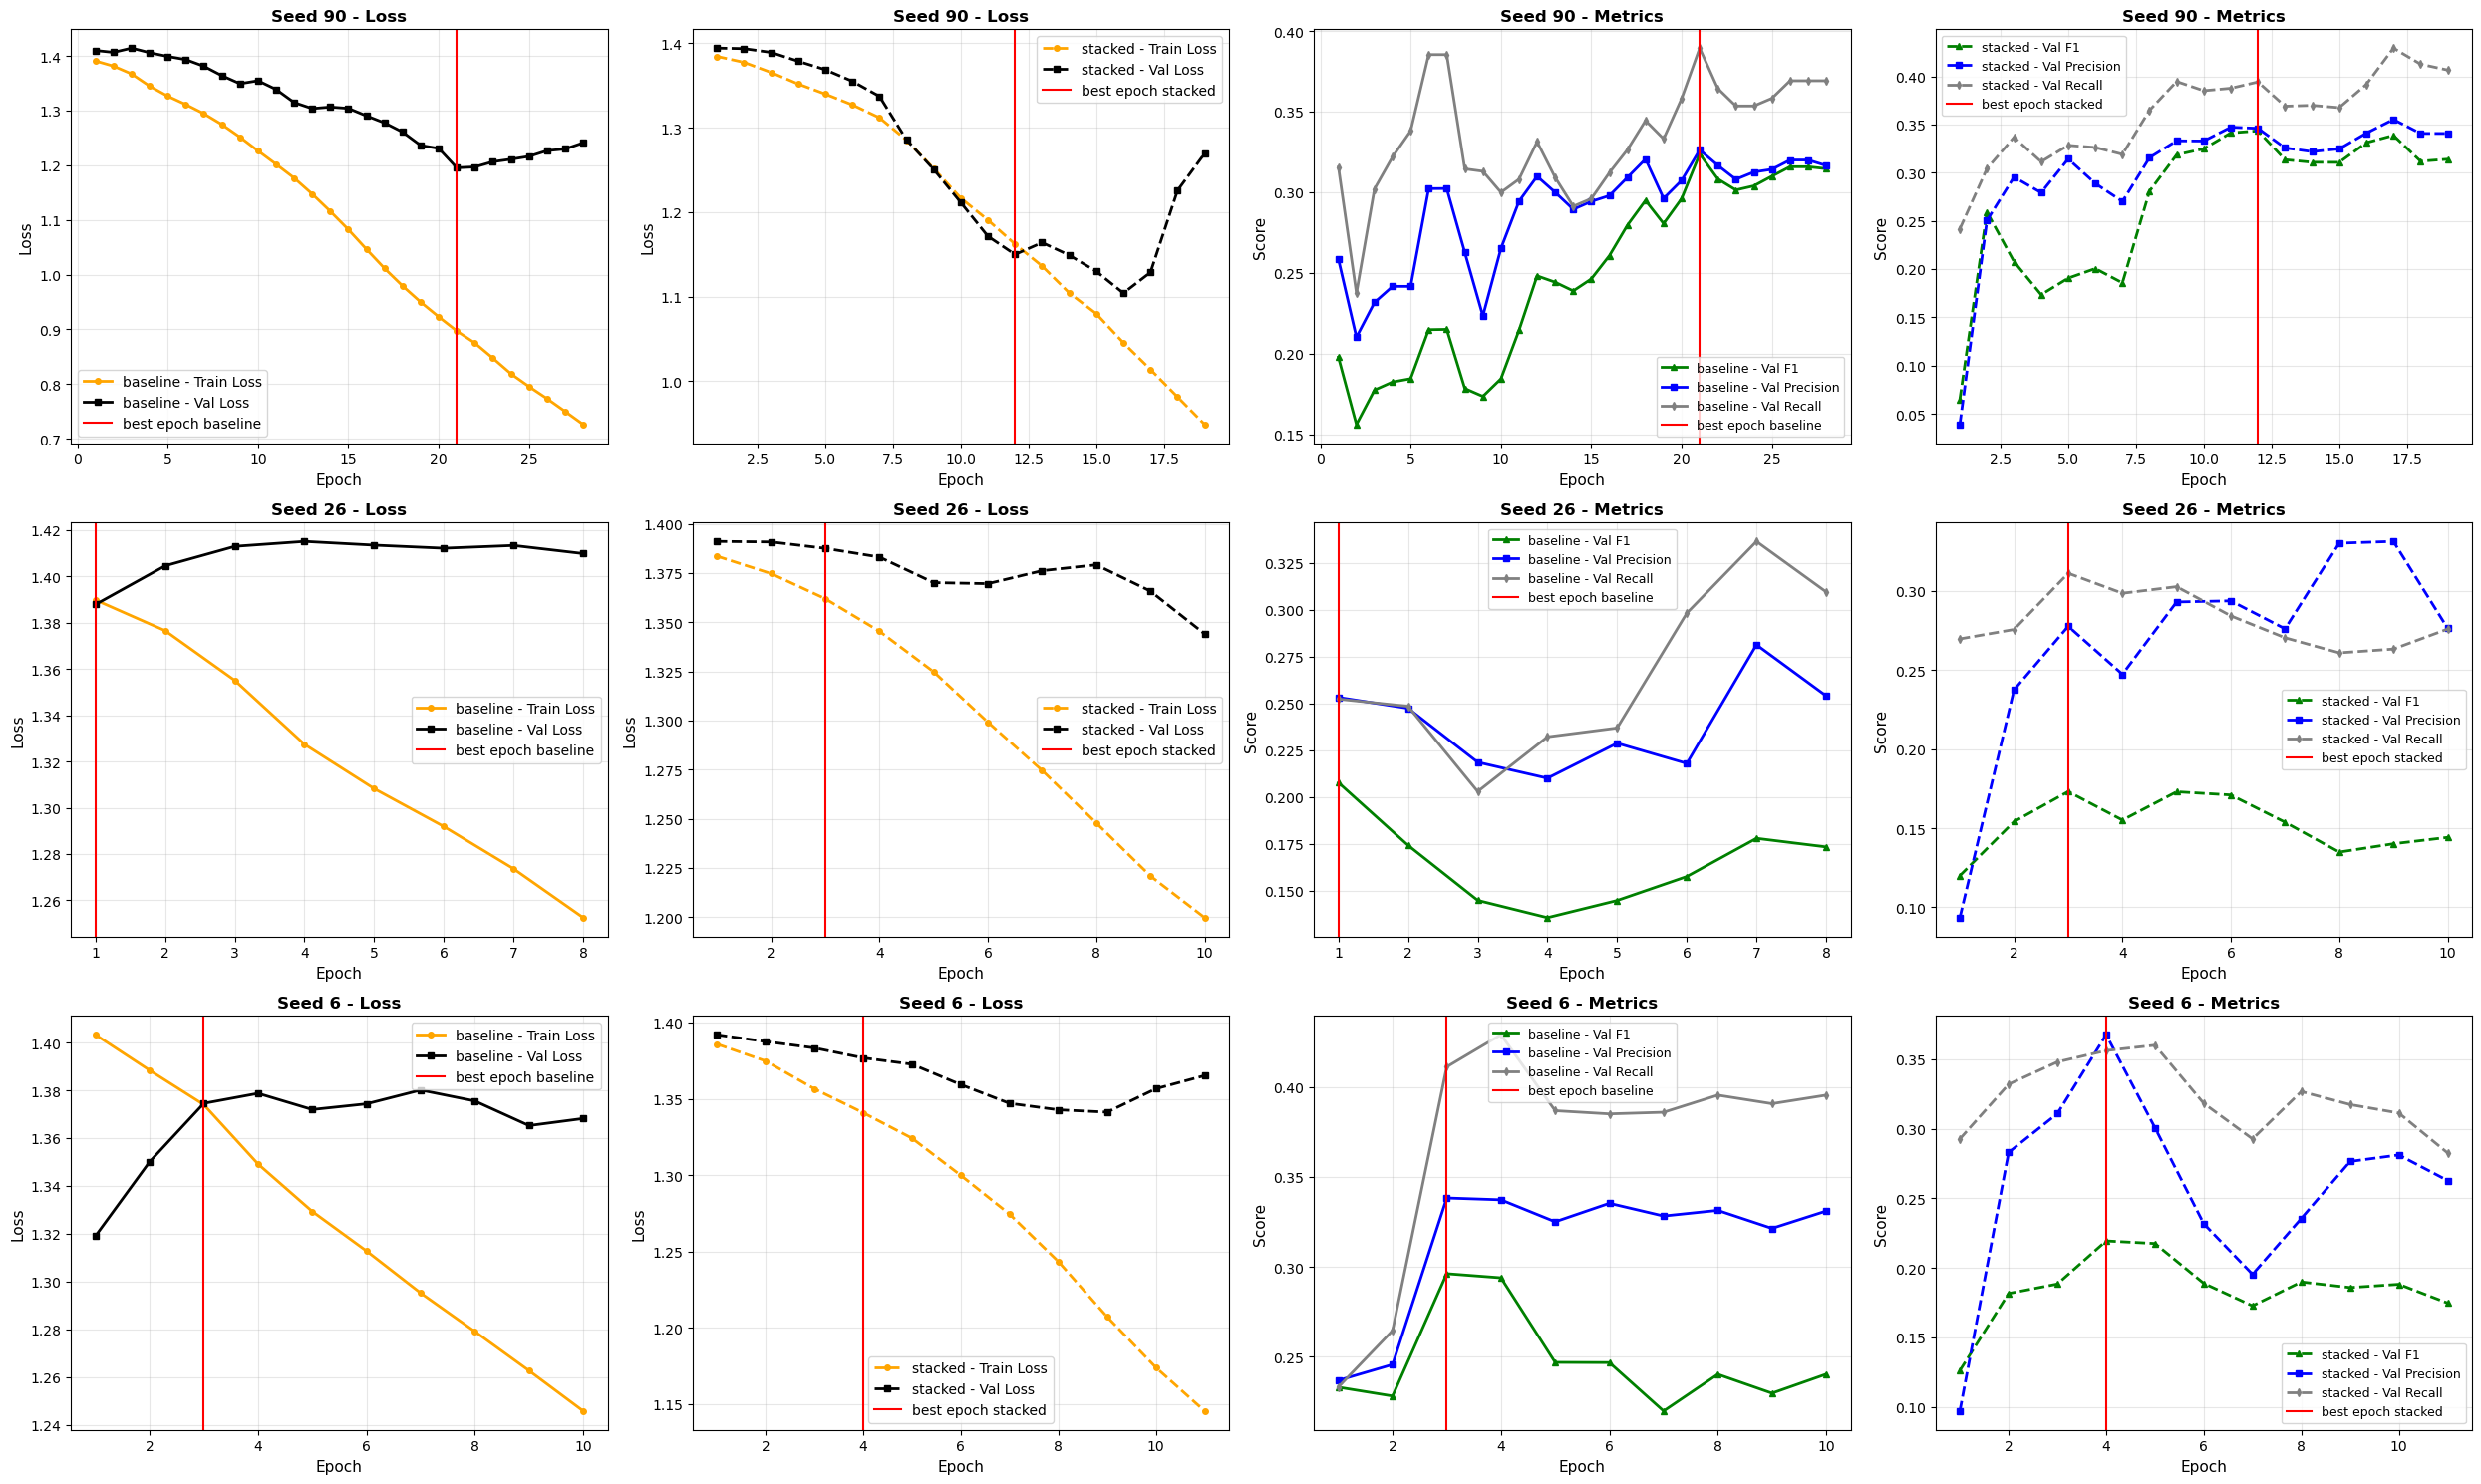

In [ ]:
plot_training_history(histories_rand)

See the evaluation.

logs loaded


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.323810,0.326288,0.389389,0.520000,0.318794,0.329444,0.336413,0.500000,90
1,0.207796,0.253299,0.252433,0.246667,0.230640,0.271588,0.258681,0.300000,26
2,0.296266,0.338306,0.411206,0.346667,0.229399,0.283781,0.312936,0.257143,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.275957,0.259611,0.305964,0.294938,0.351009,0.302677,0.371111,0.352381
std,0.060614,0.051258,0.046003,0.030499,0.086064,0.039869,0.138297,0.129625


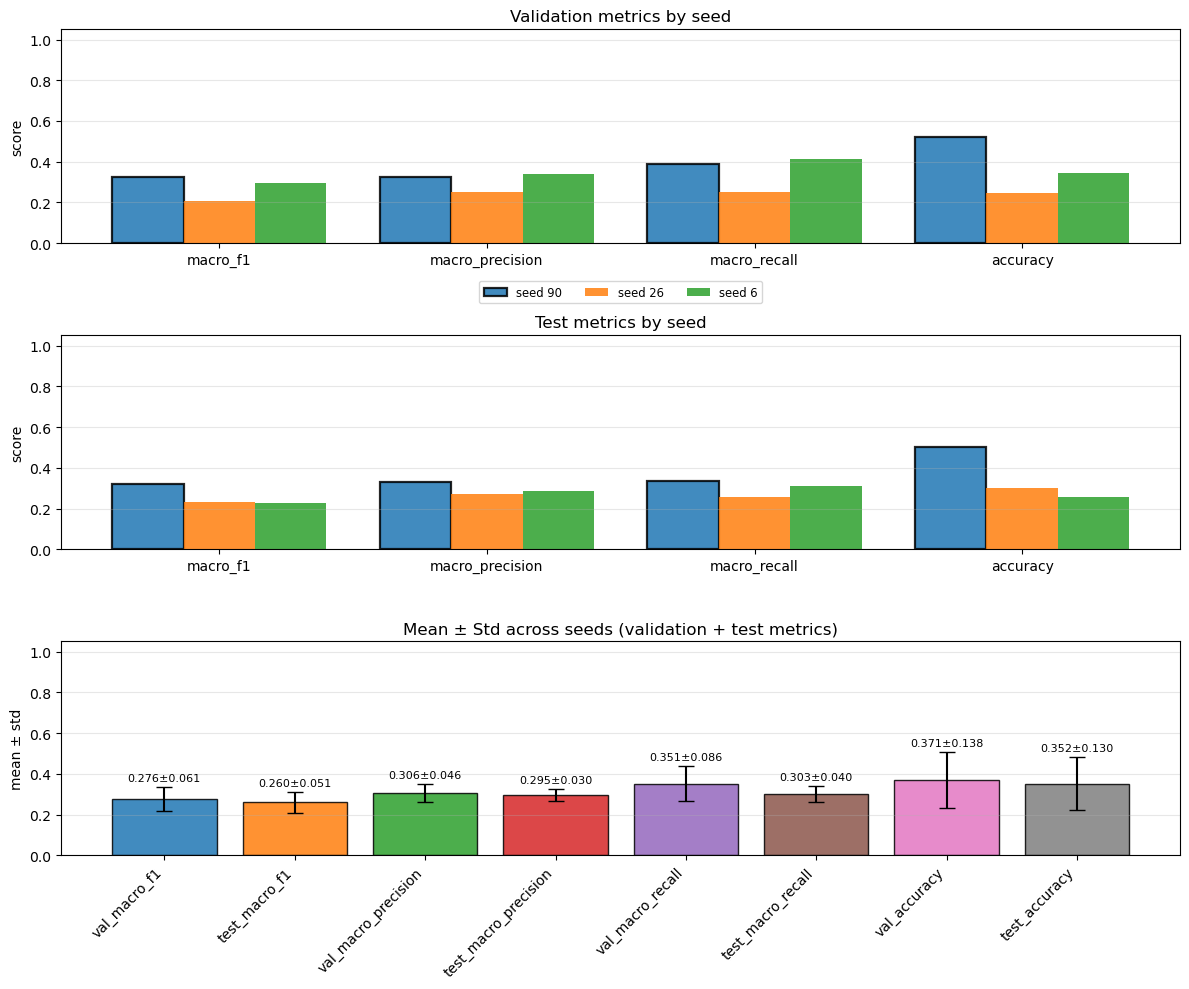

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.343355,0.345966,0.394125,0.473333,0.318513,0.322158,0.343365,0.460714,90
1,0.173191,0.277733,0.311258,0.193333,0.189411,0.279546,0.301020,0.246429,26
2,0.219474,0.367763,0.356341,0.240000,0.206460,0.278004,0.340303,0.271429,6


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.245340,0.238128,0.330487,0.293236,0.353908,0.328229,0.302222,0.32619
std,0.087982,0.070136,0.046969,0.025059,0.041487,0.023613,0.150012,0.11717


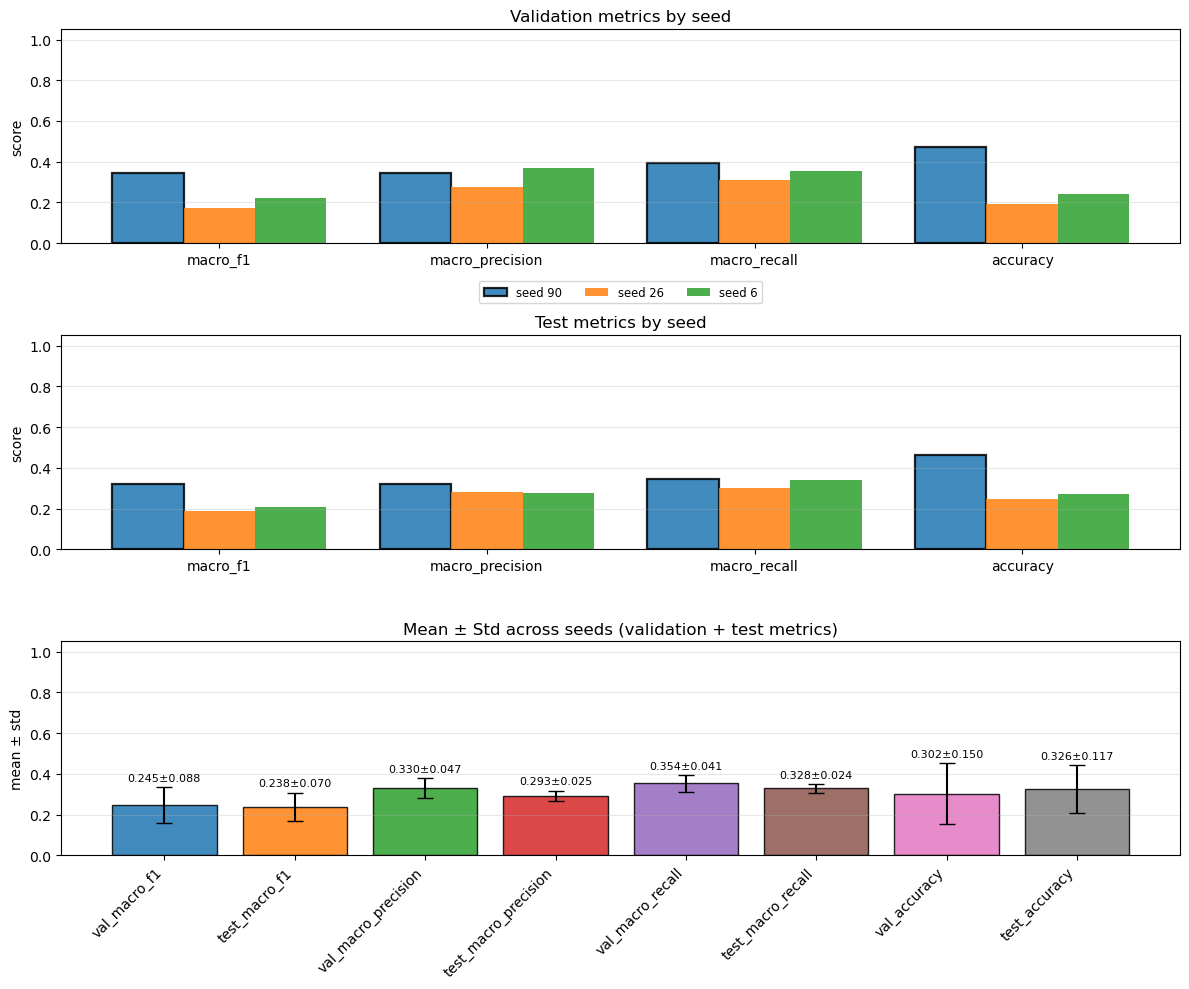

In [ ]:
load=load_LSTM

# load the logs for both the models trained previously
logs_base_rand,logs_stacked_rand=evaluation(models, X_val_padded, y_val_cat, X_test_padded,
                                        y_test_cat,tok=tokenizer_rand, dir='./weights/rand_emb', load=load)

# show the aggregated results for the baseline model
agg_base_rand, best_run_base_rand=mean_std(logs_base_rand)
display(logs_base_rand)
display(agg_base_rand)
plot_summary_metrics(logs_base_rand, agg_base_rand, best_run_base_rand)

# show the aggregated results for the stacked model
agg_stacked_rand, best_run_stacked_rand=mean_std(logs_stacked_rand)
display(logs_stacked_rand)
display(agg_stacked_rand)
plot_summary_metrics(logs_stacked_rand, agg_stacked_rand, best_run_stacked_rand)

Let's now check the confusion matrix.

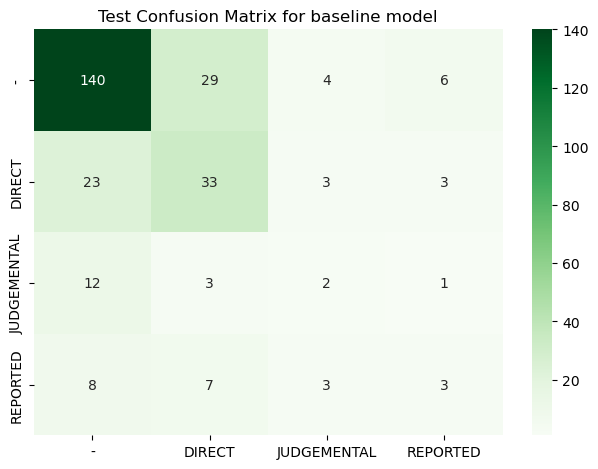

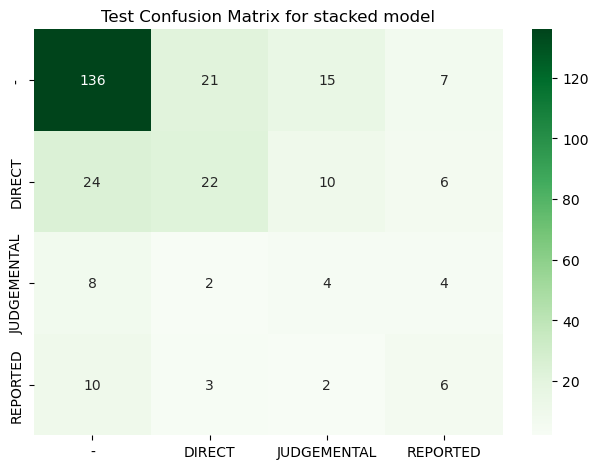

In [ ]:
# plot the matrices
plot_conf_matrix(models,'baseline', best_run_base,tok=tokenizer, dir='./weights/base')
plot_conf_matrix(models, 'stacked', best_run_stacked, tok=tokenizer,dir='./weights/base')

We would expect that the models tend to correctly predict sexism vs no-sexism and might confuse easily between different types of sexism. However, it seems that the model tends to predict as sexist even tweets which are not this could be due to the weight dictionary, in the future it would be interesting to try different weights for the classes.

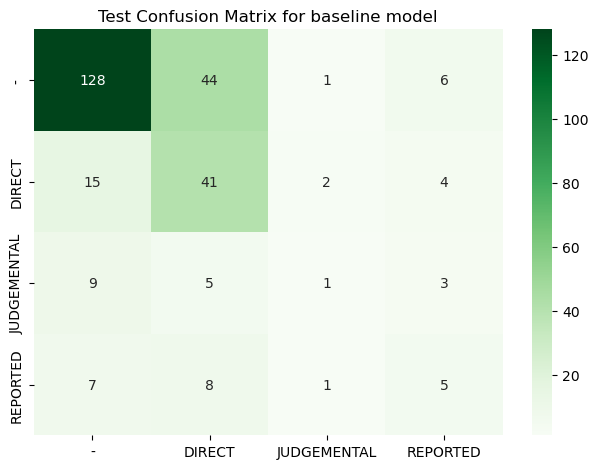

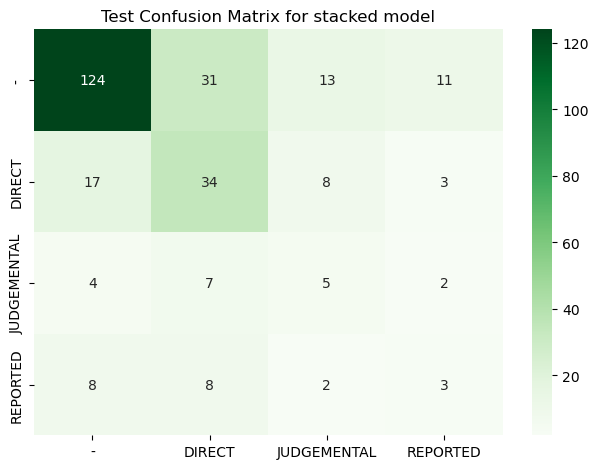

In [ ]:
# plot the matrices
EMBEDDING_DIMENSION=200

embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

plot_conf_matrix(models,'baseline', best_run_base_200, tok=tokenizer_200, dir='./weights/emb_200')
plot_conf_matrix(models, 'stacked', best_run_stacked_200, tok=tokenizer_200,dir='./weights/emb_200')

Here, it is possible to see that enlarging the embedding dimension leads to better prediction of `direct` class. It would be interesting in the future to see whether enlarging more the embedding dimension would lead to a better prediction of the other classes, even though they have to few examples.

## roBerta


### Fully fine-tuned model vs partially fine-tuned

When we compare fully fine-tuned models against partially fine-tuned models, we see something counterintuitive at first glance. The partially fine-tuned models actually achieve slightly higher validation F1 on average (0.518 versus 0.510), yet they perform notably worse on the test set (0.479 versus 0.502).
The fully fine-tuned models are learning richer representations throughout the entire network, while the partially fine-tuned models are essentially trying to solve a harder problem relying only on frozen pretrained representations that weren't optimized for distinguishing between threats, derogation, animosity, and prejudiced discussion.


##### Accuracy 
Fully fine-tuned models achieve mean validation accuracy of 0.807 and test accuracy of 0.764, a gap about points.  
Partially fine-tuned models show validation accuracy of 0.807 but test accuracy of only 0.750, a gap of 6% percentage points.  
Both approaches perform similarly on the validation set's majority class predictions, but the fully fine-tuned models maintain this performance better on unseen data.  
This pattern, combined with the F1 scores and the fact that the accuracy doen't change during the epochesm even if the val loss increase, suggests that partial accuracy is not attendible and might be getting inflated by performing well on easier majority-class examples while struggling more with the nuanced minority classes. 

In [ ]:
print("Mean and Std for Full Fine-Tuning:");display(agg.filter(regex='f1|accuracy'));print("Mean and Std for Partial Fine-Tuning:");display(agg_partial.filter(regex='f1|accuracy'))

Mean and Std for Full Fine-Tuning:


,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
mean,0.510051,0.806667,0.501682,0.764286
std,0.030176,0.013333,0.022499,0.016366


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
mean,0.518234,0.806667,0.478701,0.750000
std,0.031972,0.006667,0.015846,0.009449


========================================================    Best model full fine-tuned     ========================================================


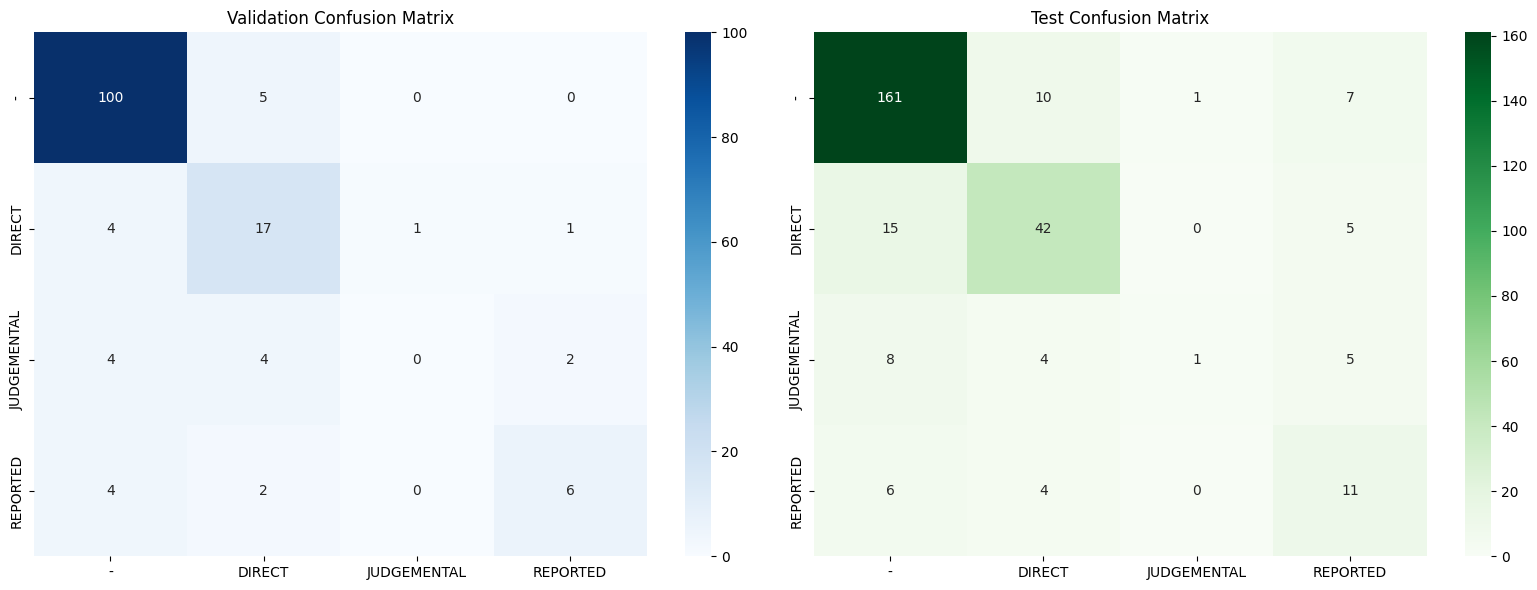

========================================================   Best model partial fine-tuned   ========================================================


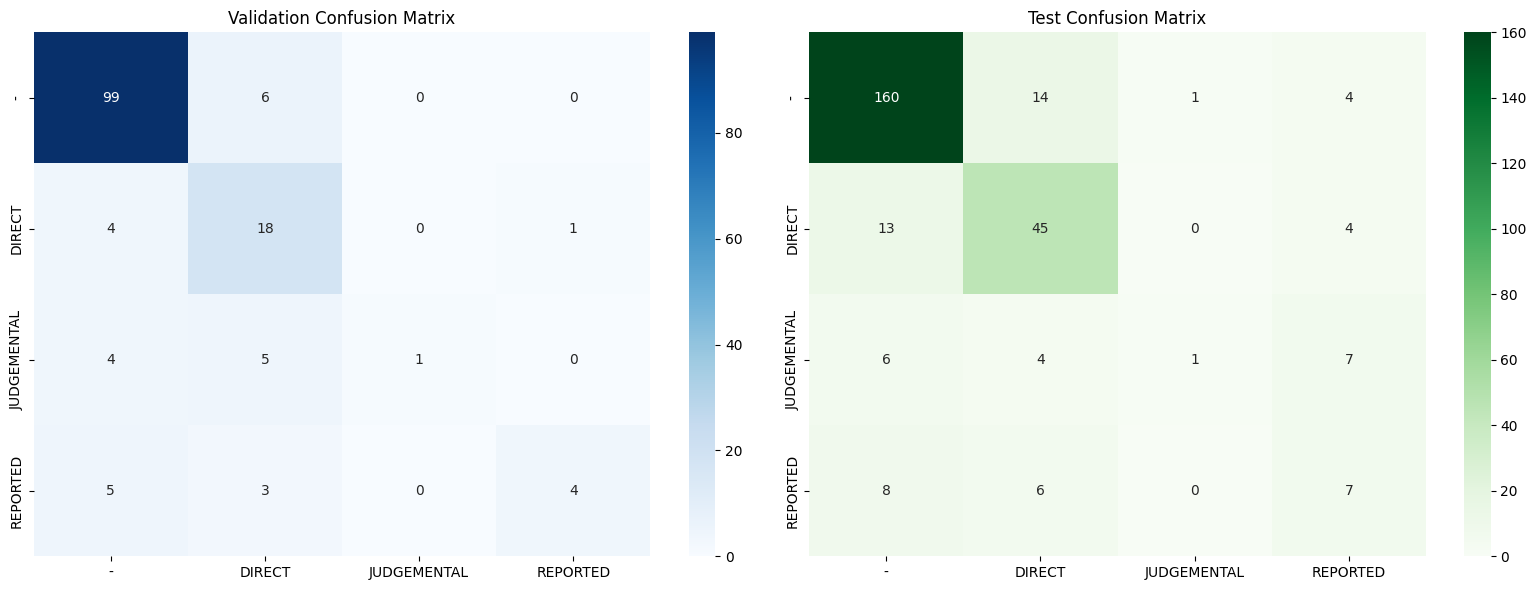

In [ ]:
print("========================================================    Best model full fine-tuned     ========================================================")
plot_confusion_matrices(best_model_dirs, best_seed, label_mapping.keys(), dataset[1:])
print("========================================================   Best model partial fine-tuned   ========================================================")
plot_confusion_matrices(best_model_dirs_partial, best_seed_partial, label_mapping.keys(), dataset[1:])

By visualizing the confusion matrix, we can immediately observe the degree of class imbalance in both the test and validation sets.  
Additionally, it becomes evident, and also as we expect, that the fully fine-tuned model classifies the minority classes more effectively than the partially fine-tuned model (class reported - test set).  
However, despite this improvement, both models still struggle to correctly classify the minority classes, particularly the most underrepresented ones.

### Best model with cleaned data

The last experiment is about trying the best model but trained with cleaned tweets.

In [ ]:
def preprocess_text_precleaned(tweets):
    return tokenizer(tweets['cleaned_only_tweet'], truncation=True, padding=True , return_tensors="pt")

TRAIN_DATA = Dataset.from_pandas(train_df[["cleaned_only_tweet","label"]])
TEST_DATA = Dataset.from_pandas(test_df[["cleaned_only_tweet","label"]])
VAL_DATA = Dataset.from_pandas(val_df[["cleaned_only_tweet","label"]])
TRAIN_DATA = TRAIN_DATA.map(preprocess_text_precleaned, batched=True)
TEST_DATA = TEST_DATA.map(preprocess_text_precleaned, batched=True)
VAL_DATA = VAL_DATA.map(preprocess_text_precleaned, batched=True)

datasets_clean = [TRAIN_DATA, TEST_DATA, VAL_DATA]

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
results_cleaned, logs_cleaned, best_model_dirs_cleaned = train_evaluate_model(
    seeds=seeds, 
    hyperparameters=hyper,
    dataset=datasets_clean, 
    output_dir=output_dir, 
    fine_tune_partially=False, 
    VERBOSE=False, 
    best_subdir_name="best_model_cleaned")
df_out_cleaned = pd.DataFrame(results_cleaned)
df_out = df_out_cleaned.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)


=== RUN seed=90 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.741900,0.635299,0.381435,0.345765,0.428986,0.773333
2,0.579800,0.603710,0.473280,0.612613,0.503261,0.806667
3,0.497200,0.607821,0.418529,0.424501,0.429555,0.766667
4,0.433400,0.698143,0.446859,0.480029,0.462164,0.786667
5,0.404000,0.678373,0.421059,0.416175,0.431936,0.773333
6,0.360700,0.680047,0.440328,0.476293,0.451294,0.780000
7,0.336000,0.696627,0.469354,0.505322,0.474508,0.793333



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.738800,0.664575,0.356840,0.350643,0.370911,0.753333
2,0.582200,0.619861,0.460208,0.498635,0.461258,0.780000
3,0.497400,0.666656,0.464511,0.504315,0.463639,0.786667
4,0.440500,0.684534,0.471670,0.504202,0.482997,0.793333
5,0.391500,0.696873,0.462923,0.498246,0.469746,0.780000
6,0.354600,0.718898,0.480271,0.542614,0.491486,0.793333
7,0.342600,0.738874,0.467551,0.499627,0.480616,0.786667



=== RUN seed=6 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.758600,0.640701,0.388793,0.350932,0.442236,0.786667
2,0.596000,0.635343,0.408631,0.468079,0.430461,0.773333
3,0.519800,0.638635,0.462179,0.478148,0.472127,0.786667
4,0.441900,0.675772,0.474756,0.505114,0.491486,0.793333
5,0.408300,0.677035,0.478936,0.509652,0.493866,0.800000
6,0.359200,0.713671,0.442230,0.449248,0.450388,0.773333
7,0.341200,0.740369,0.454374,0.472291,0.461258,0.780000


---   Results for Cleaned Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 26
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
1,26,0.480271,0.542614,0.491486,0.793333,6.0
2,6,0.478936,0.509652,0.493866,0.800000,5.0
0,90,0.473280,0.612613,0.503261,0.806667,2.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
1,26,0.531826,0.712843,0.533202,0.767857,6.0
2,6,0.517472,0.701448,0.514664,0.760714,5.0
0,90,0.372052,0.341599,0.415615,0.739286,2.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.477496,0.554959,0.496204,0.800000,0.473783,0.585297,0.487827,0.755952
std,0.003711,0.052579,0.006226,0.006667,0.088394,0.211125,0.063221,0.014869


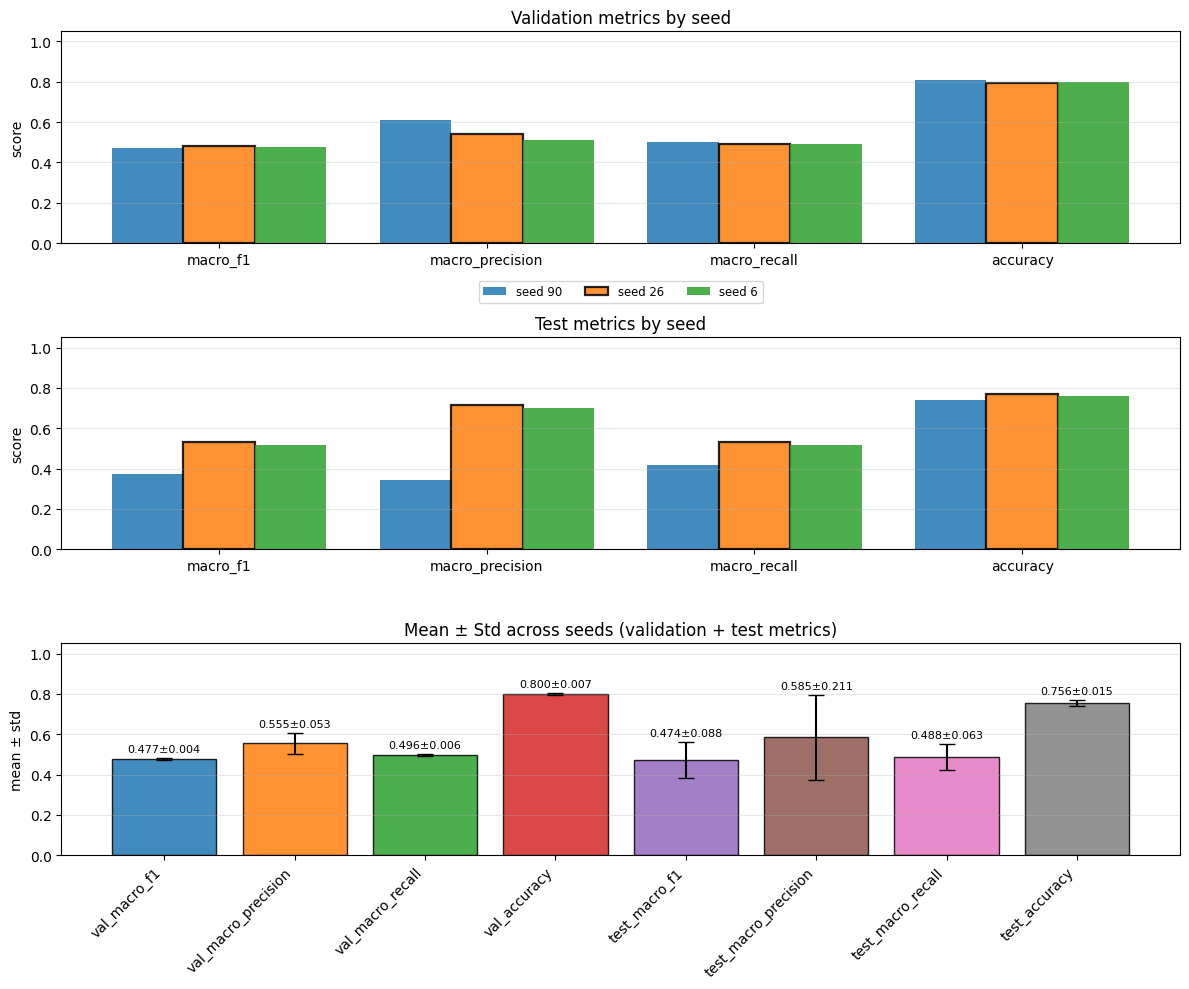

In [ ]:
agg_cleaned, best_run_cleaned, best_seed_cleaned = print_outputs_and_hystograms(df_out_cleaned, name_model="Cleaned")

We can notice, as expexted, that the roberta tokenizer does a better job for the model respect to our clening process.  
But we also can notice that:

In [ ]:
print("Mean and Std for Full:");display(agg.filter(regex='test'));print("Mean and Std for Cleaned :");display(agg_cleaned.filter(regex='test'))

Mean and Std for Full:


,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.501682,0.547599,0.510745,0.764286
std,0.022499,0.057308,0.024652,0.016366


Mean and Std for Cleaned :


,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.473783,0.585297,0.487827,0.755952
std,0.088394,0.211125,0.063221,0.014869


============================   Best model cleaned fine-tuned   ============================


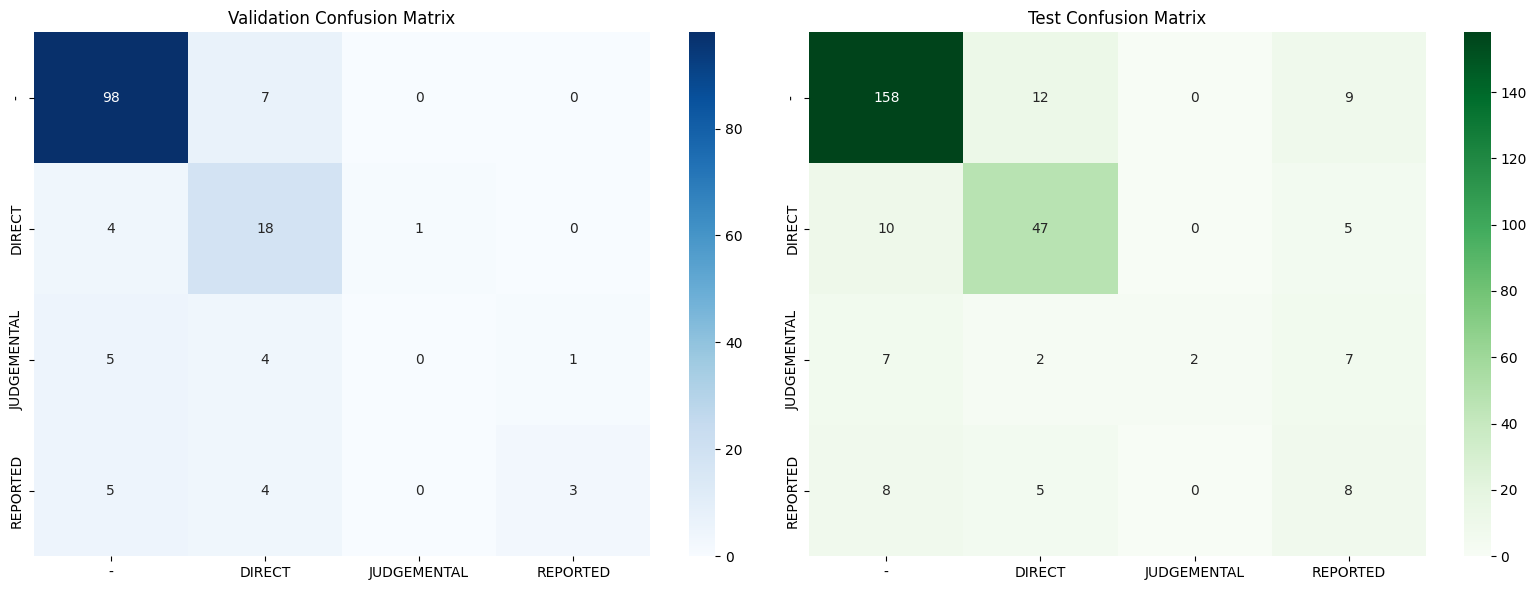

In [ ]:
print("============================   Best model cleaned fine-tuned   ============================")
plot_confusion_matrices(best_model_dirs_cleaned, best_seed_cleaned, label_mapping.keys(), datasets_clean[1:])

By comparing the test set results and the confusion matrices, we observe that the model trained on manually cleaned data achieves higher precision compared to the model that relies solely on RoBERTa’s tokenizer. 
This could suggests that explicit text cleaning can still provide measurable benefits, even when using a strong subword tokenizer such as RoBERTa’s. In particular, manual preprocessing appears to reduce noise and improve class-specific precision, which is especially valuable in imbalanced classification settings.  
However, this improvement is not so meaningfull and comes at the cost of additional preprocessing complexity.

In the end, not only because of the better performances but also for reasons which are described in the report, the transformer derived form RoBERTa should be preferred.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!